# Drug Approval Analysis

This notebook analyzes drug approval data across multiple regulatory agencies.

## Setup

Before running burden-related analyses, preprocess the burden data:

```bash
python src/burden_mapping/preprocess_burden_data.py
```

This will generate preprocessed burden data files in `data/Disease_burden_mapping/preprocessed/`

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.colors as mcolors
import seaborn as sns
import json
import numpy as np
from matplotlib.ticker import FixedLocator, ScalarFormatter
import math
import os

# Import burden mapping utilities
from burden_mapping.burden_utils import load_burden_data, extract_canonical_classes

In [47]:
DECISION_FILTER = "all_decisions" # "approved" or "all_decisions"
DATASET_FILTER = "_pars" # "" or "_pars"

In [48]:


DATASET_DIR = f"./../data/datasets/1995{DATASET_FILTER}/{DECISION_FILTER}"

EMA = f"{DATASET_DIR}/EMA.csv"
PMDA = f"{DATASET_DIR}/PMDA.csv"
SWISSMEDIC = f"{DATASET_DIR}/Swissmedic.csv"
AUSTRALIA = f"{DATASET_DIR}/TGA.csv"
# FDA = f"{DATASET_DIR}/FDA.csv"
# HEALTHCANADA = f"{DATASET_DIR}/HealthCanada.csv"
OVERALL = f"{DATASET_DIR}/Overall.csv"

SAVE_DIR = f"./../analysis/1995{DATASET_FILTER}/{DECISION_FILTER}"
os.makedirs(SAVE_DIR, exist_ok=True)

In [49]:
# Load datasets directly from CSV files
print("Loading datasets...")
EMA = pd.read_csv(EMA)
PMDA = pd.read_csv(PMDA)
Swissmedic = pd.read_csv(SWISSMEDIC)
TGA = pd.read_csv(AUSTRALIA)
# FDA = pd.read_csv(FDA)
# HealthCanada = pd.read_csv(HEALTHCANADA)
Overall = pd.read_csv(OVERALL)

# Combine into dictionaries for easy iteration
DATASETS = {
    'EMA': EMA,
    'PMDA': PMDA,
    'Swissmedic': Swissmedic,
    'TGA': TGA,
    # 'FDA': FDA,
    # 'HealthCanada': HealthCanada,
    'Overall': Overall
}

print("Datasets loaded successfully!")
for name, df in DATASETS.items():
    print(f"{name}: {len(df)} rows")

Loading datasets...
Datasets loaded successfully!
EMA: 1687 rows
PMDA: 408 rows
Swissmedic: 234 rows
TGA: 1042 rows
Overall: 3371 rows


In [50]:
# Helper functions for plotting
def generate_distinct_colors(n, cmap_name='tab20'):
    cmap = cm.get_cmap(cmap_name, n)
    return [mcolors.rgb2hex(cmap(i)) for i in range(n)]

def date_to_int(df, col_name):
    df = df.copy()
    original_len = len(df)

    numeric_years = pd.to_numeric(df[col_name], errors='coerce')
    numeric_years = numeric_years.where(numeric_years.between(1800, 2100))
    dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year
    df[col_name] = numeric_years.fillna(dt_years).astype('Int64')
    df = df.dropna(subset=[col_name])
    df[col_name] = df[col_name].astype(int)

    final_len = len(df)
    print(f"Original length: {original_len}, Final length after cleaning: {final_len}, "
        f"Percentage kept: {final_len/original_len*100:.2f}%")
    return df

def plot_timeline(df, col_name, dataset_name=None):
    original_count = len(df)
    df = date_to_int(df, col_name)  # Ensure column is integer (e.g., year)
    
    if len(df) == 0:
        print(f"{dataset_name}: All {original_count} rows dropped after date_to_int for {col_name} (all values invalid/null), skipping plot.")
        return
    
    unique_vals = sorted(df[col_name].unique())
    
    # Check if there's any data after filtering
    if len(unique_vals) == 0:
        print(f"{dataset_name}: No unique values for {col_name}, skipping plot.")
        return
    
    bins = np.append(unique_vals, unique_vals[-1] + 1)
    plt.figure(figsize=(8, 4))
    ax = plt.gca()
    counts, edges, patches = plt.hist(df[col_name], bins=bins, color="seagreen", edgecolor='black', align='left', alpha=0.7)
    ax.set_xticks(unique_vals)
    ax.set_xticklabels([str(int(x)) for x in unique_vals], rotation=45, ha='center')
    plt.xlabel(col_name)
    plt.ylabel('Frequency')
    plt.title(dataset_name)
    plt.grid(axis='y', linestyle='--', alpha=0.7, color='silver')
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/timeline_{col_name}_{dataset_name}.png", dpi=300, bbox_inches='tight')
    plt.close()

def plot_drug_class_per_decision_year_absolute(df, year_col='Decision_year', drug_class_colormap=None, dataset_name=None):
    # Vorverarbeitung
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=['Drug_class', year_col])
    df = df[~df['Drug_class'].astype(str).str.contains('error: pycryptodome', case=False, na=False)]

    # Decision_year -> Year (int) mit deiner date_to_int-Funktion
    df = date_to_int(df, year_col)
    df.rename(columns={year_col: 'Year'}, inplace=True)

    # Gruppierung (Jahre sortieren)
    count_df = (
        df.groupby(['Year', 'Drug_class'])
          .size()
          .unstack(fill_value=0)
          .sort_index()
    )

    # Farbzuordnung
    if drug_class_colormap is None:
        colors = generate_distinct_colors(len(count_df.columns), cmap_name='nipy_spectral')
    else:
        colors = [drug_class_colormap.get(cls, '#333333') for cls in count_df.columns]

    # Plot
    ax = count_df.plot(
        kind='bar',
        width=1.0,
        stacked=True,
        figsize=(8, 5),
        color=colors,
        edgecolor='black'
    )

    ax.set_ylabel(f'$N$ approvals', fontsize=14)
    ax.set_xlabel('Year', fontsize=14)
    ax.set_title(dataset_name, fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=12)
    # ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right')
    
    # Get legend handles and labels
    handles, labels = ax.get_legend_handles_labels()
    
    # Remove legend from main plot
    ax.get_legend().remove()
    
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}/drug_class_per_decision_year_absolute_{dataset_name}.png",
                    dpi=300, bbox_inches='tight')
    
    # Save legend as separate file
    if dataset_name:
        fig_legend = plt.figure(figsize=(3, len(labels) * 0.25))
        fig_legend.legend(handles[::-1], labels[::-1], title='Drug Class', loc='center', fontsize=10, title_fontsize=12)
        fig_legend.savefig(f"{SAVE_DIR}/drug_class_per_decision_year_absolute_{dataset_name}_legend.png", dpi=300, bbox_inches='tight')
        plt.close(fig_legend)

def plot_drug_class_per_year(df, date_col=None, drug_class_colormap=None, dataset_name=None):
    # Vorverarbeitung
    df = df.copy()
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=['Drug_class', date_col])
    df = df[~df['Drug_class'].astype(str).str.contains('error: pycryptodome', case=False, na=False)]

    df = date_to_int(df, date_col)
    df = df.rename(columns={date_col: 'Year'})

    # Gruppieren
    count_df = (
        df.groupby(['Year', 'Drug_class'])
          .size()
          .unstack(fill_value=0)
          .sort_index()
    )

    # Auf 100% normalisieren (Zeilenweise)
    denom = count_df.sum(axis=1).replace(0, np.nan)
    percent_df = (count_df.T / denom).T.fillna(0) * 100

    # Farben
    if drug_class_colormap is None:
        colors = generate_distinct_colors(len(percent_df.columns), cmap_name='nipy_spectral')
    else:
        colors = [drug_class_colormap.get(cls, '#333333') for cls in percent_df.columns]

    # Plot
    ax = percent_df.plot(
        kind='bar',
        width=1.0,
        stacked=True,
        figsize=(8, 5),
        color=colors,
        edgecolor='black'
    )
    ax.set_ylabel('Approvals, normalized (%)', fontsize=14)
    ax.set_xlabel('Year', fontsize=14)
    ax.set_title(dataset_name, fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=12)
    # ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Get legend handles and labels
    handles, labels = ax.get_legend_handles_labels()
    
    # Remove legend from main plot
    ax.get_legend().remove()

    # X-Achse explizit als Integer-Jahre labeln (verhindert 2008.0)
    ax.set_xticks(range(len(percent_df.index)))
    ax.set_xticklabels([str(int(y)) for y in percent_df.index], rotation=45, ha='right')

    plt.tight_layout()
    if dataset_name:
        plt.savefig(f"{SAVE_DIR}/drug_class_per_year_stacked_{date_col}_{dataset_name}.png", dpi=300, bbox_inches='tight')
    
    # Save legend as separate file
    if dataset_name:
        fig_legend = plt.figure(figsize=(3, len(labels) * 0.25))
        fig_legend.legend(handles[::-1], labels[::-1], title='Drug Class', loc='center', fontsize=10, title_fontsize=12)
        fig_legend.savefig(f"{SAVE_DIR}/drug_class_per_year_stacked_{date_col}_{dataset_name}_legend.png", dpi=300, bbox_inches='tight')
        plt.close(fig_legend)

def plot_drug_class_distribution_pie(df, drug_class_colormap=None, dataset_name=None):
    df = df.copy()
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=['Drug_class'])
    df = df[~df['Drug_class'].astype(str).str.contains('error: pycryptodome', case=False, na=False)]

    class_counts = df['Drug_class'].value_counts()
    labels = class_counts.index
    sizes = class_counts.values

    # Ensure colormap is complete
    if drug_class_colormap is None:
        drug_class_colormap = {}
    cmap = plt.get_cmap('tab20')
    for i, label in enumerate(labels):
        if label not in drug_class_colormap:
            drug_class_colormap[label] = cmap(i % cmap.N)

    colors = [drug_class_colormap[label] for label in labels]
    total = sizes.sum()

    plt.figure(figsize=(5, 5))
    wedges, _ = plt.pie(
        sizes,
        startangle=140,
        colors=colors,
        wedgeprops=dict(width=0.3, edgecolor='w'),
    )
    legend_labels = [f"{label} ({size / total * 100:.1f}%)" for label, size in zip(labels, sizes)]

    plt.title(dataset_name)

    plt.legend(
        wedges,
        legend_labels,
        title='Drug Class',
        loc='center left',
        bbox_to_anchor=(1, 0.7),
        fontsize=9
    )
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/drug_class_distribution_pie_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_drug_class_by_administration_route(df, dataset_name=None):
    df = df.copy()
    
    # Preprocessing
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=['Drug_class', 'Administration_route'])
    df = df[~df['Drug_class'].astype(str).str.contains('error: pycryptodome', case=False, na=False)]

    # split administration routes and clean whitespace
    df['Administration_route'] = df['Administration_route'].str.replace('„|“|”', '"')
    df['Administration_route'] = df['Administration_route'].str.split(';')
    df = df.explode('Administration_route')
    df['Administration_route'] = df['Administration_route'].str.strip()

    # Count occurrences of drug classes by administration route
    class_counts = df.groupby(['Drug_class', 'Administration_route']).size().unstack(fill_value=0)
    class_counts = class_counts.loc[class_counts.sum(axis=1).sort_values(ascending=False).index]

    # Farben generieren mit generate_distinct_colors
    colors = generate_distinct_colors(len(class_counts.index), cmap_name='nipy_spectral')

    # Plot
    class_counts.plot(
        kind='bar',
        width=1.0,
        stacked=True,
        color=colors,
        edgecolor='black',
        figsize=(10, 6)
    )

    plt.xlabel('Drug Class')
    plt.ylabel(f'$N$ approvals')
    plt.legend(title='Administration Route', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.xticks(rotation=45, ha='right')
    # plt.grid(axis='y', linestyle='--', alpha=0.7, color='silver')
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}/drug_class_by_administration_route_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_administration_route_per_year(df, agency_name, date_col='Application_date', admin_route_colormap=None, dataset_name=None):
    df = df.copy()
    
    # preprocessing
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=['Administration_route', date_col])
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col])
    df['Year'] = df[date_col].dt.year.astype(int)

    # if multiple administration routes are separated by ';'
    df['Administration_route'] = df['Administration_route'].str.replace('„|“|”', '"')  # typografische Anführungszeichen entfernen
    df['Administration_route'] = df['Administration_route'].str.split(';')
    df = df.explode('Administration_route')
    df['Administration_route'] = df['Administration_route'].str.strip()

    ##################################
    top10 = (df['Administration_route'].str.split(';').explode().str.strip()
            .value_counts().nlargest(10).index.tolist())
    df_exploded = df.assign(Administration_route=df['Administration_route'].str.split(';')).explode('Administration_route')
    df = df_exploded[df_exploded['Administration_route'].str.strip().isin(top10)]
    ######################################

    # Ggroup and normalize
    count_df = df.groupby(['Year', 'Administration_route']).size().unstack(fill_value=0)
    percent_df = count_df.div(count_df.sum(axis=1), axis=0) * 100  # auf 100% normieren

    # Use global colormap if provided
    if admin_route_colormap is not None:
        colors = [admin_route_colormap.get(route, '#CCCCCC') for route in percent_df.columns]
    else:
        cmap = plt.get_cmap('tab20', len(percent_df.columns))
        colors = [cmap(i) for i in range(len(percent_df.columns))]

    # Plot
    percent_df.plot(
        kind='bar',
        width=1.0,
        stacked=True,
        figsize=(10, 5),
        color=colors,
        edgecolor='black'
    )
    plt.title(agency_name)
    plt.xlabel('Year')
    plt.ylabel('Drugs, normalized (%)')
    plt.legend(title='Administration Route\n(top 10 by frequency)', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.xticks(rotation=45, ha='right')
    # plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}/administration_route_per_year_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_drug_class_by_pharmaceutical_form(df, pharma_form_colormap=None, dataset_name=None):
    df = df.copy()
    
    # Preprocessing
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=['Drug_class', 'Pharmaceutical_form'])

    # Split pharmaceutical forms and clean whitespace
    df['Pharmaceutical_form'] = df['Pharmaceutical_form'].str.replace('„|"|"', '"')  # typografische Anführungszeichen entfernen
    df['Pharmaceutical_form'] = df['Pharmaceutical_form'].str.split(';')
    df = df.explode('Pharmaceutical_form')
    df['Pharmaceutical_form'] = df['Pharmaceutical_form'].str.strip()

    ##################################
    top10 = (df['Pharmaceutical_form'].str.split(';').explode().str.strip()
            .value_counts().nlargest(10).index.tolist())
    df_exploded = df.assign(Pharmaceutical_form=df['Pharmaceutical_form'].str.split(';')).explode('Pharmaceutical_form')
    df = df_exploded[df_exploded['Pharmaceutical_form'].str.strip().isin(top10)]
    ######################################

    # Count occurrences of drug classes by pharmaceutical form
    class_counts = df.groupby(['Drug_class', 'Pharmaceutical_form']).size().unstack(fill_value=0)
    class_counts = class_counts.loc[class_counts.sum(axis=1).sort_values(ascending=False).index]
    # normalize to 100%
    percent_df = class_counts.div(class_counts.sum(axis=1), axis=0) * 100  # auf 100% normieren

    # Use global colormap if provided
    if pharma_form_colormap is not None:
        colors = [pharma_form_colormap.get(form, '#CCCCCC') for form in class_counts.columns]
    else:
        colors = generate_distinct_colors(len(class_counts.columns))

    # Plot
    percent_df.plot(
        kind='bar',
        width=1.0,
        stacked=True,
        color=colors,
        edgecolor='black',
        figsize=(6, 5)
    )

    plt.xlabel('Drug Class')
    plt.ylabel('Approvals, normalized (%)')
    plt.title(dataset_name)
    handels, labels = plt.gca().get_legend_handles_labels()
    plt.gca().legend(handels[::-1], labels[::-1], title='Pharmaceutical Form', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    # plt.legend(title='Pharmaceutical Form', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.xticks(rotation=45, ha='right')
    # plt.grid(axis='y', linestyle='--', alpha=0.7, color='silver')
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}/drug_class_by_pharmaceutical_form_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_pharmaceutical_form_per_year(df, agency_name, date_col=None, pharma_form_colormap=None, dataset_name=None):
    df = df.copy()

    # preprocessing
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=['Pharmaceutical_form', date_col])
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col])
    df['Year'] = df[date_col].dt.year.astype(int)

    # if multiple pharmaceutical forms are separated by ';'
    df['Pharmaceutical_form'] = df['Pharmaceutical_form'].str.replace('„|"|"', '"')  # typografische Anführungszeichen entfernen
    df['Pharmaceutical_form'] = df['Pharmaceutical_form'].str.split(';')
    df = df.explode('Pharmaceutical_form')
    df['Pharmaceutical_form'] = df['Pharmaceutical_form'].str.strip()

    ##################################
    top10 = (df['Pharmaceutical_form'].str.split(';').explode().str.strip()
            .value_counts().nlargest(10).index.tolist())
    df_exploded = df.assign(Pharmaceutical_form=df['Pharmaceutical_form'].str.split(';')).explode('Pharmaceutical_form')
    df = df_exploded[df_exploded['Pharmaceutical_form'].str.strip().isin(top10)]
    ######################################

    # group and normalize
    count_df = df.groupby(['Year', 'Pharmaceutical_form']).size().unstack(fill_value=0)
    percent_df = count_df.div(count_df.sum(axis=1), axis=0) * 100  # auf 100% normieren

    # Use global colormap if provided
    if pharma_form_colormap is not None:
        colors = [pharma_form_colormap.get(form, '#CCCCCC') for form in percent_df.columns]
    else:
        colors = generate_distinct_colors(len(percent_df.columns), cmap_name='tab20')

    # Plot
    percent_df.plot(
        kind='bar',
        width=1.0,
        stacked=True,
        figsize=(10, 5),
        color=colors,
        edgecolor='black'
    )
    plt.title(agency_name)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Approvals, normalized (%)', fontsize=12)
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles[::-1], labels[::-1], title='Pharmaceutical Form', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(fontsize=11)
    plt.xticks(fontsize=11)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}/pharmaceutical_form_per_year_{date_col}_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_disease_class_per_decision_year_absolute(
    df, year_col=None, disease_class_colormap=None, dataset_name=None
):
    disease_col = 'Disease_class(es)'
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=[disease_col, year_col])
    df = df[~df[disease_col].astype(str).str.contains('error: pycryptodome', case=False, na=False)]

    df = date_to_int(df, year_col)
    df.rename(columns={year_col: 'Year'}, inplace=True)

    df[disease_col] = df[disease_col].astype(str).str.split(';')
    df = df.explode(disease_col)
    df[disease_col] = df[disease_col].str.strip()  # Leerzeichen entfernen
    df = df[df[disease_col] != '']  # Leere Werte entfernen

    top_classes = df[disease_col].value_counts().head(2)
    print("\nTop 2 Disease Classes (absolute Häufigkeit):")
    for cls, count in top_classes.items():
        print(f"{cls}: {count}")

    count_df = (
        df.groupby(['Year', disease_col])
          .size()
          .unstack(fill_value=0)
          .sort_index()
    )

    if disease_class_colormap is None:
        colors = generate_distinct_colors(len(count_df.columns))
    else:
        colors = [disease_class_colormap.get(cls, '#333333') for cls in count_df.columns]

    # Plot
    ax = count_df.plot(
        kind='bar',
        width=1.0,
        stacked=True,
        figsize=(8, 6),
        color=colors,
        edgecolor='black'
    )

    ax.set_ylabel(f'$N$ approvals', fontsize=12)
    ax.set_xlabel('Year', fontsize=12)
    ax.set_title(dataset_name)
    handles, labels = plt.gca().get_legend_handles_labels()
    
    # Remove legend from main plot
    if ax.get_legend():
        ax.get_legend().remove()
    
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.yticks(fontsize=10)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.tight_layout()

    if dataset_name:
        # Save main plot without legend
        plt.savefig(f"{SAVE_DIR}/disease_class_per_decision_year_absolute_{dataset_name}.png",
                    dpi=300, bbox_inches='tight')
        
        # Save legend separately
        fig_legend = plt.figure(figsize=(3, len(handles) * 0.3))
        fig_legend.legend(handles[::-1], labels[::-1], title='Disease Class', loc='center', fontsize=8)
        fig_legend.savefig(f"{SAVE_DIR}/disease_class_per_decision_year_absolute_{dataset_name}_legend.png",
                          dpi=300, bbox_inches='tight')
        plt.close(fig_legend)

def plot_marketing_holder_distribution_pie(df, data_col=None, holder_colormap=None, dataset_name=None):
    df = df.copy()
    
    # Vorverarbeitung
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=[data_col])
    df = df[~df[data_col].astype(str).str.contains('error: pycryptodome', case=False, na=False)]

    holder_counts = df[data_col].str.strip().str.lower().value_counts()

    if len(holder_counts) > 20:
        top_counts = holder_counts.nlargest(20)
        others_labels = holder_counts.iloc[20:].index.tolist()
        others_count = len(others_labels)

        # Append 'Other' category
        top_counts['Other'] = others_count
        holder_counts = top_counts

    labels = holder_counts.index
    sizes = holder_counts.values

    # Ensure colormap is complete
    if holder_colormap is None:
        holder_colormap = {}
    cmap = plt.get_cmap('tab20')
    for i, label in enumerate(labels):
        if label not in holder_colormap:
            holder_colormap[label] = cmap(i % cmap.N)

    colors = [holder_colormap[label] for label in labels]
    total = sizes.sum()

    plt.figure(figsize=(10, 5))
    wedges, _ = plt.pie(
        sizes,
        startangle=140,
        colors=colors,
        wedgeprops=dict(width=0.3, edgecolor='w'),
    )

    legend_labels = []
    for label, size in zip(labels, sizes):
        if label == 'Other':
            legend_labels.append(f"Other ({size} unique holders, {size / total * 100:.1f}%)")
        else:
            legend_labels.append(f"{label} ({size / total * 100:.1f}%)")

    plt.legend(
        wedges,
        legend_labels,
        title='Marketing Authorisation Holder',
        loc='center left',
        bbox_to_anchor=(1, 0.7),
        fontsize=9
    )
    plt.title(dataset_name)
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/marketing_holder_distribution_pie_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_review_duration_by_agency(agency_dfs: dict, submission_col='Application_date', decision_col='Decision_date', dataset_name=None):
   
    combined_list = []

    # calculate review duration for each agency
    for agency, df in agency_dfs.items(): 
        if "Application_date" in df.columns and "Decision_date" in df.columns:
            df = df.copy()
            df[submission_col] = pd.to_datetime(df[submission_col], errors='coerce', dayfirst=True)
            df[decision_col] = pd.to_datetime(df[decision_col], errors='coerce', dayfirst=True)
            
            # Calculate duration
            df['Review_duration_days'] = (df[decision_col] - df[submission_col]).dt.days
            
            # Keep only valid positive durations
            valid = df[(df['Review_duration_days'] > 0) & (~df['Review_duration_days'].isna())]
            
            # Check if Nonclinical_abridged column exists and has valid data
            if 'Nonclinical_abridged' in valid.columns:
                valid['Nonclinical_abridged'] = valid['Nonclinical_abridged'].str.lower().str.strip()
                # Create separate entries for abridged and non-abridged
                abridged = valid[valid['Nonclinical_abridged'] == 'yes'].copy()
                non_abridged = valid[valid['Nonclinical_abridged'] == 'no'].copy()
                
                if len(abridged) > 0:
                    abridged['Agency'] = f"{agency} (Abridged)"
                    combined_list.append(abridged[['Review_duration_days', 'Agency']])
                
                if len(non_abridged) > 0:
                    non_abridged['Agency'] = f"{agency} (Non-Abridged)"
                    combined_list.append(non_abridged[['Review_duration_days', 'Agency']])
            else:
                # No abridged column, use all data
                valid['Agency'] = agency
                combined_list.append(valid[['Review_duration_days', 'Agency']])
        else:
            print(f"{agency}: Missing required columns for review duration calculation.")

    combined_df = pd.concat(combined_list, ignore_index=True)

    # add overall data (with abridged breakdown if available)
    has_abridged = any('Abridged' in agency for agency in combined_df['Agency'].unique())
    if has_abridged:
        # Overall abridged
        overall_abridged = combined_df[combined_df['Agency'].str.contains('Abridged')].copy()
        if len(overall_abridged) > 0:
            overall_abridged['Agency'] = 'Overall (Abridged)'
            combined_df = pd.concat([combined_df, overall_abridged], ignore_index=True)
        
        # Overall non-abridged
        overall_non_abridged = combined_df[combined_df['Agency'].str.contains('Non-Abridged')].copy()
        if len(overall_non_abridged) > 0:
            overall_non_abridged['Agency'] = 'Overall (Non-Abridged)'
            combined_df = pd.concat([combined_df, overall_non_abridged], ignore_index=True)
    else:
        # Simple overall for all data
        overall_df = combined_df.copy()
        overall_df['Agency'] = 'Overall'
        combined_df = pd.concat([combined_df, overall_df], ignore_index=True)

    # Plot
    plt.figure(figsize=(8, 5))
    ax = sns.boxplot(data=combined_df, y='Agency', x='Review_duration_days', palette='tab20', orient='h')
    ax.set_xlabel('Review Duration (days, log scale)')
    ax.set_ylabel('Agency')
    ax.set_xscale("symlog", linthresh=500)
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.set_minor_formatter(ScalarFormatter())
    ax.set_xticks([50, 100, 200, 300, 400, 500, 600, 800, 1000, 1250, 1500, 2000])
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}/review_duration_by_agency_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_review_duration_by_disease_class(df, submission_col=None, decision_col=None, dataset_name=None, disease_class_colormap=None, abridged=None):
   
    df = df.copy()
    
    # Filter by abridged status FIRST (before date conversion)
    if abridged is not None and 'Nonclinical_abridged' in df.columns:
        df['Nonclinical_abridged'] = df['Nonclinical_abridged'].str.lower().str.strip()
        if abridged == True:
            df = df[df['Nonclinical_abridged'] == 'yes']
        elif abridged == False:
            df = df[df['Nonclinical_abridged'] == 'no']
    
    df[submission_col] = pd.to_datetime(df[submission_col], errors='coerce', dayfirst=True)
    df[decision_col] = pd.to_datetime(df[decision_col], errors='coerce', dayfirst=True)
    df['Review_duration_days'] = (df[decision_col] - df[submission_col]).dt.days

    # Filter out invalid durations and disease classes
    df = df.dropna(subset=['Review_duration_days', 'Disease_class(es)'])
    df = df[df['Review_duration_days'] > 0]

    # Split disease classes and clean whitespace
    df['Disease_class(es)'] = df['Disease_class(es)'].str.split(';')
    df = df.explode('Disease_class(es)')
    df['Disease_class(es)'] = df['Disease_class(es)'].str.strip()  # clean whitespace

    # Order disease classes by mean review duration (ascending)
    mean_durations = df.groupby('Disease_class(es)')['Review_duration_days'].median().sort_values()
    ordered_diseases = mean_durations.index.tolist()
    
    # Map colors using the global colormap (in the sorted order)
    if disease_class_colormap is not None:
        palette = [disease_class_colormap.get(disease, '#CCCCCC') for disease in ordered_diseases]
    else:
        # Fallback to tab20 if no colormap provided
        palette = 'tab20'

    # Determine title suffix based on abridged filter
    title_suffix = ""
    filename_suffix = ""
    if abridged is True:
        title_suffix = " (Abridged)"
        filename_suffix = "_abridged"
    elif abridged is False:
        title_suffix = " (Non-Abridged)"
        filename_suffix = "_nonabridged"

    # Plot
    plt.figure(figsize=(10, 7))
    ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days', 
                     palette=palette, orient='h', order=ordered_diseases)
    ax.set_xscale("symlog", linthresh=500)
    ax.set_xlabel('Review Duration (days)')
    ax.set_ylabel('Disease Class')
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.set_minor_formatter(ScalarFormatter())
    ax.set_xticks([50, 100, 200, 300, 400, 500, 600, 800, 1000, 1250, 1500, 2000])
    plt.xticks(rotation=45, ha='right')
    plt.title(f"{dataset_name}{title_suffix}")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Save the plot
    if dataset_name:
        filename = f"review_duration_by_disease_class_{dataset_name}{filename_suffix}.png"
        plt.savefig(os.path.join(SAVE_DIR, filename), dpi=300, bbox_inches='tight')

def plot_decision_distribution_by_agency(agency_dfs: dict, dataset_name=None):
  
    # Prepare data for plotting
    all_counts = []

    for agency, df in agency_dfs.items():
        df = df.copy()
        if 'Decision' not in df.columns:
            continue
        decision_counts = df['Decision'].str.lower().value_counts(normalize=True) * 100

        for decision, percent in decision_counts.items():
            all_counts.append({'Agency': agency, 'Decision': decision, 'Percent': percent})

    plot_df = pd.DataFrame(all_counts)

    # Pivot the DataFrame for plotting
    pivot_df = plot_df.pivot(index='Agency', columns='Decision', values='Percent').fillna(0)
    pivot_df = pivot_df.loc[sorted(pivot_df.index)]  

    # Plot
    pivot_df.plot(
        kind='bar',
        width=1.0,
        stacked=True,
        colormap='tab20',
        edgecolor='black',
        figsize=(8, 5)
    )

    plt.ylabel('Decisions, normalized (%)')
    plt.xlabel('Agency')
    plt.ylim(0, 100)
    # plt.title('Decision Distribution per Agency (100% stacked)')
    plt.legend(title='Decision', bbox_to_anchor=(1.05, 1), loc='upper left')
    # plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}/decision_distribution_by_agency_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_decision_breakdown_per_disease_class(df, dataset_name=None, date_col='Decision_date'):
    df = df.copy()

    # preprocessing
    df['Decision'] = df['Decision'].astype(str).str.lower()
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce', dayfirst=True)
    df['Year'] = df[date_col].dt.year
    df = df.dropna(subset=['Year', 'Decision', 'Disease_class(es)'])
    df['Year'] = df['Year'].astype(int)

    if "Disease_class(es)" in df.columns:
        count_disease = df.groupby(['Disease_class(es)', 'Decision']).size().unstack(fill_value=0)
        top_classes = count_disease.sum(axis=1).nlargest(10).index
        count_disease = count_disease.loc[top_classes]

        count_disease.plot(kind='bar', width=1.0, stacked=True, figsize=(12, 6), edgecolor='black')
        plt.title(dataset_name)
        plt.xlabel('Disease Class')
        plt.ylabel('Number of Decisions')
        plt.xticks(rotation=45, ha='right')
        # plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        if dataset_name:
            plt.savefig(f"{SAVE_DIR}/decision_distribution_by_disease_class_{dataset_name}.png",
                        dpi=300, bbox_inches='tight')
    else:
        print(f"{dataset_name}: 'Disease_class(es)' column not found for decision breakdown by disease class.")

def plot_decision_breakdown_per_agency_per_year(df, dataset_name=None, date_col='Decision_date'):
    df = df.copy()

    # preprocessing
    df['Decision'] = df['Decision'].astype(str).str.lower()
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce', dayfirst=True)
    df['Year'] = df[date_col].dt.year
    df = df.dropna(subset=['Year', 'Decision'])
    df['Year'] = df['Year'].astype(int)

    count_year = df.groupby(['Year', 'Decision']).size().unstack(fill_value=0).sort_index()
    count_year.plot(kind='bar', width=1.0,stacked=True, figsize=(10, 5), edgecolor='black')
    plt.title(dataset_name)
    plt.xlabel('Year')
    plt.ylabel('Number of Decisions')
    plt.xticks(rotation=45, ha='right')
    # plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    if dataset_name:
        plt.savefig(f"{SAVE_DIR}/decision_distribution_by_year_{dataset_name}.png",
                    dpi=300, bbox_inches='tight')

def plot_nonclinical_abridged_distribution(agency_dfs: dict, dataset_name=None):
    all_data = []

    # prepare data for plotting
    for agency, df in agency_dfs.items():
        df = df.copy()
        if 'Nonclinical_abridged' not in df.columns:
            continue
        df['Nonclinical_abridged'] = df['Nonclinical_abridged'].str.lower().str.strip()
        counts = df['Nonclinical_abridged'].value_counts(normalize=True) * 100
        for status in ['yes', 'no']:
            all_data.append({
                'Agency': agency,
                'Status': status,
                'Percent': counts.get(status, 0.0)
            })

    plot_df = pd.DataFrame(all_data)

    # Pivot the DataFrame for plotting
    pivot_df = plot_df.pivot(index='Agency', columns='Status', values='Percent').fillna(0)
    if 'yes' not in pivot_df.columns:
        pivot_df['yes'] = 0.0
    if 'no' not in pivot_df.columns:
        pivot_df['no'] = 0.0
    pivot_df = pivot_df[['yes', 'no']] 

    # Plot
    pivot_df.plot(
        kind='bar',
        width=1.0,
        stacked=True,
        color=['#377eb8', '#f781bf'],
        edgecolor='black',
        figsize=(5, 3)
    )

    plt.ylabel('Approvals, normalized (%)')
    plt.xlabel('Agency')
    plt.ylim(0, 100)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.legend(title='Nonclinical Abridged', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    # plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}/nonclinical_abridged_distribution_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_orphan_drug_status_distribution(agency_dfs: dict, dataset_name=None):
    all_data = []

    # prepare data for plotting
    for agency, df in agency_dfs.items():
        df = df.copy()
        if 'Orphan_drug_status' not in df.columns:
            continue
        df['Orphan_drug_status'] = df['Orphan_drug_status'].str.lower().str.strip()
        counts = df['Orphan_drug_status'].value_counts(normalize=True) * 100
        for status in ['yes', 'no']:
            all_data.append({
                'Agency': agency,
                'Status': status,
                'Percent': counts.get(status, 0.0)
            })

    plot_df = pd.DataFrame(all_data)

    # Pivot the DataFrame for plotting
    pivot_df = plot_df.pivot(index='Agency', columns='Status', values='Percent').fillna(0)
    for status in ['yes', 'no']:
        if status not in pivot_df.columns:
            pivot_df[status] = 0.0
    pivot_df = pivot_df[['yes', 'no']] 

    # Plot
    pivot_df.plot(
        kind='bar',
        width=1.0,
        stacked=True,
        color=['#377eb8', '#f781bf'], 
        edgecolor='black',
        figsize=(5, 3)
    )

    plt.ylabel('Approvals, normalized (%)')
    plt.xlabel('Agency')
    plt.ylim(0, 100)
    plt.legend(title='Orphan Drug Status', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    # plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right')
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}/orphan_drug_status_distribution_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_some_class_per_year_panel(datasets_dict, bbox_to_anchor_val=None, date_col=None, info_col=None, drug_class_colormap=None, nrows=2, ncols=3, figsize_per_subplot=(5, 4)):
    # Calculate total figure size
    total_width = figsize_per_subplot[0] * ncols
    total_height = figsize_per_subplot[1] * nrows
    
    # Create subplots
    fig, axes = plt.subplots(nrows, ncols, figsize=(total_width, total_height))
    
    # Flatten axes for easy iteration
    if nrows == 1 and ncols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    # Plot each dataset
    for i, (dataset_name, df) in enumerate(datasets_dict.items()):
        if info_col not in df.columns:
            continue

        if i >= len(axes):
            break
            
        ax = axes[i]
        df = df.copy()
        
        # Preprocessing
        df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
        df = df.dropna(subset=[info_col, date_col])
        
        if df.empty:
            ax.text(0.5, 0.5, f'{dataset_name}\n(No data)', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
            continue
        
        # Extract year - handle both datetime strings and year integers
        if df[date_col].dtype in ['int64', 'float64']:
            # If column is already numeric (likely years), use it directly
            df['Year'] = df[date_col].astype(int)
        else:
            # If column contains dates, extract year
            df['Year'] = pd.to_datetime(df[date_col], errors='coerce').dt.year
        df = df.dropna(subset=['Year'])
        
        # Split semicolon-separated values if present (for Disease_class(es), Administration_route, etc.)
        if df[info_col].astype(str).str.contains(';').any():
            df[info_col] = df[info_col].astype(str).str.split(';')
            df = df.explode(info_col)
            df[info_col] = df[info_col].str.strip()  # Remove whitespace
            df = df[df[info_col] != '']  # Remove empty values
        
        # Count per year and class
        grouped = df.groupby(['Year', info_col]).size().reset_index(name='Count')
        pivot_df = grouped.pivot(index='Year', columns=info_col, values='Count').fillna(0)
        
        # Normalize to percentages
        percent_df = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100
        
        # Set up colors
        if drug_class_colormap is None:
            colors = generate_distinct_colors(len(percent_df.columns), cmap_name='tab20')
        else:
            colors = [drug_class_colormap.get(cls, '#333333') for cls in percent_df.columns]
        
        # Plot on this subplot
        percent_df.plot(
            kind='bar',
            width=1.0,
            stacked=True,
            ax=ax,
            color=colors,
            edgecolor='black',
            legend=False  # We'll add a shared legend later
        )
        
        ax.set_ylabel('Approvals, normalized (%)', fontsize=10)
        # ax.set_xlabel('Year', fontsize=10)
        ax.set_title(
                    dataset_name, 
                    fontsize=14, 
                    # fontweight='bold'
                    )
        # ax.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Format x-axis
        ax.set_xticklabels([str(int(y)) for y in percent_df.index], rotation=45, ha='right', fontsize=9)
        ax.tick_params(axis='y', labelsize=9)
    
    # Hide unused subplots
    for i in range(len(datasets_dict), len(axes)):
        axes[i].set_visible(False)
    
    # Create a shared legend
    if drug_class_colormap is not None:
        # Get all unique drug classes across all datasets
        all_classes = set()
        for df in datasets_dict.values():
            if info_col in df.columns:
                # Split semicolon-separated values to match what we plotted
                values = df[info_col].dropna().astype(str)
                if values.str.contains(';').any():
                    # Split and explode to get individual items
                    split_values = values.str.split(';').explode().str.strip()
                    split_values = split_values[split_values != '']
                    all_classes.update(split_values.unique())
                else:
                    all_classes.update(values.unique())
        
        # Create legend patches
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=drug_class_colormap.get(cls, '#333333'), 
                                edgecolor='black', label=cls) 
                          for cls in sorted(all_classes) if cls in drug_class_colormap]
        
        # Add legend below the plots
        legend_name = ""
        if info_col == "Drug_class":
            legend_name = "Drug classes"
        elif info_col == "Pharmaceutical_form":
            legend_name = "Pharmaceutical form"
        elif info_col == "Administration_route":
            legend_name = "Administration route"
        elif info_col == "Disease_class(es)":
            legend_name = "Disease classes"
        else:
            legend_name = "NAME MISSING"
        legend_elements = legend_elements[::-1]
        fig.legend(handles=legend_elements, 
                  title=legend_name,
                  loc='lower left', 
                  bbox_to_anchor=bbox_to_anchor_val,
                  ncol=min(2, len(legend_elements)) if legend_name != "Disease classes" else 2,
                  fontsize=9)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)  # Make room for legend

    # Save
    plt.savefig(f"{SAVE_DIR}/panel_some_class_per_year_stacked_{date_col}_{info_col}.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_burden_vs_approvals_combined(
    datasets_dict,
    burden_data,
    date_col=None,
    disease_col=None,
    measure=None,
    save_dir=f"{SAVE_DIR}/burden/",
    ncols=4,
    figsize=(20, 14)
    ):
    import textwrap

    os.makedirs(save_dir, exist_ok=True)
    
    # Dataset colors
    dataset_colors = {
        "EMA": "#e41a1c",
        "PMDA": "#df65dd",
        "Swissmedic": "#2AAA26",
        "TGA": "#f38e30",
        "FDA": "#391EB2",
        "HealthCanada": "#6EB5DC",
        "Overall": "#116A23",
    }
    
    # Burden color
    burden_color = "#0C0D0D"
    
    # Copy burden data to avoid modifying the input
    burden_agg = burden_data.copy()
    
    # Process each dataset
    print("Processing datasets...")
    all_approvals = {}
    
    for dataset_name, df_drugs in datasets_dict.items():
        print(f"  - {dataset_name}")
        df = df_drugs.copy()
        
        # Extract year
        if date_col in df.columns:
            ser = df[date_col].dropna()
            if len(ser) > 0 and pd.api.types.is_numeric_dtype(ser):
                df["Year"] = pd.to_numeric(df[date_col], errors="coerce").astype("Int64")
            # elif it is a string col which is actually year
            elif len(ser) > 0 and ser.astype(str).str.match(r"^\d{4}$").all():
                df["Year"] = pd.to_numeric(df[date_col], errors="coerce").astype("Int64")
            else:
                df["Year"] = pd.to_datetime(df[date_col], errors="coerce").dt.year
        else:
            print(f"    Warning: Column '{date_col}' not found in {dataset_name}")
            continue
        
        df = df.dropna(subset=["Year"])
        df["Year"] = df["Year"].astype(int)
        
        # Extract disease classes using the utility function
        if disease_col in df.columns:
            df["canonical_classes"] = df[disease_col].apply(extract_canonical_classes)
            df = df.explode("canonical_classes").dropna(subset=["canonical_classes"])
            df = df.rename(columns={"canonical_classes": "Disease_class"})
        else:
            print(f"    Warning: Column '{disease_col}' not found in {dataset_name}")
            continue
        
        # Count approvals
        approvals_agg = df.groupby(["Year", "Disease_class"]).size().reset_index(name="Approvals")
        all_approvals[dataset_name] = approvals_agg
    
    # Get year range (1995+)
    all_years_list = [burden_agg["Year"].min()]
    for approvals in all_approvals.values():
        if len(approvals) > 0:
            all_years_list.append(approvals["Year"].min())
            all_years_list.append(approvals["Year"].max())
    
    min_year = max(int(min(all_years_list)), 1995)
    max_year = int(max([burden_agg["Year"].max()] + [approvals["Year"].max() for approvals in all_approvals.values() if len(approvals) > 0]))
    all_years = list(range(min_year, max_year + 1))
    
    # Get all disease classes
    disease_classes = sorted(burden_agg["Disease_class"].unique())
    
    if len(disease_classes) == 0:
        print("No disease classes found!")
        return
    
    print(f"Found {len(disease_classes)} disease classes")
    print(f"Year range: {min_year} - {max_year}")
    
    # Create panel plot
    nrows = math.ceil(len(disease_classes) / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, sharex=False)
    axes = np.array(axes).reshape(-1) if nrows == 1 and ncols == 1 else np.array(axes).flatten()
    
    for idx, disease_class in enumerate(disease_classes):
        ax1 = axes[idx]
        
        # Get burden data for this disease class (don't fill with zeros - keep only actual data)
        burden_class = burden_agg[burden_agg["Disease_class"] == disease_class].copy()
        # Remove zeros to avoid plotting them (burden data ends in 2021)
        burden_class = burden_class[burden_class[measure] > 0]
        
        # Plot burden (left y-axis) - only where data exists
        if len(burden_class) > 0:
            ax1.plot(burden_class["Year"], burden_class[measure], 
                    marker="o", linewidth=1, markersize=4, alpha=0.5, color=burden_color, 
                    label=measure, zorder=5)
            
            # Add trend line for burden
            if len(burden_class) > 1:
                # Calculate linear regression for burden
                z_burden = np.polyfit(burden_class["Year"], burden_class[measure], 2)
                p_burden = np.poly1d(z_burden)
                
                # Plot burden trend line
                burden_trend_y = p_burden(burden_class["Year"])
                ax1.plot(burden_class["Year"], burden_trend_y,
                        linestyle="-", linewidth=1, color=burden_color, 
                        alpha=0.8, label=f"{measure} (trend)", zorder=6)
        
        # ax1.set_title(disease_class, fontsize=9)
        title = textwrap.fill(str(disease_class), width=22)  # tweak width
        ax1.set_title(title, fontsize=9)
        ax1.set_ylabel(f"{measure}", fontsize=8, color=burden_color)
        ax1.tick_params(axis='y', labelcolor=burden_color, labelsize=8)
        ax1.tick_params(axis='x', labelsize=8)
        ax1.grid(axis="both", linestyle="--", alpha=0.3)
        ax1.set_ylim(bottom=0)
        
        # Plot approvals for each dataset (right y-axis)
        ax2 = ax1.twinx()
        
        overall_approvals_for_fit = None
        for dataset_name, approvals_agg in all_approvals.items():
            # Get approvals for this disease class and dataset
            approvals_class = approvals_agg[approvals_agg["Disease_class"] == disease_class].copy()
            approvals_class = approvals_class.set_index("Year").reindex(all_years).fillna(0).reset_index()
            
            color = dataset_colors.get(dataset_name, "#999999")
            ax2.plot(approvals_class["Year"], approvals_class["Approvals"],
                    linestyle="--", marker="s", linewidth=1, markersize=3,
                    color=color, alpha=0.6, label=dataset_name, zorder=3)
            
            # Store Overall dataset for trend line
            if dataset_name == "Overall":
                overall_approvals_for_fit = approvals_class.copy()
        
        # Add trend line for Overall dataset
        if overall_approvals_for_fit is not None and len(overall_approvals_for_fit) > 1:
            # Filter out years with no data for better fit
            fit_data = overall_approvals_for_fit[overall_approvals_for_fit["Approvals"] > 0]
            if len(fit_data) > 1:
                # Calculate linear regression
                z = np.polyfit(fit_data["Year"], fit_data["Approvals"], 2)
                p = np.poly1d(z)
                
                # Plot trend line for all years
                trend_y = p(overall_approvals_for_fit["Year"])
                ax2.plot(overall_approvals_for_fit["Year"], trend_y,
                        linestyle="-", linewidth=1, color=dataset_colors["Overall"], 
                        alpha=0.8, label="Overall (trend)", zorder=4)
        
        ax2.set_ylabel("Approvals", fontsize=8)
        ax2.tick_params(axis='y', labelsize=8)
        ax2.set_ylim(bottom=0)
    
    # Remove empty subplots
    for idx in range(len(disease_classes), len(axes)):
        fig.delaxes(axes[idx])
    
    # Add legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color=burden_color, linewidth=1, marker='o', alpha=0.4, markersize=3, label=measure),
        Line2D([0], [0], color=burden_color, linewidth=1, linestyle='-', alpha=0.8, label=f"{measure} (trend)")
    ]
    
    # Add dataset lines to legend
    for dataset_name in datasets_dict.keys():
        color = dataset_colors.get(dataset_name, "#999999")
        legend_elements.append(
            Line2D([0], [0], color=color, linewidth=1, linestyle='--', alpha=0.6, 
                   marker='s', markersize=3, label=dataset_name)
        )
    
    # Add Overall trend line to legend
    if "Overall" in all_approvals:
        legend_elements.append(
            Line2D([0], [0], color=dataset_colors["Overall"], linewidth=1, linestyle='-', alpha=0.8, 
                   label="Overall (trend)")
        )
    
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.98), 
              ncol=5, fontsize=10, frameon=True)
    
    fig.suptitle(f"{measure} vs. $N$ Approvals", fontsize=14, y=0.996)
    
    # Set x-axis labels
    for ax in axes:
        if ax in fig.axes:
            ax.set_xlabel("Year", fontsize=9)
    
    fig.tight_layout(rect=[0.02, 0.02, 0.98, 0.97])
    
    # Save
    filename = f"{measure.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('-', '_')}_vs_approvals_{date_col}.png"
    save_path = os.path.join(save_dir, filename)
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\nSaved: {save_path}")
    
    plt.show()
    plt.close(fig)

def plot_drug_class_distribution_pie_panel(datasets_dict, drug_class_colormap=None, nrows=2, ncols=3, figsize_per_subplot=(5, 5)):

    # Calculate total figure size
    total_width = figsize_per_subplot[0] * ncols
    total_height = figsize_per_subplot[1] * nrows
    
    # Create subplots
    fig, axes = plt.subplots(nrows, ncols, figsize=(total_width, total_height))
    
    # Flatten axes for easy iteration
    if nrows == 1 and ncols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    # Prepare colormap
    if drug_class_colormap is None:
        drug_class_colormap = {}
        cmap = plt.get_cmap('tab20')
    
    # Plot each dataset
    for i, (dataset_name, df) in enumerate(datasets_dict.items()):
        if i >= len(axes):
            break
            
        ax = axes[i]
        df = df.copy()
        
        # Skip if Drug_class column missing
        if 'Drug_class' not in df.columns:
            ax.text(0.5, 0.5, f'{dataset_name}\n(No Drug_class column)', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.axis('off')
            continue
        
        # Preprocessing
        df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
        df = df.dropna(subset=['Drug_class'])
        df = df[~df['Drug_class'].astype(str).str.contains('error: pycryptodome', case=False, na=False)]
        
        if df.empty:
            ax.text(0.5, 0.5, f'{dataset_name}\n(No data)', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.axis('off')
            continue
        
        # Count drug classes
        class_counts = df['Drug_class'].value_counts()
        labels = class_counts.index
        sizes = class_counts.values
        
        # Ensure colormap is complete for this dataset
        for j, label in enumerate(labels):
            if label not in drug_class_colormap:
                if drug_class_colormap:
                    # Use a default color
                    drug_class_colormap[label] = plt.get_cmap('tab20')(j % 20)
                else:
                    drug_class_colormap[label] = cmap(j % cmap.N)
        
        colors = [drug_class_colormap[label] for label in labels]
        total = sizes.sum()
        
        # Create pie chart on this subplot
        wedges, texts = ax.pie(
            sizes,
            startangle=140,
            colors=colors,
            wedgeprops=dict(width=0.7, edgecolor='w')
        )
        
        # Add title
        ax.set_title(
                    dataset_name, 
                    fontsize=12, 
                    # fontweight='bold', 
                    pad=1
                    )
        
        # Add percentage labels on the pie
        for j, (wedge, size) in enumerate(zip(wedges, sizes)):
            angle = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1
            x = np.cos(np.radians(angle))
            y = np.sin(np.radians(angle))
            
            # Only show percentage if slice is large enough
            percentage = size / total * 100
            if percentage > 5:  # Only show if > 5%
                ax.annotate(f'{percentage:.1f}%',
                           xy=(x*0.8, y*0.8),
                           ha='center', va='center',
                           fontsize=8,
                        #    weight='bold',
                           color='black')
    
    # Hide unused subplots
    for i in range(len(datasets_dict), len(axes)):
        axes[i].set_visible(False)
        axes[i].axis('off')
    
    # Create a shared legend
    if drug_class_colormap:
        # Get all unique drug classes across all datasets
        all_classes = set()
        for df in datasets_dict.values():
            if 'Drug_class' in df.columns:
                classes = df['Drug_class'].dropna().unique()
                all_classes.update(classes)
        
        # Create legend patches
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=drug_class_colormap.get(cls, '#333333'), 
                                edgecolor='white', label=cls) 
                          for cls in sorted(all_classes) if cls in drug_class_colormap]
        
        # Add legend below the plots
        fig.legend(handles=legend_elements, 
                  title='Drug Class',
                  loc='lower left', 
                  bbox_to_anchor=(0.4, 0.2),
                  ncol=min(2, len(legend_elements)),
                  fontsize=9)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12, wspace=-0.5, hspace=0.02)  # Reduce spacing between subplots
    
    # Save
    plt.savefig(f"{SAVE_DIR}/panel_drug_class_distribution_pie.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_disease_class_per_drug_class_panel(datasets_dict, xcol=None, ycol=None, disease_class_colormap=None, nrows=2, ncols=3, figsize_per_subplot=(6, 5)):

    # Calculate total figure size
    total_width = figsize_per_subplot[0] * ncols
    total_height = figsize_per_subplot[1] * nrows
    
    # Create subplots
    fig, axes = plt.subplots(nrows, ncols, figsize=(total_width, total_height))
    
    # Flatten axes for easy iteration
    if nrows == 1 and ncols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    # Plot each dataset
    for i, (dataset_name, df) in enumerate(datasets_dict.items()):
        if i >= len(axes):
            break
            
        ax = axes[i]
        df = df.copy()
        
        # Skip if required columns missing
        if ycol not in df.columns or xcol not in df.columns:
            ax.text(0.5, 0.5, f'{dataset_name}\n(Missing columns)', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.axis('off')
            continue
        
        # Preprocessing
        df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
        df = df.dropna(subset=[ycol, xcol])

        if df.empty:
            ax.text(0.5, 0.5, f'{dataset_name}\n(No data)', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.axis('off')
            continue
        
        # Split semicolon-separated disease classes
        df[ycol] = df[ycol].astype(str).str.split(';')
        df = df.explode(ycol)
        df[ycol] = df[ycol].str.strip()
        df = df[df[ycol] != '']
        
        # Count occurrences of disease classes by drug class
        class_counts = df.groupby([xcol, ycol]).size().unstack(fill_value=0)
        class_counts = class_counts.loc[class_counts.sum(axis=1).sort_values(ascending=False).index]
        
        # Normalize to percentages
        percent_df = class_counts.div(class_counts.sum(axis=1), axis=0) * 100
        
        # Set up colors
        if disease_class_colormap is not None:
            colors = [disease_class_colormap.get(disease, '#CCCCCC') for disease in class_counts.columns]
        else:
            colors = generate_distinct_colors(len(class_counts.columns))
        
        # Plot on this subplot
        percent_df.plot(
            kind='bar',
            width=1.0,
            stacked=True,
            ax=ax,
            color=colors,
            edgecolor='black',
            legend=False  # We'll add a shared legend later
        )
        
        ax.set_ylabel('Approvals, normalized (%)', fontsize=12)
        ax.set_xlabel(xcol.replace("_", " "), fontsize=12)
        ax.set_title(dataset_name, fontsize=12)
        # ax.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Format x-axis
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
        ax.tick_params(axis='y', labelsize=10)
    
    # Hide unused subplots
    for i in range(len(datasets_dict), len(axes)):
        axes[i].set_visible(False)
        axes[i].axis('off')
    
    # Create a shared legend
    if disease_class_colormap:
        # Get all unique disease classes across all datasets
        all_diseases = set()
        for df in datasets_dict.values():
            if ycol in df.columns:
                # Split semicolon-separated values to match what we plotted
                values = df[ycol].dropna().astype(str)
                if values.str.contains(';').any():
                    split_values = values.str.split(';').explode().str.strip()
                    split_values = split_values[split_values != '']
                    all_diseases.update(split_values.unique())
                else:
                    all_diseases.update(values.unique())
        
        # Create legend patches
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=disease_class_colormap.get(disease, '#CCCCCC'), 
                                edgecolor='black', label=disease) 
                          for disease in sorted(all_diseases) if disease in disease_class_colormap]
        
        # Add legend below the plots
        legend_elements = legend_elements[::-1]
        fig.legend(handles=legend_elements, 
                  title=ycol,
                  loc='lower left', 
                #   bbox_to_anchor=(0.5, -0.02),
                  bbox_to_anchor=(0.45, 0.05),
                  ncol=min(1, len(legend_elements)),
                  fontsize=8)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)  # Make room for legend
    
    # Save
    plt.savefig(f"{SAVE_DIR}/panel_{ycol}_per_{xcol}.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_pie_disease_class_per_drug_class_panel(datasets_dict, xcol=None, ycol=None, disease_class_colormap=None, nrows=2, ncols=3, figsize_per_subplot=(6, 5)):
    """
    Create a panel plot showing disease class distribution per drug class for multiple datasets.
    
    Parameters:
    -----------
    datasets_dict : dict
        Dictionary with dataset names as keys and DataFrames as values
    disease_class_colormap : dict
        Mapping of disease classes to colors
    nrows : int
        Number of rows in the subplot grid
    ncols : int
        Number of columns in the subplot grid
    figsize_per_subplot : tuple
        Size of each individual subplot (width, height)
    """
    # Calculate total figure size
    total_width = figsize_per_subplot[0] * ncols
    total_height = figsize_per_subplot[1] * nrows
    
    # Create subplots
    fig, axes = plt.subplots(nrows, ncols, figsize=(total_width, total_height))
    
    # Flatten axes for easy iteration
    if nrows == 1 and ncols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    # Plot each dataset
    for i, (dataset_name, df) in enumerate(datasets_dict.items()):
        if i >= len(axes):
            break
            
        ax = axes[i]
        df = df.copy()
        
        # Skip if required columns missing
        if ycol not in df.columns or xcol not in df.columns:
            ax.text(0.5, 0.5, f'{dataset_name}\n(Missing columns)', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.axis('off')
            continue
        
        # Preprocessing
        df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
        df = df.dropna(subset=[ycol, xcol])
        df = df[~df[ycol].astype(str).str.contains('error:', case=False, na=False)]
        df = df[~df[xcol].astype(str).str.contains('error:', case=False, na=False)]

        if df.empty:
            ax.text(0.5, 0.5, f'{dataset_name}\n(No data)', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.axis('off')
            continue
        
        # Split semicolon-separated disease classes
        df[ycol] = df[ycol].astype(str).str.split(';')
        df = df.explode(ycol)
        df[ycol] = df[ycol].str.strip()
        df = df[df[ycol] != '']
        
        # Count occurrences of disease classes by drug class
        class_counts = df.groupby([xcol, ycol]).size().unstack(fill_value=0)
        class_counts = class_counts.loc[class_counts.sum(axis=1).sort_values(ascending=False).index]
        
        # Get unique drug classes
        drug_classes = class_counts.index.tolist()
        num_drug_classes = len(drug_classes)
        
        if num_drug_classes == 0:
            ax.text(0.5, 0.5, f'{dataset_name}\n(No drug classes)', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.axis('off')
            continue
        
        # Create sub-axes for pie charts (one per drug class)
        ax.axis('off')  # Turn off main axis
        
        # Calculate grid for pie charts within this subplot
        n_cols_pies = min(3, num_drug_classes)  # Max 3 columns of pies
        n_rows_pies = int(np.ceil(num_drug_classes / n_cols_pies))
        
        # Add dataset title
        ax.text(0.5, 0.98, dataset_name, ha='center', va='top', 
               transform=ax.transAxes, fontsize=10)
        
        # Create pie charts for each drug class
        for j, drug_class in enumerate(drug_classes):
            # Calculate position for this pie chart
            row = j // n_cols_pies
            col = j % n_cols_pies
            
            # Calculate subplot position (left, bottom, width, height)
            pie_width = 0.95 / n_cols_pies
            pie_height = 0.9 / n_rows_pies
            left = 0.05 + col * (0.9 / n_cols_pies)
            bottom = 0.08 + (n_rows_pies - row - 1) * (0.85 / n_rows_pies)
            
            # Create inset axes for this pie
            pie_ax = ax.inset_axes([left, bottom, pie_width, pie_height])
            
            # Get data for this drug class
            sizes = class_counts.loc[drug_class]
            sizes = sizes[sizes > 0]  # Remove zero values
            
            if sizes.empty:
                pie_ax.axis('off')
                continue
            
            # Set up colors for this pie
            if disease_class_colormap is not None:
                pie_colors = [disease_class_colormap.get(disease, '#CCCCCC') for disease in sizes.index]
            else:
                pie_colors = generate_distinct_colors(len(sizes))
            
            # Create pie chart
            wedges, texts = pie_ax.pie(
                sizes,
                colors=pie_colors,
                startangle=90,
                wedgeprops=dict(width=0.7, edgecolor='white', linewidth=0.5)  # Donut style
            )
            
            # Add drug class label below pie
            pie_ax.text(0.5, -0.15, drug_class, ha='center', va='bottom',
                       transform=pie_ax.transAxes, fontsize=8)
    
    # Hide unused subplots
    for i in range(len(datasets_dict), len(axes)):
        axes[i].set_visible(False)
        axes[i].axis('off')
    
    # Create a shared legend
    if disease_class_colormap:
        # Get all unique disease classes across all datasets
        all_diseases = set()
        for df in datasets_dict.values():
            if ycol in df.columns:
                # Split semicolon-separated values to match what we plotted
                values = df[ycol].dropna().astype(str)
                if values.str.contains(';').any():
                    split_values = values.str.split(';').explode().str.strip()
                    split_values = split_values[split_values != '']
                    all_diseases.update(split_values.unique())
                else:
                    all_diseases.update(values.unique())
        
        # Create legend patches
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=disease_class_colormap.get(disease, '#CCCCCC'), 
                                edgecolor='black', label=disease) 
                          for disease in sorted(all_diseases) if disease in disease_class_colormap]
        
        # Add legend below the plots
        fig.legend(handles=legend_elements, 
                  title=ycol,
                  title_fontsize=12,
                  loc='lower left', 
                #   bbox_to_anchor=(0.5, -0.02),
                bbox_to_anchor=(0.55, 0.19),
                  ncol=min(1, len(legend_elements)),
                  fontsize=8)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.16)  # Make room for legend
    
    # Save
    plt.savefig(f"{SAVE_DIR}/panel_pie_{ycol}_per_{xcol}.png", dpi=300, bbox_inches='tight')
    plt.show()


In [51]:
# Create global colormaps for consistent colors across all plots
all_classes = pd.concat([
                        EMA['Drug_class'], 
                         PMDA['Drug_class'], 
                         Swissmedic['Drug_class'], 
                         TGA['Drug_class'], 
                        #  FDA['Drug_class'], 
                        #  HealthCanada['Drug_class']
                         ]).unique()
print("All unique drug classes across datasets:", all_classes)
cmap = plt.get_cmap('tab20')
colors = cmap(np.linspace(0, 1, len(all_classes)))
drug_class_colormap = dict(zip(all_classes, colors))

#######################################################################################################
# Create global disease class colormap
all_disease_classes = []
for df in [
            EMA, 
            PMDA, 
            Swissmedic, 
            TGA, 
            # FDA, 
            # HealthCanada
            ]:
    if 'Disease_class(es)' in df.columns:
        # Split semicolon-separated values and explode
        diseases = df['Disease_class(es)'].dropna().astype(str).str.split(';').explode().str.strip()
        all_disease_classes.extend(diseases.unique())

all_disease_classes = pd.Series(all_disease_classes).unique()
print(f"\nAll unique disease classes across datasets ({len(all_disease_classes)} total):", all_disease_classes)

# Use a colormap with more colors for disease classes
disease_cmap = plt.get_cmap('tab20')
disease_colors = disease_cmap(np.linspace(0, 1, len(all_disease_classes)))
disease_class_colormap = dict(zip(all_disease_classes, disease_colors))

#######################################################################################################
# Create global administration route colormap (union of top 10 from each dataset)
all_top10_routes = set()
for df in [
            EMA, 
            PMDA, 
            Swissmedic, 
            TGA, 
            # FDA, 
            # HealthCanada
            ]:
    if 'Administration_route' in df.columns:
        # Split semicolon-separated values and explode
        routes = df['Administration_route'].dropna().astype(str).str.split(';').explode().str.strip()
        top10 = routes.value_counts().nlargest(10).index.tolist()
        all_top10_routes.update(top10)

# Convert to sorted list for consistent ordering
all_top10_routes = sorted(list(all_top10_routes))
print(f"\nUnion of top 10 administration routes from each dataset ({len(all_top10_routes)} unique routes): {all_top10_routes}")

# Use a colormap for administration routes - use Set3 or Paired for more colors if needed
if len(all_top10_routes) <= 20:
    admin_route_cmap = plt.get_cmap('tab20')
    admin_route_colors = [admin_route_cmap(i) for i in range(len(all_top10_routes))]
else:
    # For more than 20 colors, use a different colormap
    admin_route_cmap = plt.get_cmap('tab20', len(all_top10_routes))
    admin_route_colors = [admin_route_cmap(i) for i in range(len(all_top10_routes))]
admin_route_colormap = dict(zip(all_top10_routes, admin_route_colors))

#####################################################################################################
# Create global pharmaceutical form colormap (union of top 10 from each dataset)
all_top10_pharma_forms = set()
for df in [
            EMA, 
            PMDA, 
            Swissmedic, 
            TGA, 
            # FDA, 
            # HealthCanada
            ]:
    if 'Pharmaceutical_form' in df.columns:
        # Split semicolon-separated values and explode
        forms = df['Pharmaceutical_form'].dropna().astype(str).str.split(';').explode().str.strip()
        top10 = forms.value_counts().nlargest(10).index.tolist()
        all_top10_pharma_forms.update(top10)

# Convert to sorted list for consistent ordering
all_top10_pharma_forms = sorted(list(all_top10_pharma_forms))
print(f"\nUnion of top 10 pharmaceutical forms from each dataset ({len(all_top10_pharma_forms)} unique forms): {all_top10_pharma_forms}")

# Use multiple qualitative colormaps for better color distribution (tab20 style)
num_forms = len(all_top10_pharma_forms)
if num_forms <= 20:
    # Use tab20 for up to 20 colors
    pharma_form_cmap = plt.get_cmap('tab20')
    pharma_form_colors = [pharma_form_cmap(i) for i in range(num_forms)]
else:
    # Combine tab20, tab20b, tab20c, Set3, and Paired for more colors
    colors_list = []
    tab20 = plt.get_cmap('tab20')
    tab20b = plt.get_cmap('tab20b')
    tab20c = plt.get_cmap('tab20c')
    set3 = plt.get_cmap('Set3')
    paired = plt.get_cmap('Paired')
    
    # Get colors from each colormap
    for i in range(20):
        colors_list.append(tab20(i))
    for i in range(20):
        colors_list.append(tab20b(i))
    for i in range(20):
        colors_list.append(tab20c(i))
    for i in range(12):
        colors_list.append(set3(i))
    for i in range(12):
        colors_list.append(paired(i))
    
    # Use only as many as we need
    pharma_form_colors = colors_list[:num_forms]
    
pharma_form_colormap = dict(zip(all_top10_pharma_forms, pharma_form_colors))

All unique drug classes across datasets: ['biologics' 'cell and gene therapy' 'small molecule' 'vaccine'
 'peptides and proteins' 'other']

All unique disease classes across datasets (19 total): ['endocrine, nutritional, and metabolic diseases' 'neoplasms'
 'diseases of the blood and blood-forming organs'
 'mental and behavioural disorders' 'infectious and parasitic diseases'
 'diseases of the respiratory system' 'diseases of the skin'
 'diseases of the musculoskeletal system and connective tissue'
 'diseases of the digestive system' 'diseases of the nervous system'
 'diseases of the circulatory system'
 'diseases of the genitourinary system' 'diseases of the eye and adnexa'
 'other' 'pregnancy and childbirth'
 'congenital malformations and chromosomal abnormalities'
 'injury, poisoning and certain other consequences of external causes'
 'diseases of the immune system' 'diseases of the ear and mastoid process']

Union of top 10 administration routes from each dataset (15 unique routes)

In [52]:
# explore all Decision values
Overall.Decision.value_counts()

Decision
approved                               3060
withdrawn                               157
refused                                  78
conditional marketing authorisation      60
rejected                                 16
Name: count, dtype: int64

In [53]:
EMA.Decision.value_counts()

Decision
approved                               1459
withdrawn                               124
refused                                  72
conditional marketing authorisation      32
Name: count, dtype: int64

In [54]:
EMA.head()

,Administration_route,Application_date,Application_year,Current_status,Dataset,Decision,Decision_date,Decision_year,Disease_class(es),Document_name,...,Marketing_authorisation_holder,Marketing_authorisation_holder_extracted,Marketing_authorisation_number,Non_proprietary_name,Nonclinical_abridged,Orphan_drug_status,Pharmaceutical_form,Procedure_number,Referral_body,Agency
0,subcutaneous,03.06.2013,2013.0,authorised,ema,approved,26.06.2014,2014,"endocrine, nutritional, and metabolic diseases",abasria-epar-public-assessment-report_en.pdf,...,eli lilly regional operations gmbh,eli lilly,ema/chmp/340840/2014,insulin glargine,no,no,solution,emea/h/c/002835/0000,na,EMA
1,intravenous,30.04.2020,2020.0,authorised,ema,approved,24.06.2021,2021,neoplasms; diseases of the blood and blood-for...,abecma-epar-public-assessment-report_en.pdf,...,celgene europe bv,celgene,ema/409800/2021,idecabtagene vicleucel,no,yes,dispersion,emea/h/c/004662/0000,na,EMA
2,intramuscular,30.11.2012,2012.0,authorised,ema,approved,19.09.2013,2013,mental and behavioural disorders,abilify-maintena-epar-public-assessment-report...,...,otsuka pharmaceutical europe ltd,otsuka,ema/737723/2013,aripiprazole,no,no,powder; solvent,emea/h/c/002755/0000,na,EMA
3,oral,NaN,NaN,withdrawn,ema,withdrawn,26.03.2020,2020,mental and behavioural disorders,abilify-mycite-withdrawal-assessment-report_en...,...,"otsuka pharmaceutical co., ltd",otsuka,ema/chmp/431264/2020,aripiprazole,yes,no,tablet,emea/h/c/005062/0000,NaN,EMA
4,oral,12.09.2019,2019.0,authorised,ema,approved,25.02.2021,2021,neoplasms,abiraterone-accord-epar-public-assessment-repo...,...,accord healthcare s.l.u.,accord,ema/174959/2021,abiraterone acetate,yes,no,tablet,emea/h/c/005408/0000,NaN,EMA


In [55]:
for k,v in DATASETS.items():
    if 'Application_year' in v.columns:
        plot_timeline(v, col_name='Application_year', dataset_name=k)
    else:
        print(f"{k}: 'Application_year' column not found, skipping timeline plot.")


Original length: 1687, Final length after cleaning: 1483, Percentage kept: 87.91%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 408, Final length after cleaning: 408, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 234, Final length after cleaning: 234, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 1042, Final length after cleaning: 526, Percentage kept: 50.48%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 3371, Final length after cleaning: 2651, Percentage kept: 78.64%


In [56]:
for k,v in DATASETS.items():
    if 'Decision_year' in v.columns:
        plot_timeline(v, col_name='Decision_year', dataset_name=k)
    else:
        print(f"{k}: 'Decision_year' column not found, skipping timeline plot.")

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 1687, Final length after cleaning: 1687, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 408, Final length after cleaning: 408, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 234, Final length after cleaning: 234, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 1042, Final length after cleaning: 1042, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 3371, Final length after cleaning: 3371, Percentage kept: 100.00%


In [57]:
print(EMA["Drug_class"].unique())

['biologics' 'cell and gene therapy' 'small molecule' 'vaccine'
 'peptides and proteins' 'other']


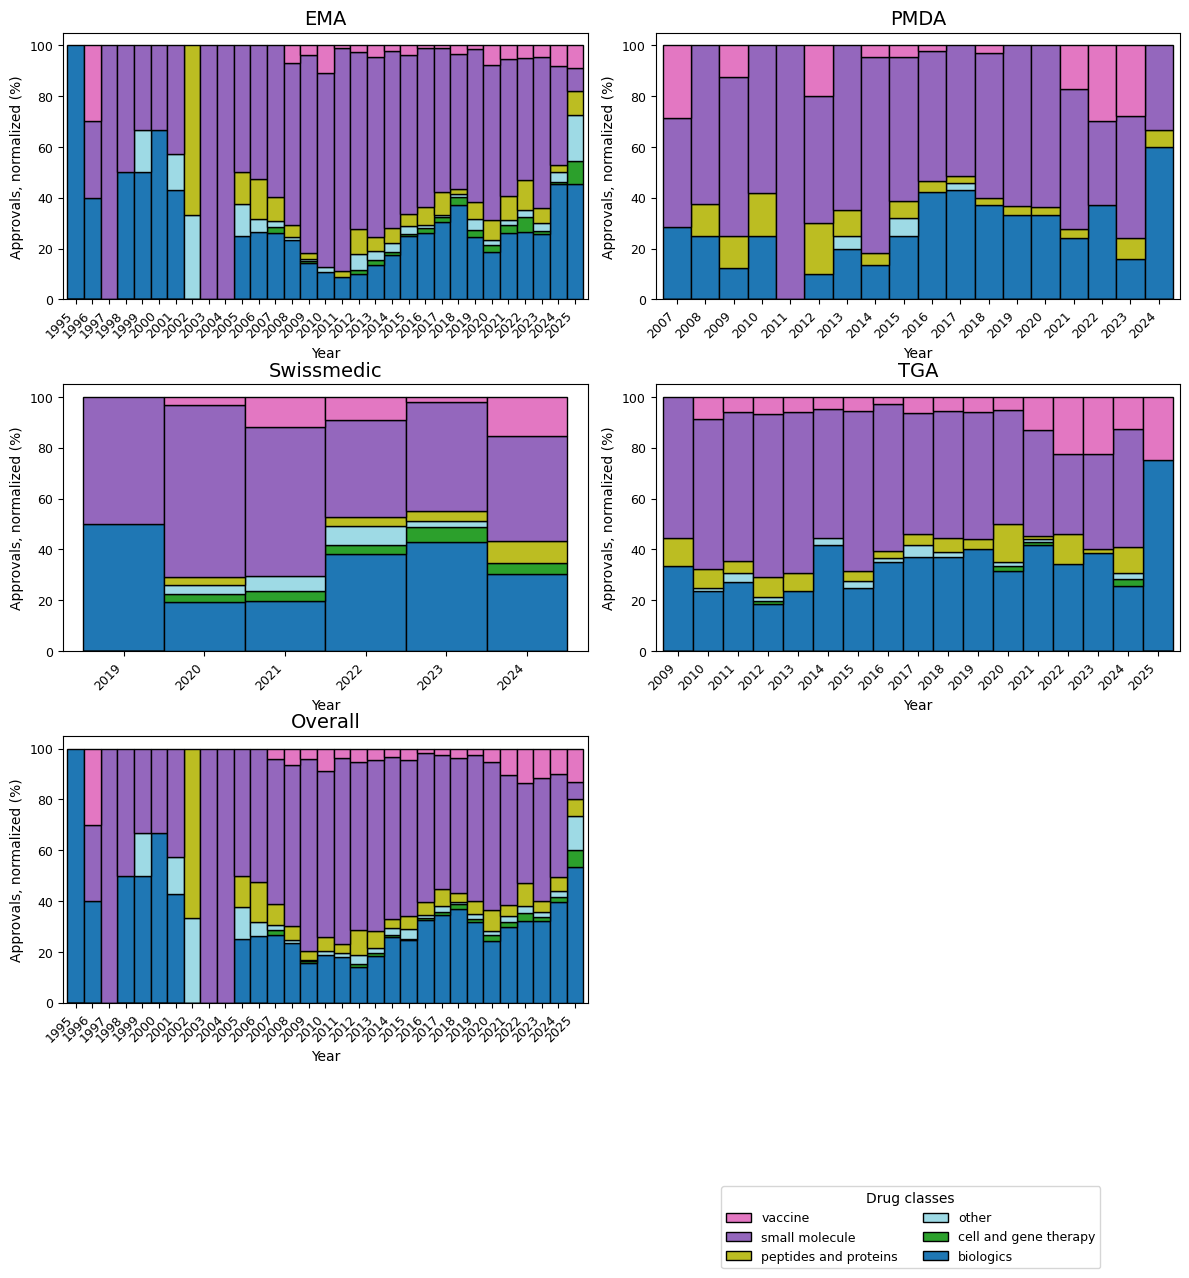

In [58]:
plot_some_class_per_year_panel(
    DATASETS, 
    bbox_to_anchor_val=(0.6, 0.2),
    date_col='Decision_year', 
    info_col="Drug_class",
    drug_class_colormap=drug_class_colormap, 
    nrows=4, 
    ncols=2,
    figsize_per_subplot=(6, 4)
)

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 1687, Final length after cleaning: 1687, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 408, Final length after cleaning: 408, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 234, Final length after cleaning: 234, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 1042, Final length after cleaning: 1042, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 3371, Final length after cleaning: 3371, Percentage kept: 100.00%


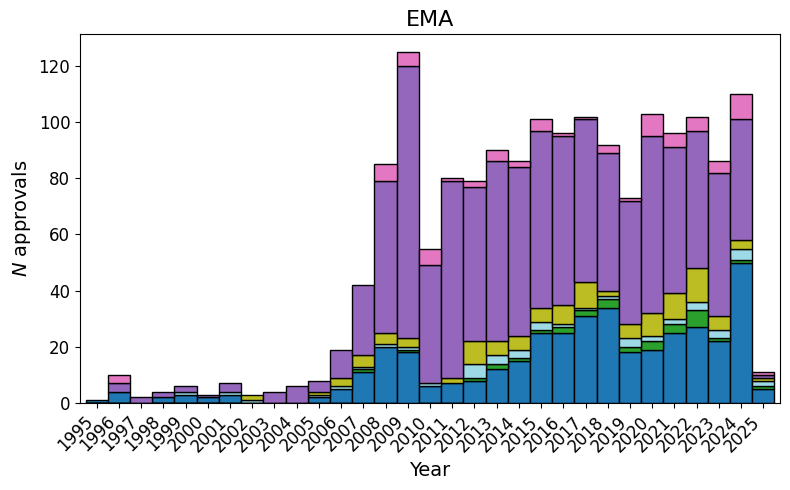

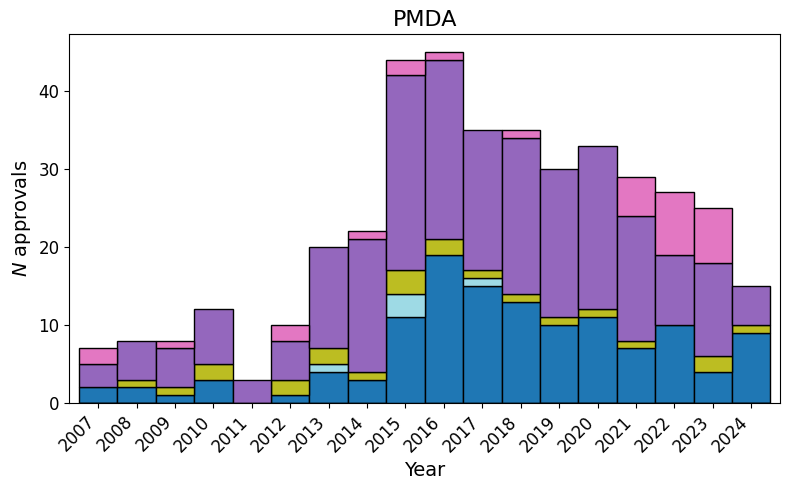

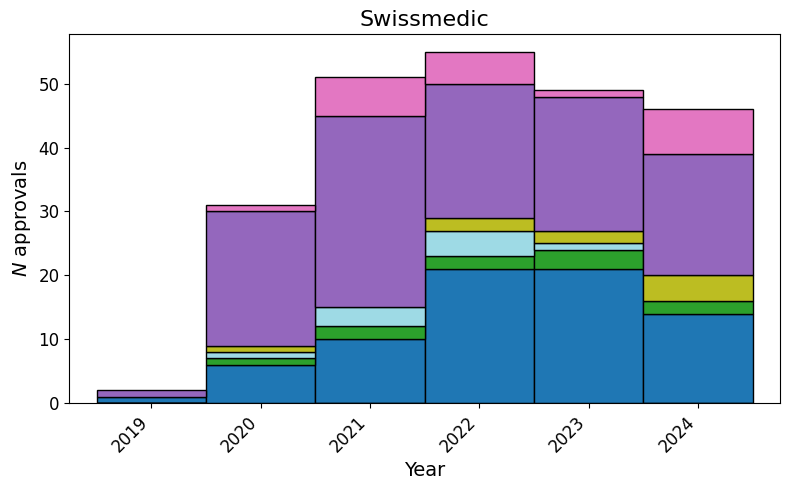

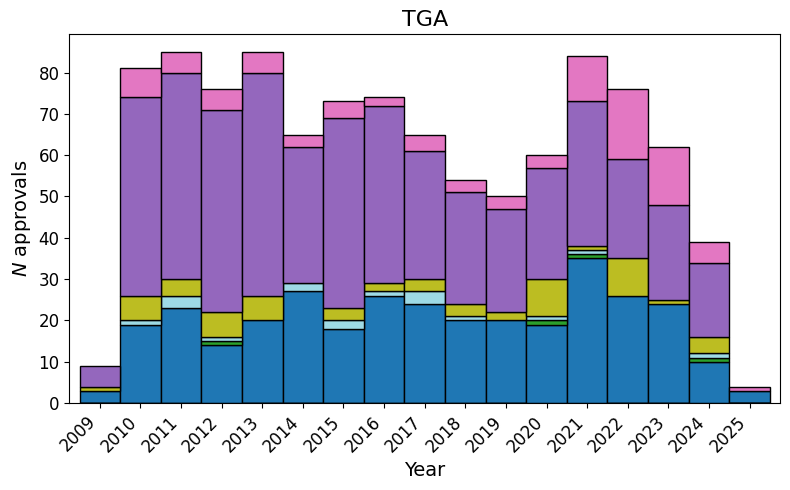

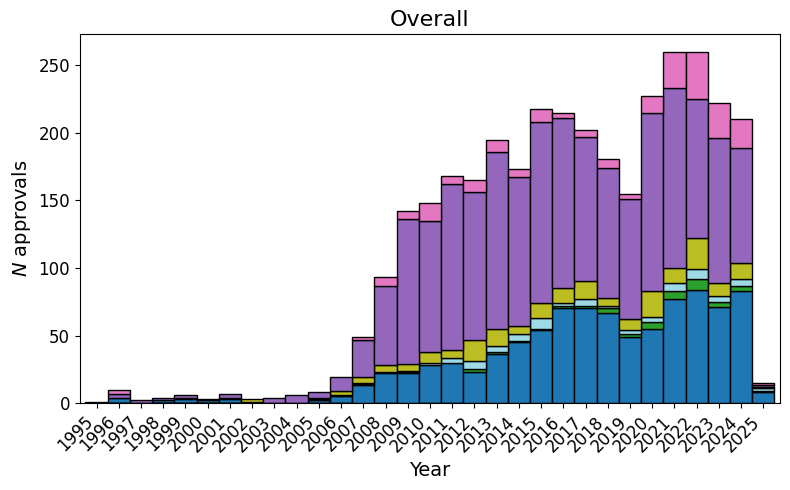

In [59]:
for k,v in DATASETS.items():
    if 'Decision_year' in v.columns:
        plot_drug_class_per_decision_year_absolute(v, drug_class_colormap=drug_class_colormap, dataset_name=k)
    else:
        print(f"{k}: 'Decision_year' column not found, skipping drug class plot.")

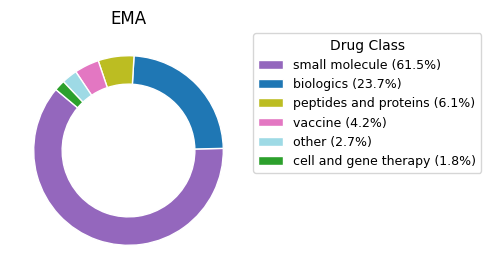

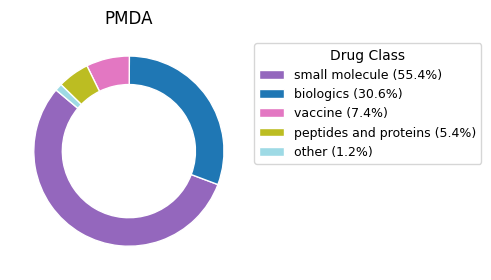

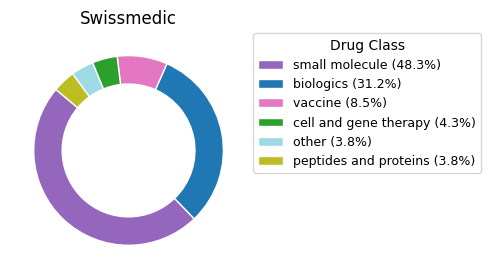

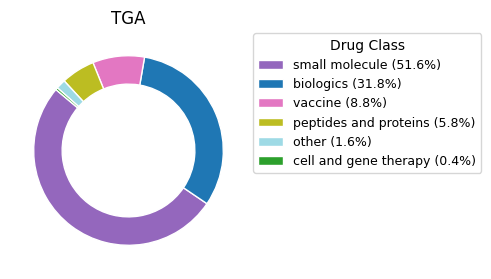

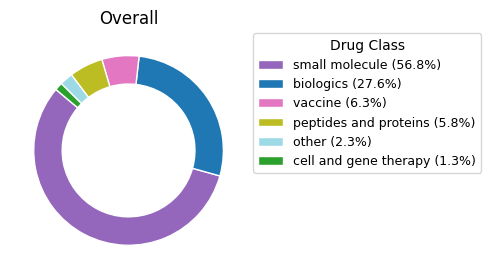

In [60]:
for k,v in DATASETS.items():
    if 'Drug_class' in v.columns:
        plot_drug_class_distribution_pie(v, drug_class_colormap, dataset_name=k)
    else:
        print(f"{k}: 'Drug_class' column not found, skipping drug class distribution pie chart.")

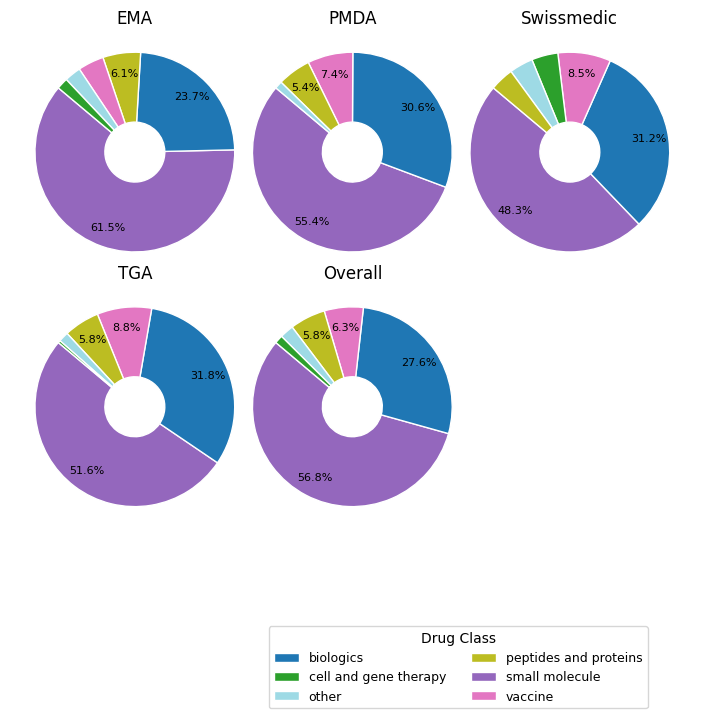

In [61]:
# Panel plot for drug class distribution (pie charts)
plot_drug_class_distribution_pie_panel(
    DATASETS, 
    drug_class_colormap=drug_class_colormap, 
    nrows=3, 
    ncols=3,
    figsize_per_subplot=(3, 3)
)

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 1687, Final length after cleaning: 1687, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 408, Final length after cleaning: 408, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 234, Final length after cleaning: 234, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 1042, Final length after cleaning: 1042, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 3371, Final length after cleaning: 3371, Percentage kept: 100.00%


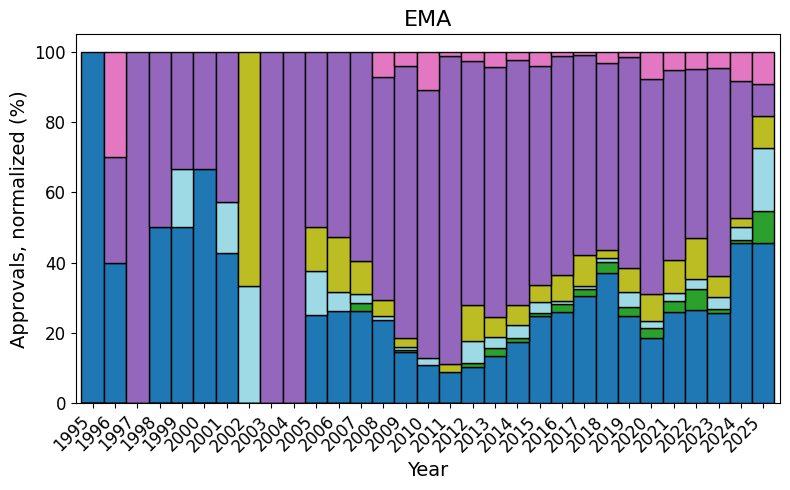

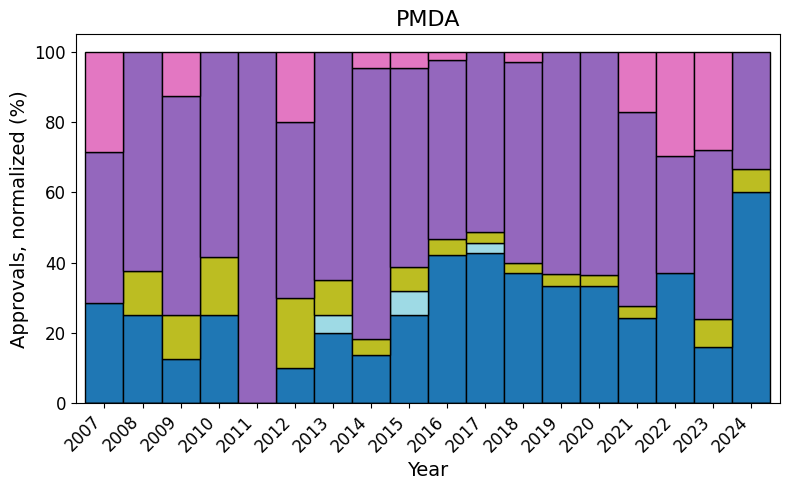

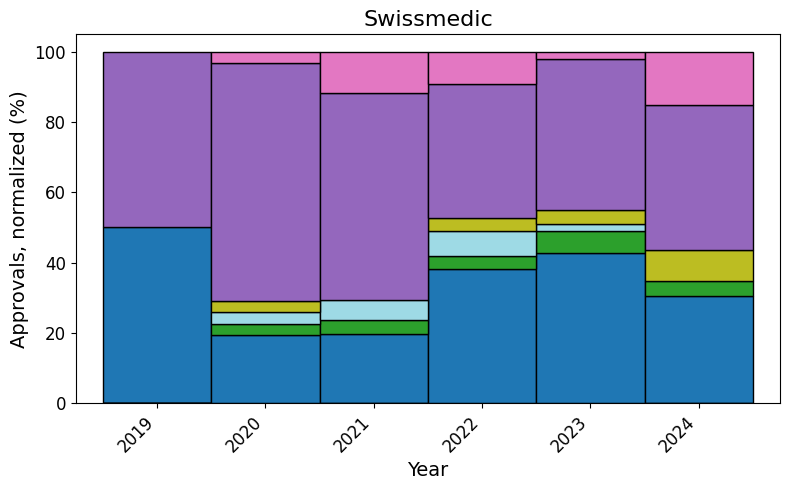

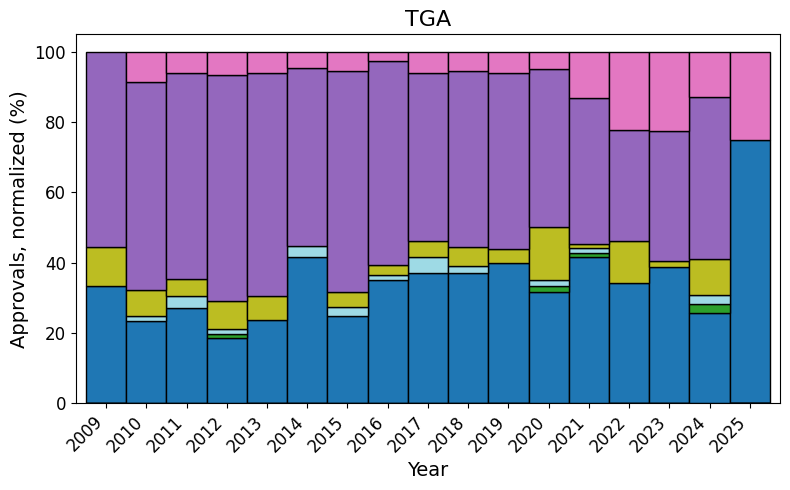

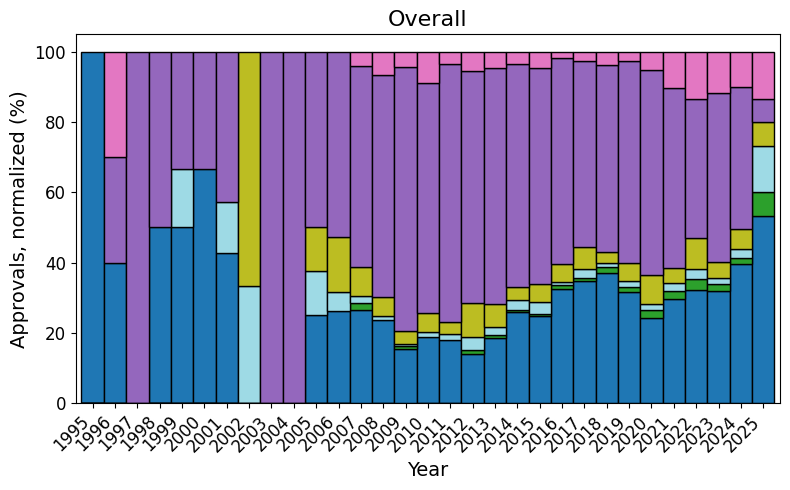

In [62]:
for k,v in DATASETS.items():
    if 'Decision_year' in v.columns:
        plot_drug_class_per_year(v, date_col='Decision_year', drug_class_colormap=drug_class_colormap, dataset_name=k)
    else:
        print(f"{k}: 'Decision_year' column not found, skipping disease class per decision year plot.")

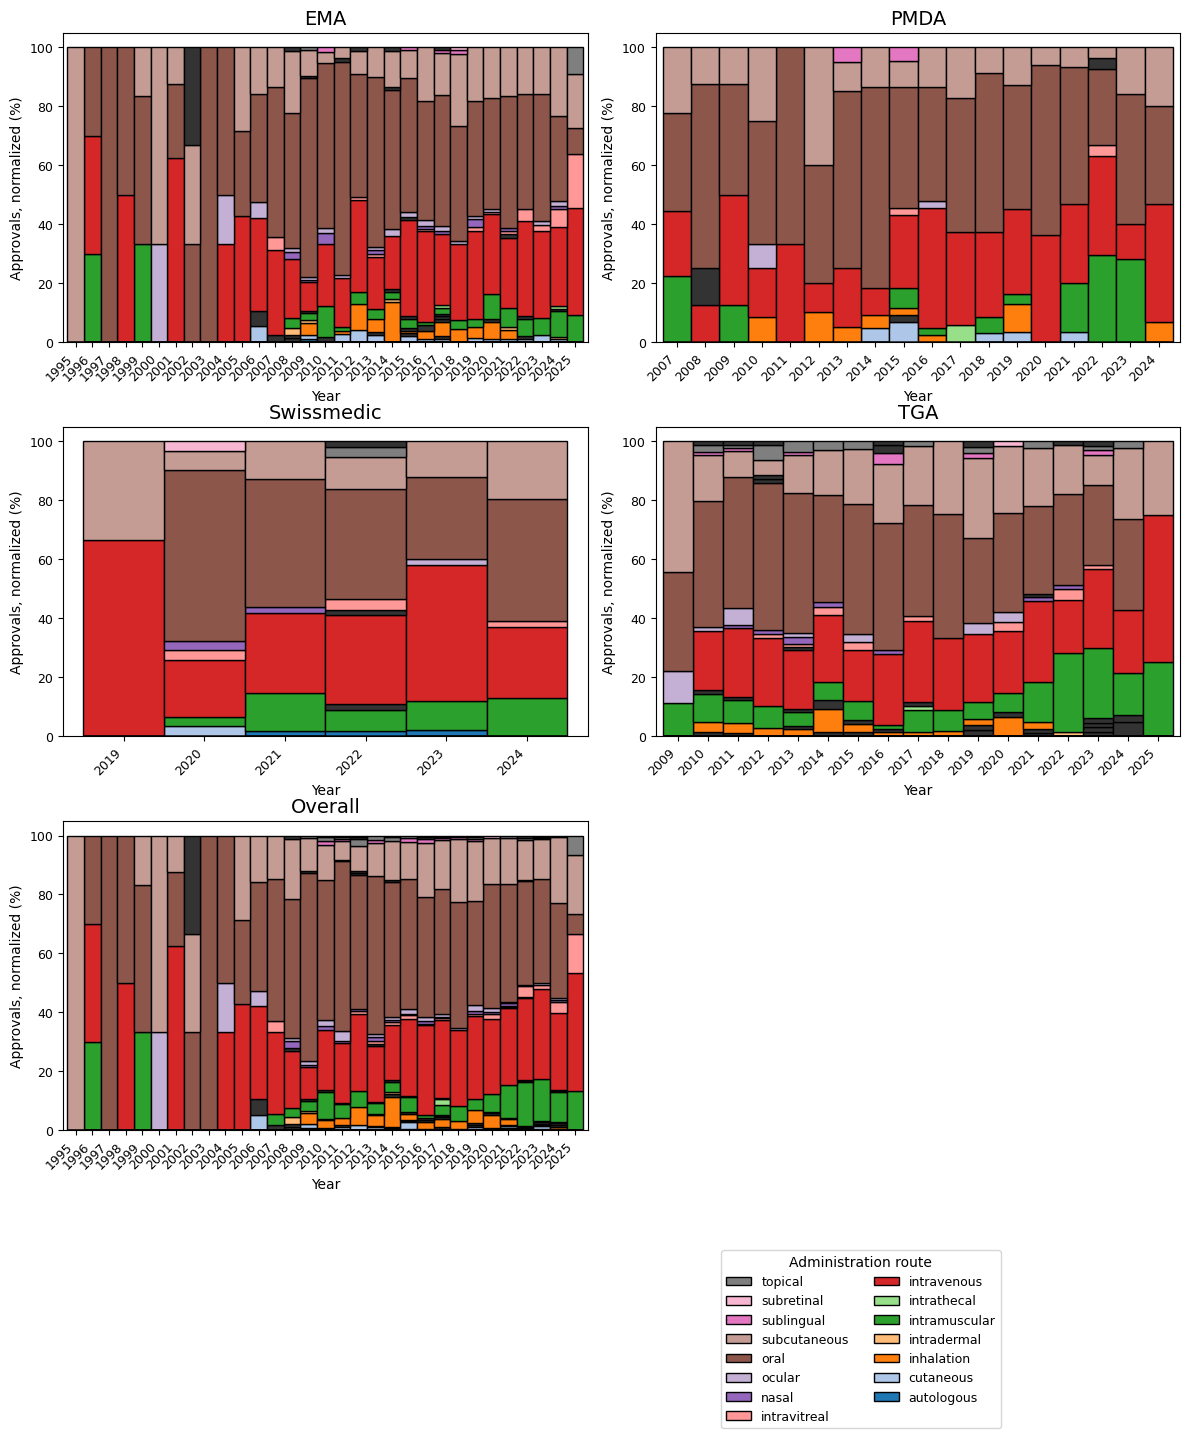

In [63]:
plot_some_class_per_year_panel(
    DATASETS, 
    bbox_to_anchor_val=(0.6, 0.2),
    date_col='Decision_year', 
    info_col="Administration_route",
    drug_class_colormap=admin_route_colormap,  # Changed from admin_route_cmap to admin_route_colormap
    nrows=4, 
    ncols=2,
    figsize_per_subplot=(6, 4.5)
)

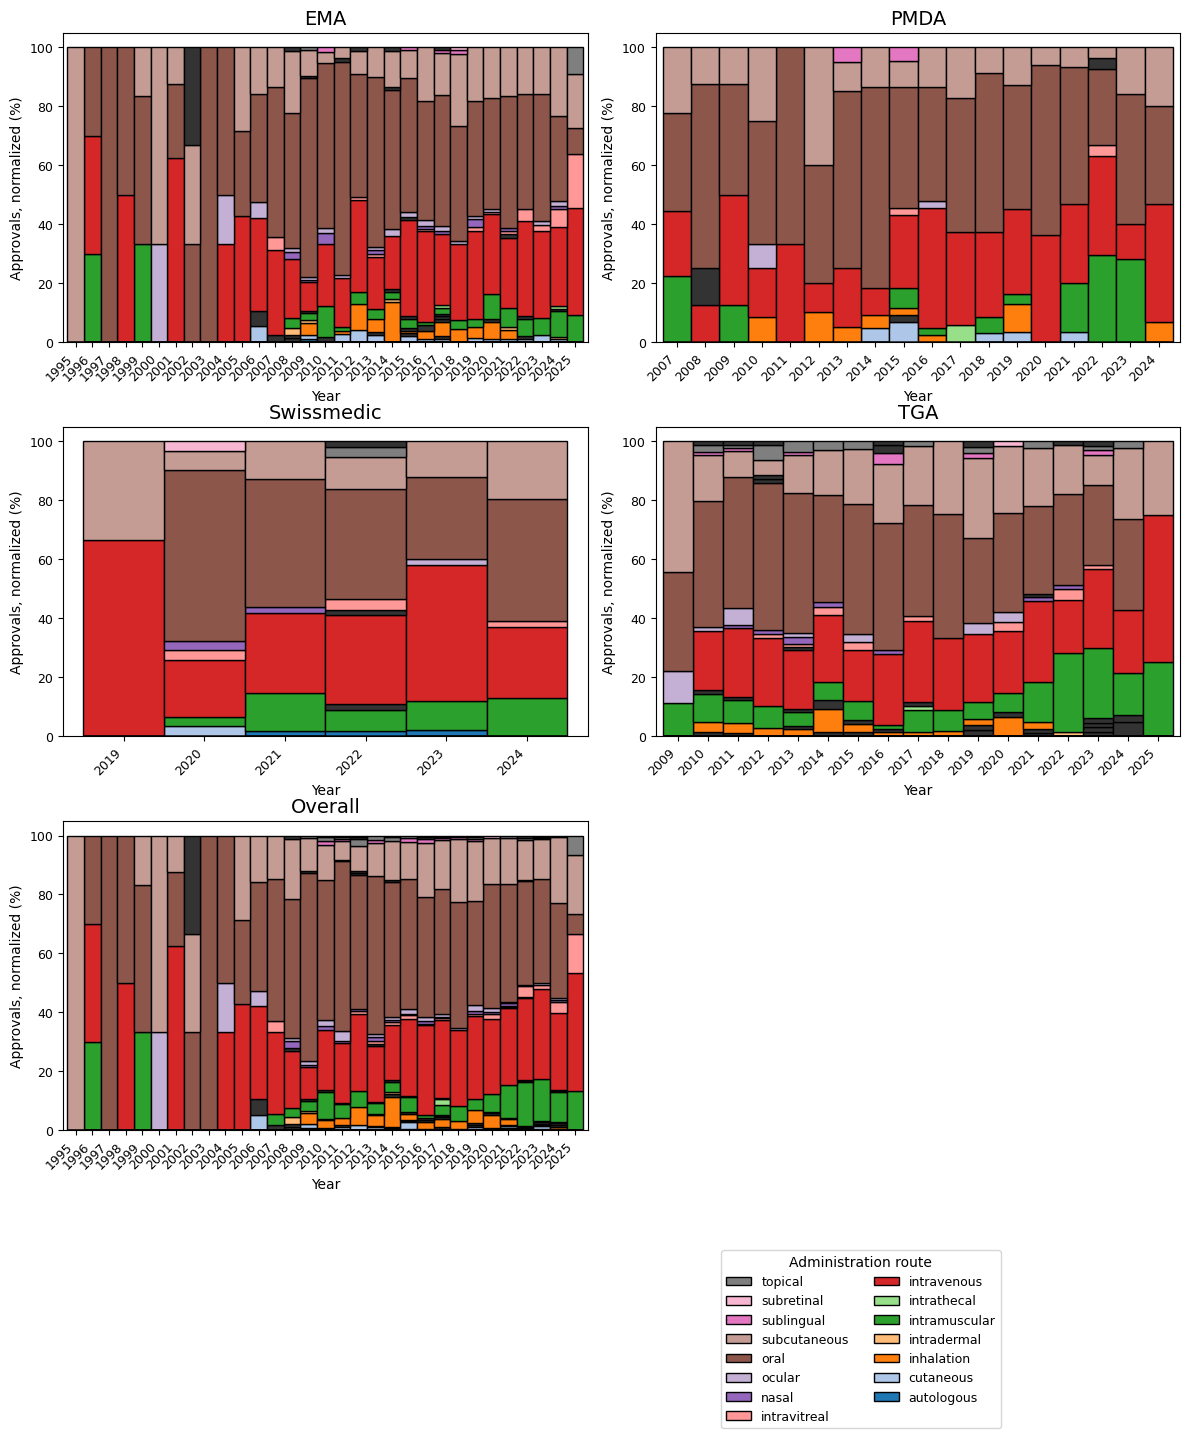

In [64]:
plot_some_class_per_year_panel(
    DATASETS, 
    bbox_to_anchor_val=(0.6, 0.2),
    date_col='Decision_year', 
    info_col="Administration_route",
    drug_class_colormap=admin_route_colormap, 
    nrows=4, 
    ncols=2,
    figsize_per_subplot=(6, 4.5)
)

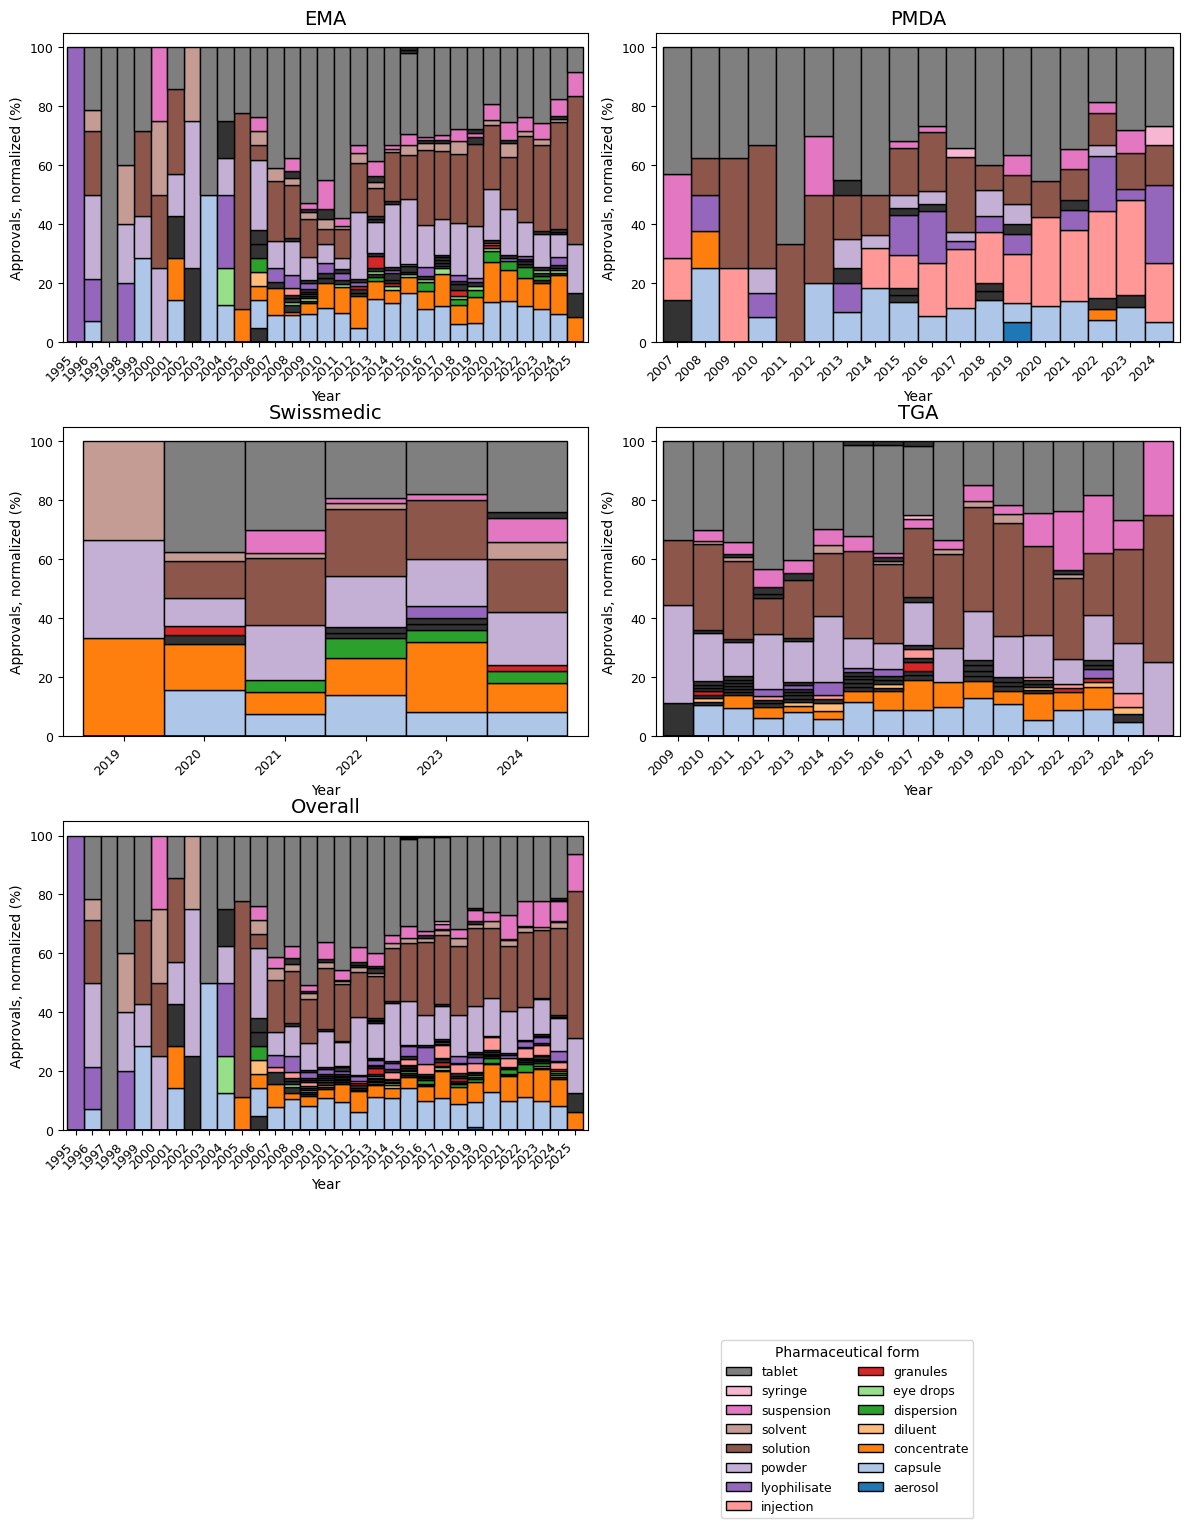

In [65]:
plot_some_class_per_year_panel(
    DATASETS, 
    bbox_to_anchor_val=(0.6, 0.15),
    date_col='Decision_year', 
    info_col="Pharmaceutical_form",
    drug_class_colormap=pharma_form_colormap, 
    nrows=4, 
    ncols=2,
    figsize_per_subplot=(6, 4.5)
)

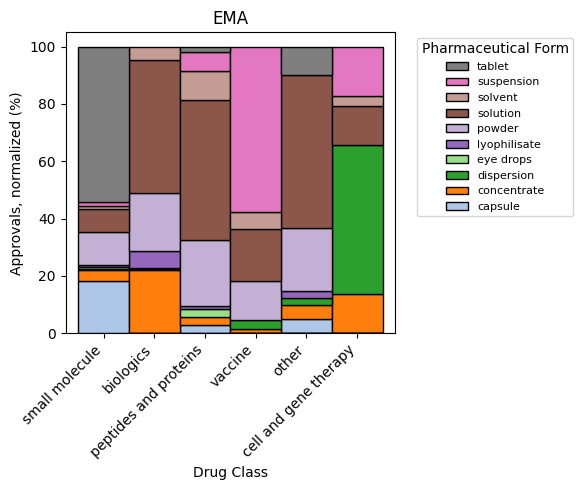

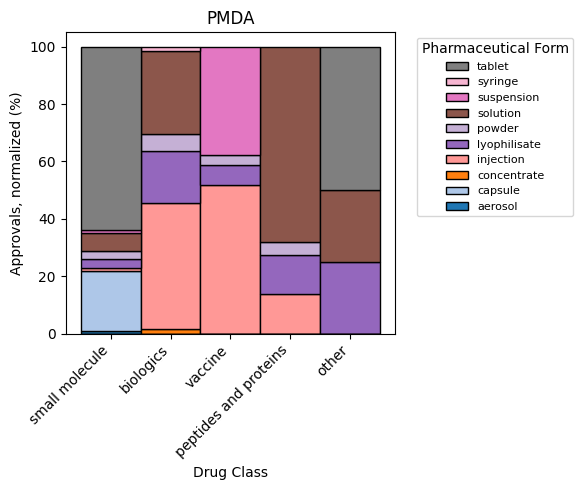

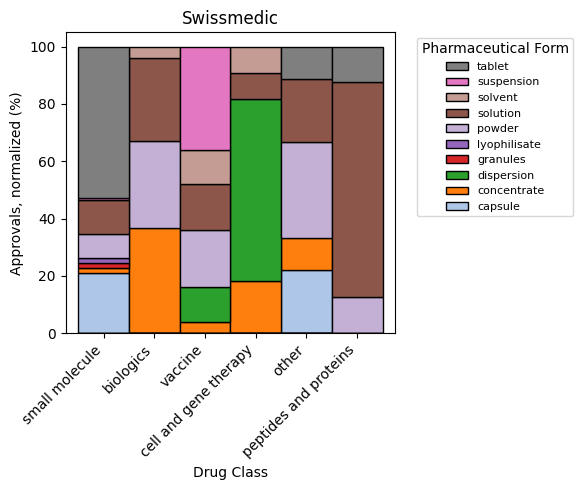

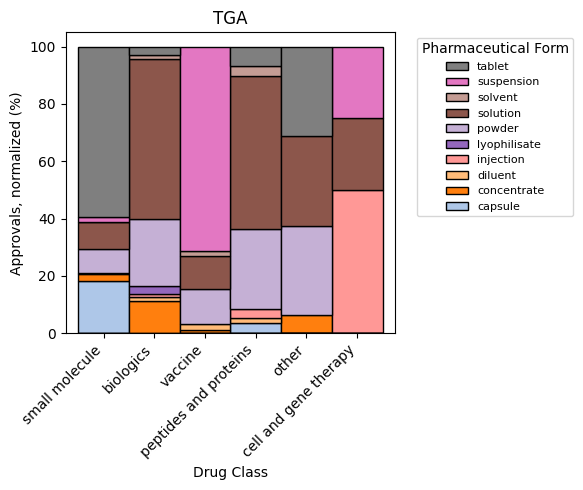

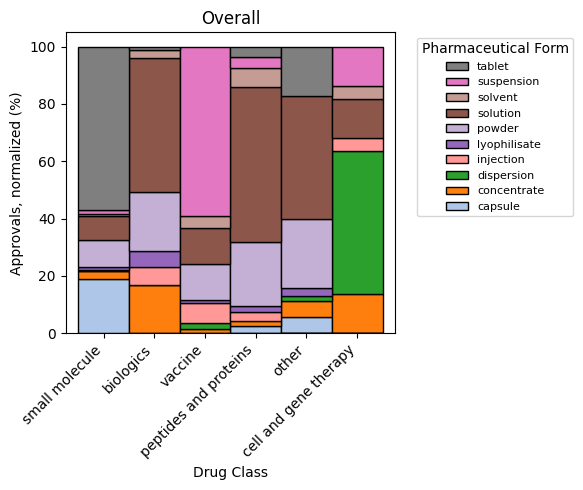

In [66]:
for k,v in DATASETS.items():
    if 'Pharmaceutical_form' in v.columns:
        plot_drug_class_by_pharmaceutical_form(v, pharma_form_colormap=pharma_form_colormap, dataset_name=k)
    else:
        print(f"{k}: 'Pharmaceutical_form' column not found, skipping drug class by pharmaceutical form plot.")

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:374: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:374: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:374: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:374: UserWarning: Parsing dates in %d.%m.%Y forma

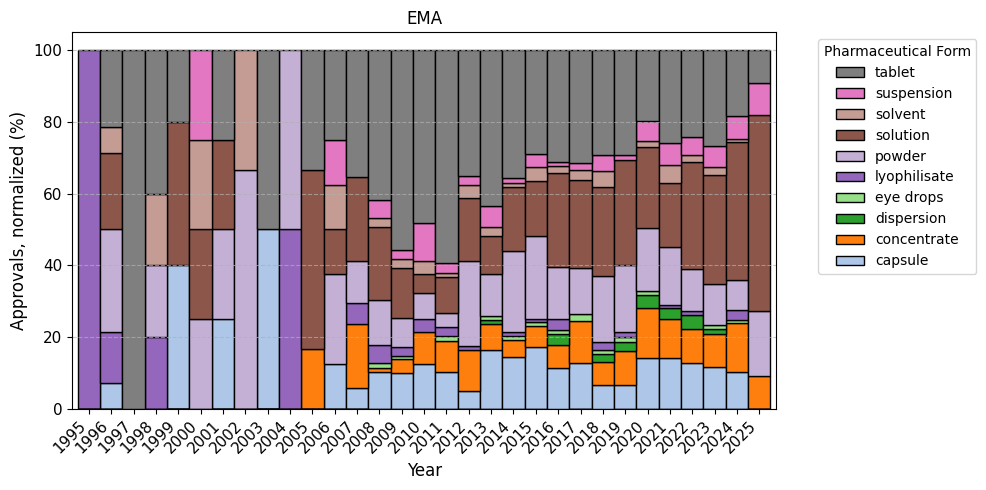

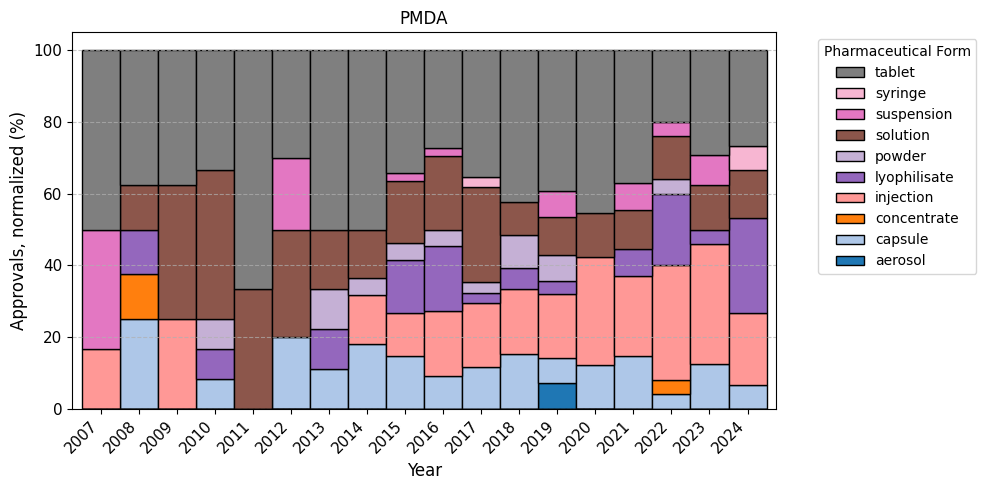

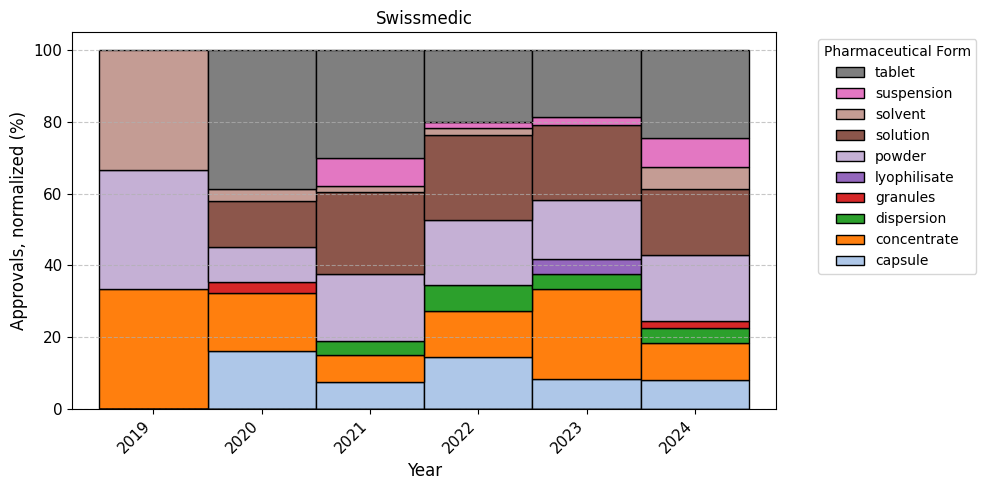

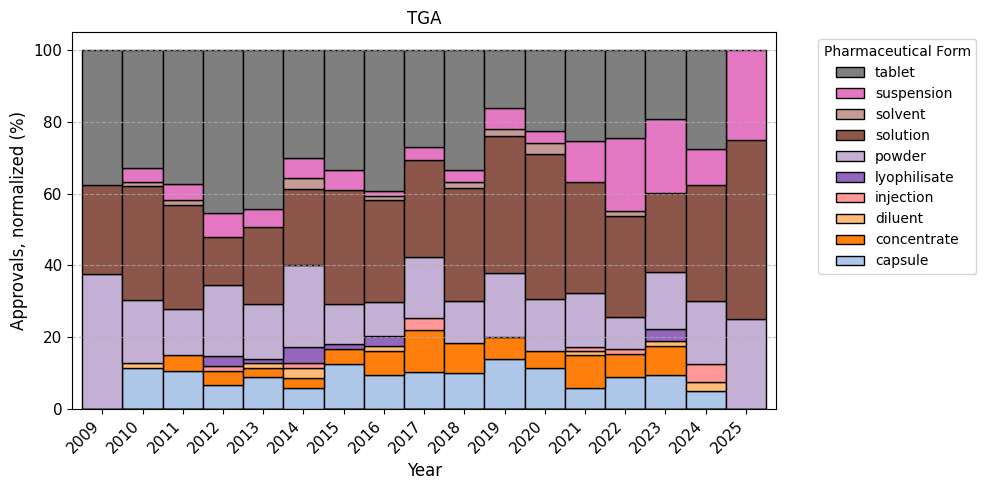

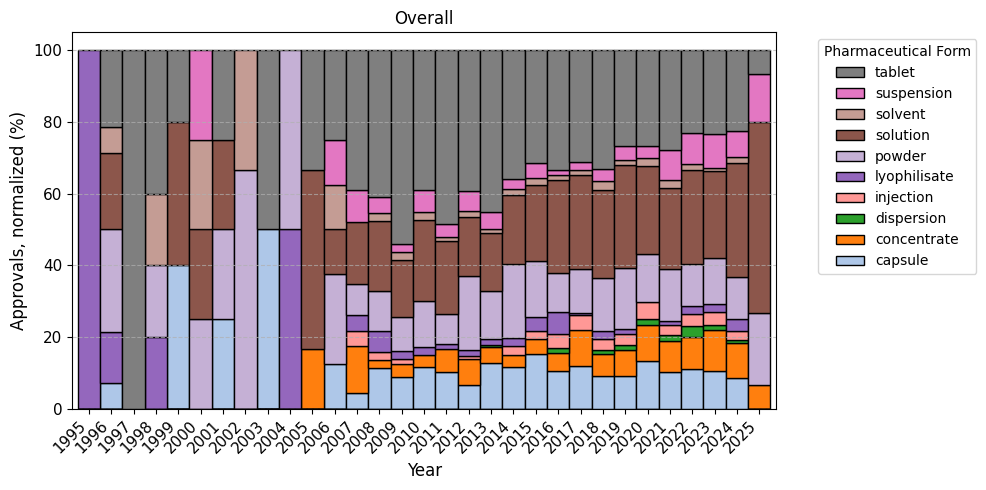

In [67]:
for k,v in DATASETS.items():
    if "Decision_date" in v.columns:
        plot_pharmaceutical_form_per_year(v, agency_name=k, date_col='Decision_date', pharma_form_colormap=pharma_form_colormap, dataset_name=k)
    else:
        print(f"{k}: 'Decision_date' column not found, skipping pharmaceutical form per year plot.")

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 1687, Final length after cleaning: 1687, Percentage kept: 100.00%

Top 2 Disease Classes (absolute Häufigkeit):
neoplasms: 479
diseases of the blood and blood-forming organs: 288


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 408, Final length after cleaning: 408, Percentage kept: 100.00%

Top 2 Disease Classes (absolute Häufigkeit):
neoplasms: 129
infectious and parasitic diseases: 79


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 234, Final length after cleaning: 234, Percentage kept: 100.00%

Top 2 Disease Classes (absolute Häufigkeit):
neoplasms: 73
diseases of the blood and blood-forming organs: 50


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 1042, Final length after cleaning: 1042, Percentage kept: 100.00%

Top 2 Disease Classes (absolute Häufigkeit):
neoplasms: 278
infectious and parasitic diseases: 182


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:12: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 3371, Final length after cleaning: 3371, Percentage kept: 100.00%

Top 2 Disease Classes (absolute Häufigkeit):
neoplasms: 959
infectious and parasitic diseases: 553


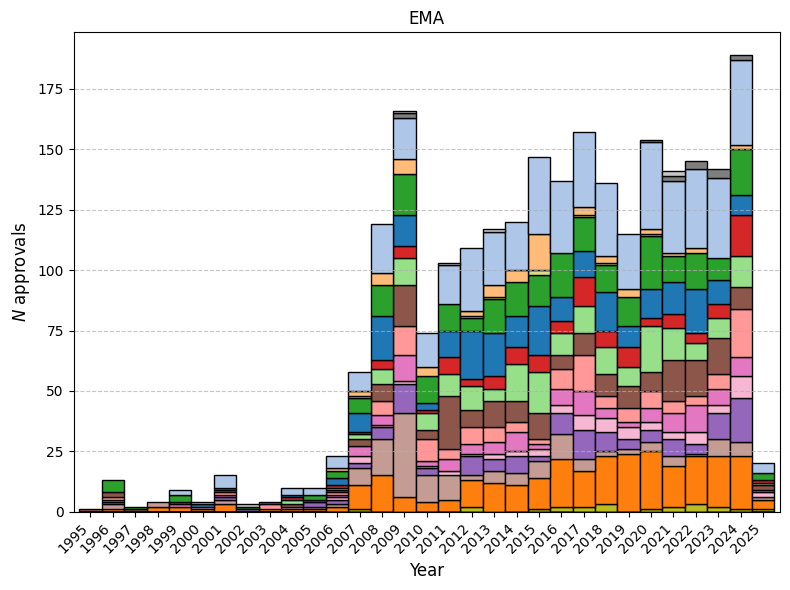

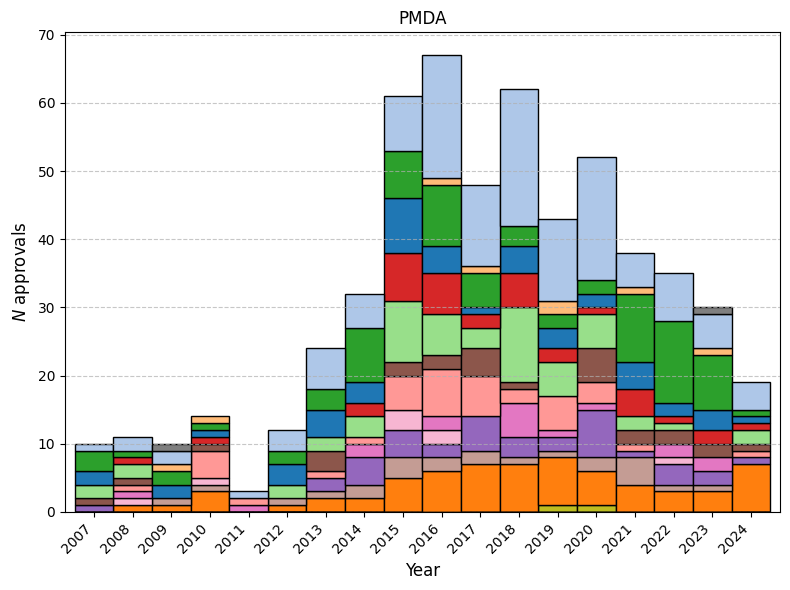

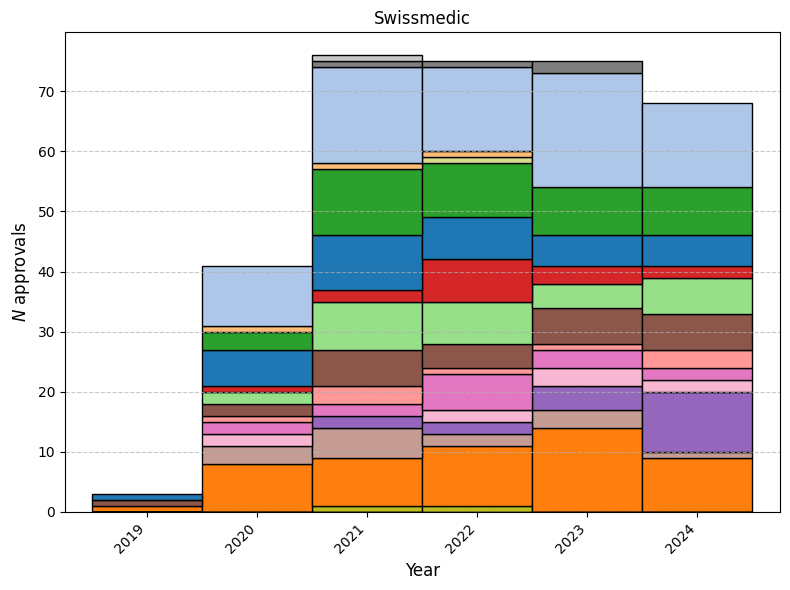

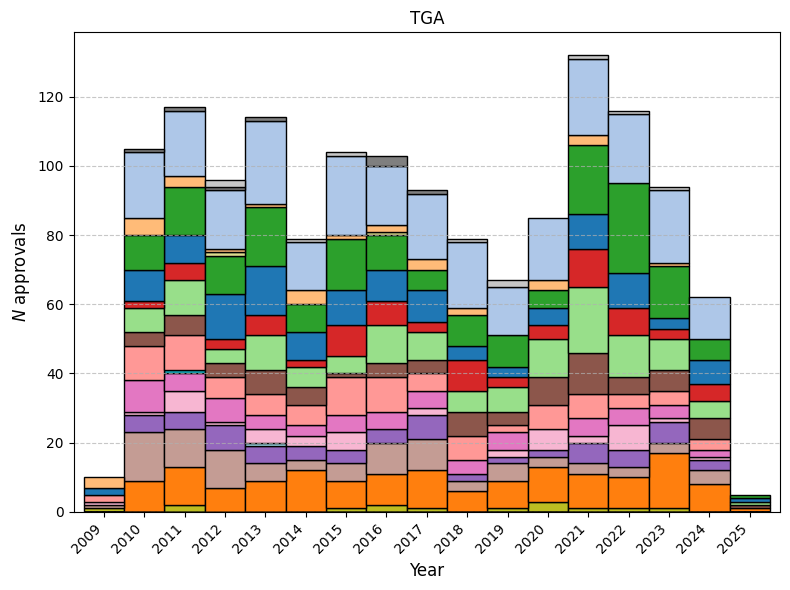

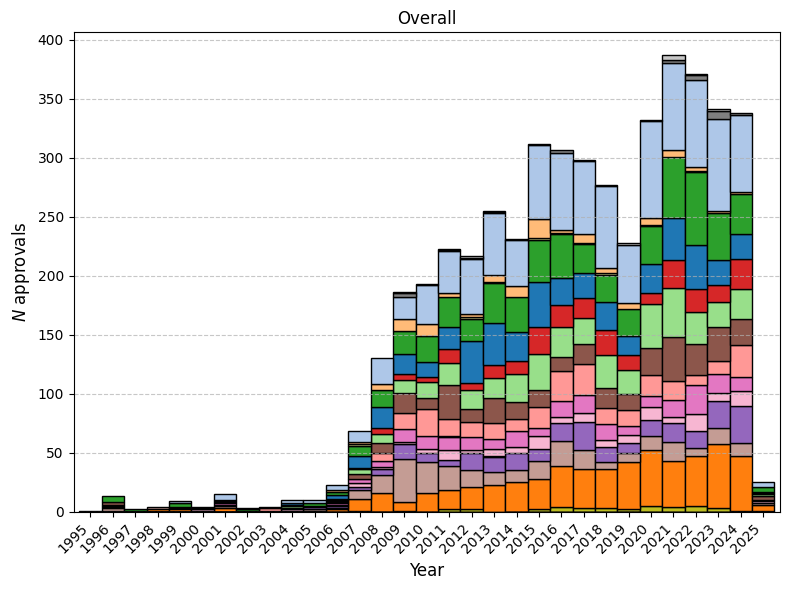

In [68]:
for k,v in DATASETS.items():
    if 'Decision_year' in v.columns and 'Disease_class(es)' in v.columns:
        plot_disease_class_per_decision_year_absolute(v, year_col='Decision_year', disease_class_colormap=disease_class_colormap, dataset_name=k)
    else:
        print(f"{k}: 'Decision_year' or 'Disease_class(es)' column not found, skipping disease class per decision year absolute plot.")

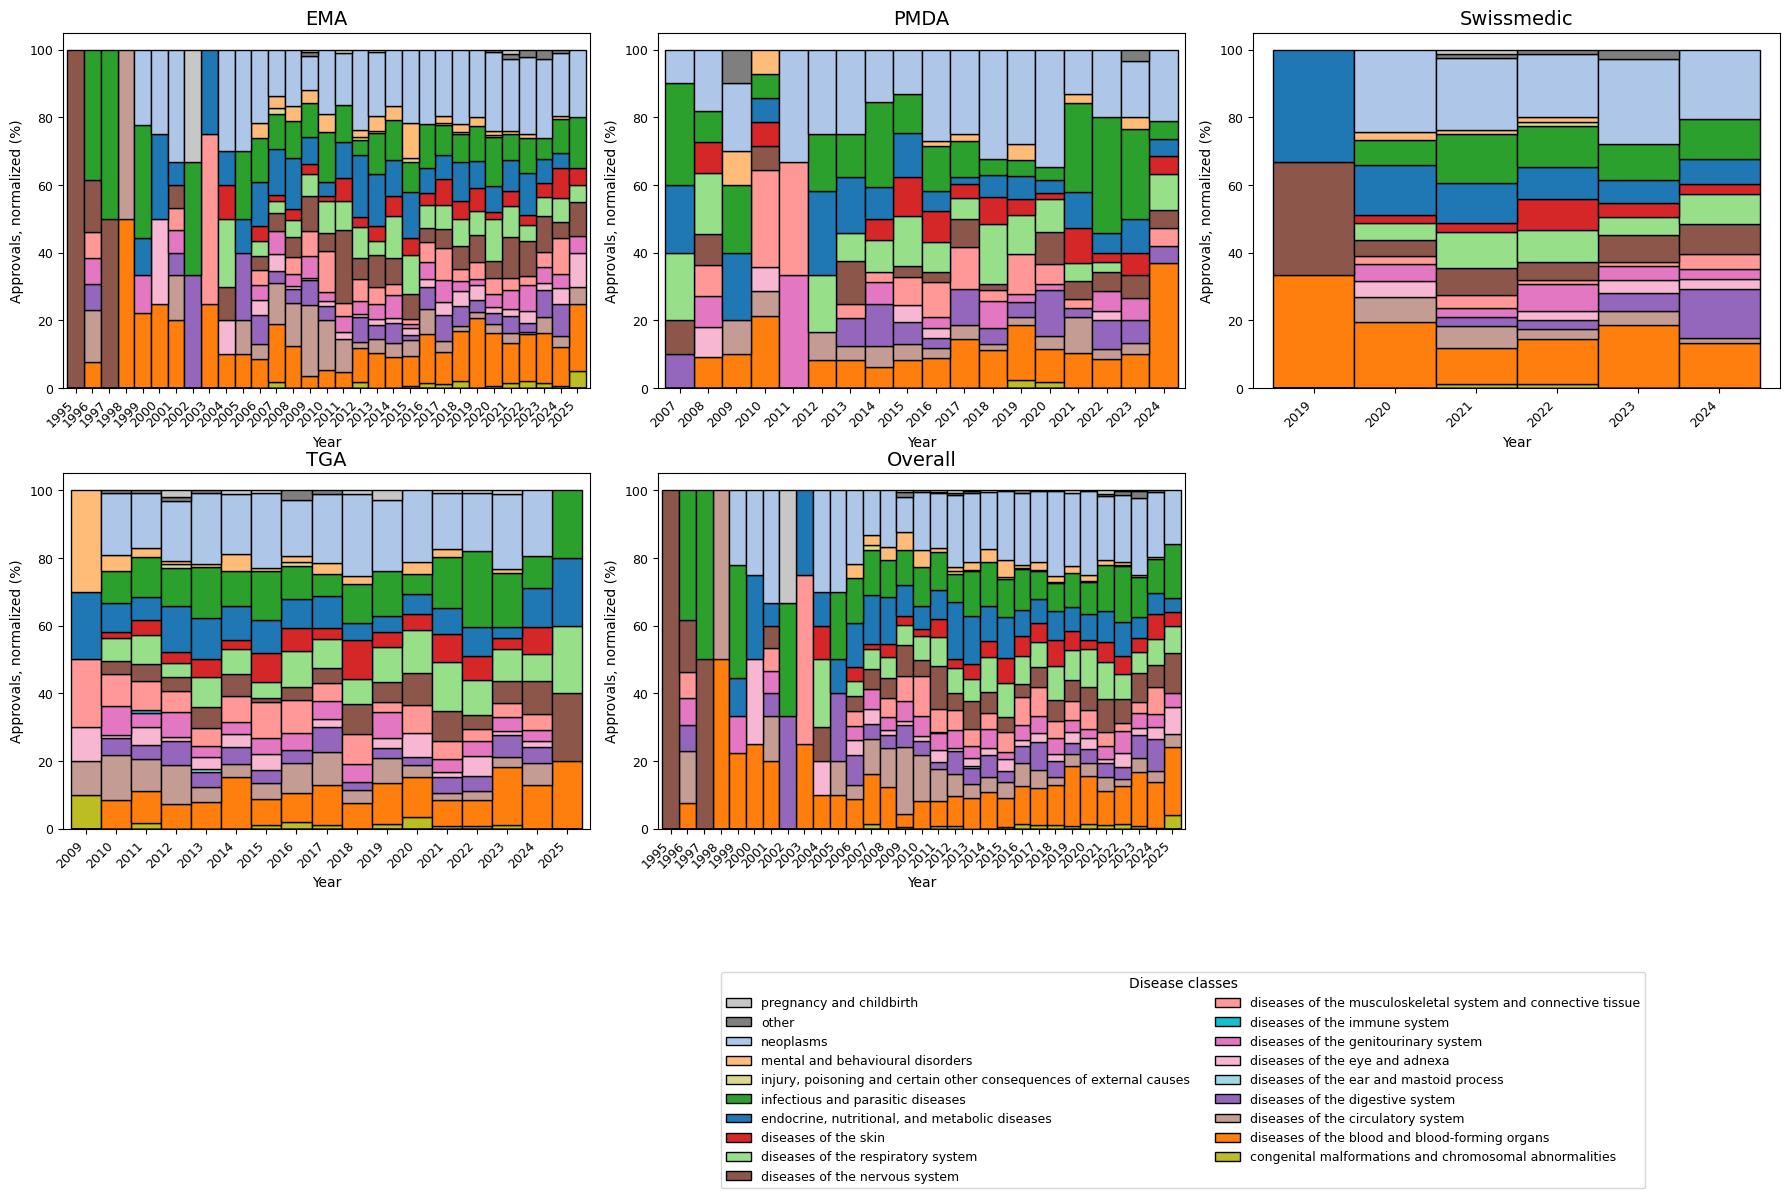

In [69]:
plot_some_class_per_year_panel(
    DATASETS, 
    bbox_to_anchor_val=(0.4, 0.2),
    date_col='Decision_year', 
    info_col="Disease_class(es)",
    drug_class_colormap=disease_class_colormap, 
    nrows=3, 
    ncols=3,
    figsize_per_subplot=(6, 5)
)

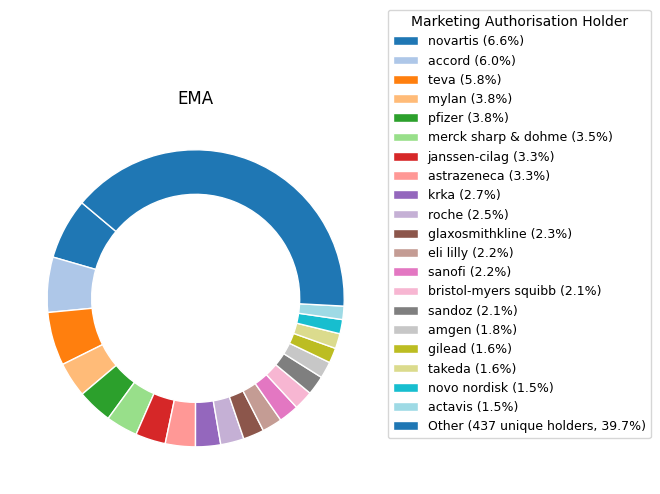

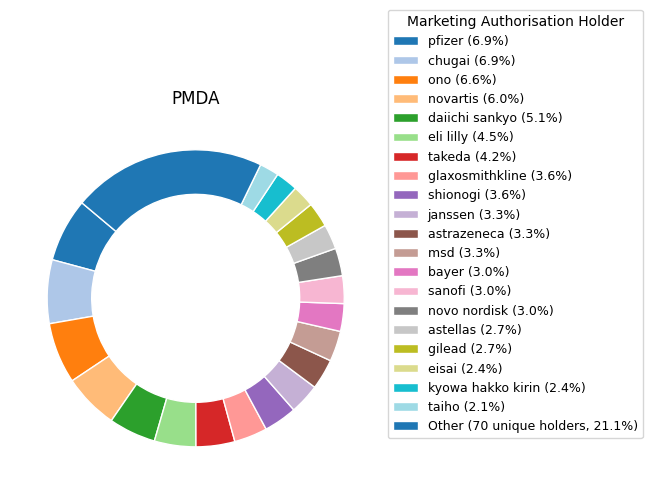

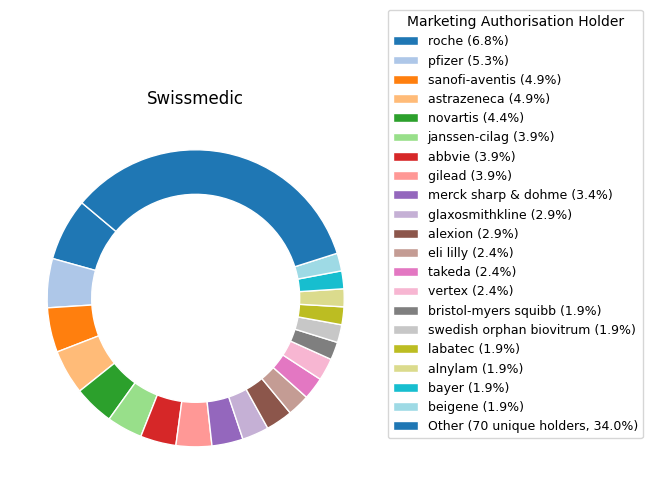

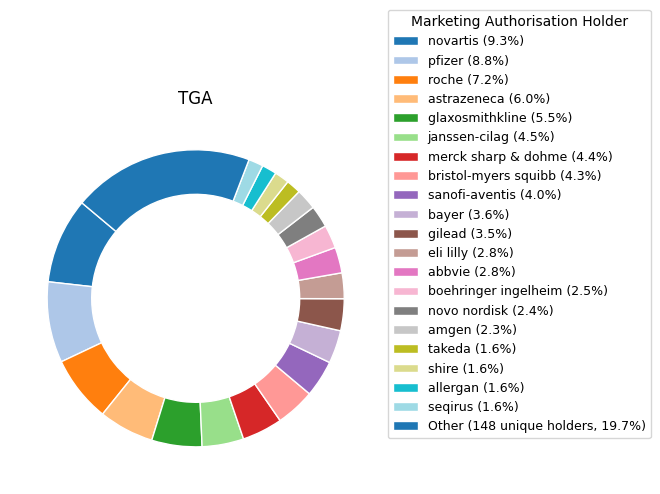

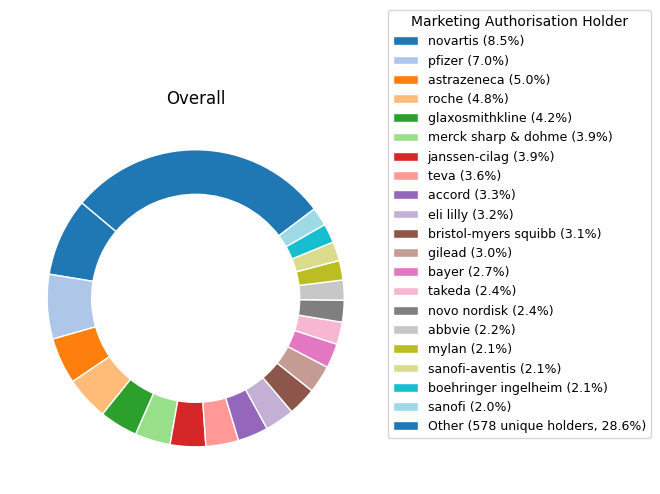

In [70]:
for k,v in DATASETS.items():
    if 'Marketing_authorisation_holder_extracted' in v.columns:
        plot_marketing_holder_distribution_pie(v, data_col='Marketing_authorisation_holder_extracted', dataset_name=k)
    else:
        if 'Marketing_authorisation_holder' in v.columns:
            plot_marketing_holder_distribution_pie(v, data_col='Marketing_authorisation_holder', dataset_name=k)
        else:
            print(f"{k}: 'Marketing_authorisation_holder' column not found, skipping marketing holder distribution pie chart.")
            continue

In [71]:
all_holders_combined = pd.concat(
    [EMA['Marketing_authorisation_holder'], 
     PMDA['Marketing_authorisation_holder'], 
     Swissmedic['Marketing_authorisation_holder']
     ])    
all_holders_combined = all_holders_combined.dropna().unique()

def sort_by_name(df, col_name):
    df = df.copy()
    df[col_name] = df[col_name].str.lower().str.strip()
    return df.sort_values(by=col_name)

EMA_sorted = sort_by_name(EMA, 'Marketing_authorisation_holder')
PMDA_sorted = sort_by_name(PMDA, 'Marketing_authorisation_holder')
SWISSMEDIC_sorted = sort_by_name(Swissmedic, 'Marketing_authorisation_holder')

EMA_sorted_unique = EMA_sorted['Marketing_authorisation_holder'].unique()
PMDA_sorted_unique = PMDA_sorted['Marketing_authorisation_holder'].unique()
SWISSMEDIC_sorted_unique = SWISSMEDIC_sorted['Marketing_authorisation_holder'].unique()

with open(f"{SAVE_DIR}/EMA_marketing_authorisation_holders.txt", 'w', encoding="utf-8") as f:
    for holder in EMA_sorted_unique:
        f.write(f"{holder}\n")
with open(f"{SAVE_DIR}/PMDA_marketing_authorisation_holders.txt", 'w') as f:
    for holder in PMDA_sorted_unique:
        f.write(f"{holder}\n")
with open(f"{SAVE_DIR}/SWISSMEDIC_marketing_authorisation_holders.txt", 'w') as f:
    for holder in SWISSMEDIC_sorted_unique:
        f.write(f"{holder}\n")


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:572: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Nonclinical_abridged'] = valid['Nonclinical_abridged'].str.lower().str.strip()
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:572: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Nonclinical_abridged'] = valid['Nonclinical_abridged'].str.lower().str.strip()
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:572: SettingWithCopyWarning: 
A value is

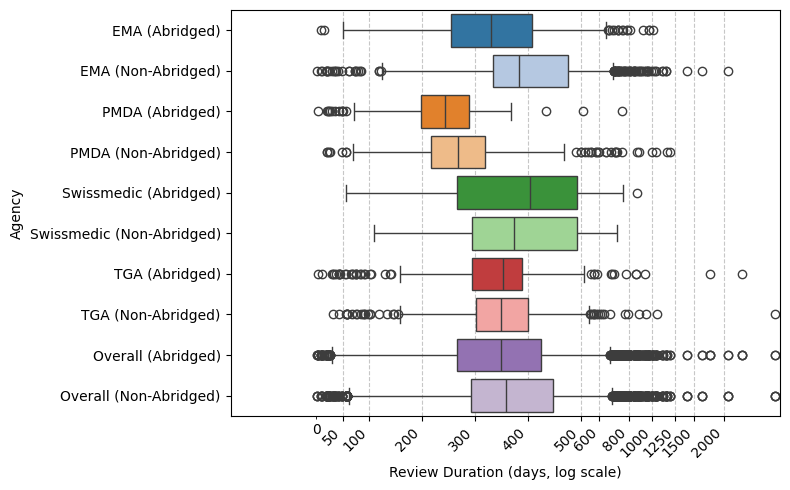

In [72]:
plot_review_duration_by_agency(
    agency_dfs=DATASETS,
    submission_col='Application_date',
    decision_col='Decision_date',
    dataset_name='combined'
)

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:677: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days',
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:677: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days',
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:677: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days',
C:\User

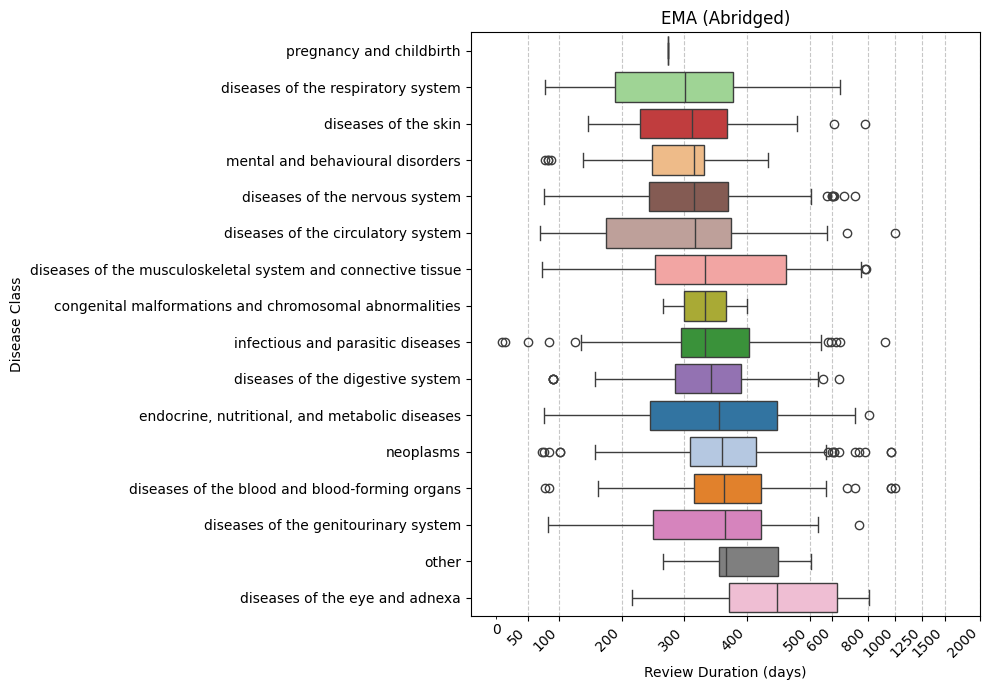

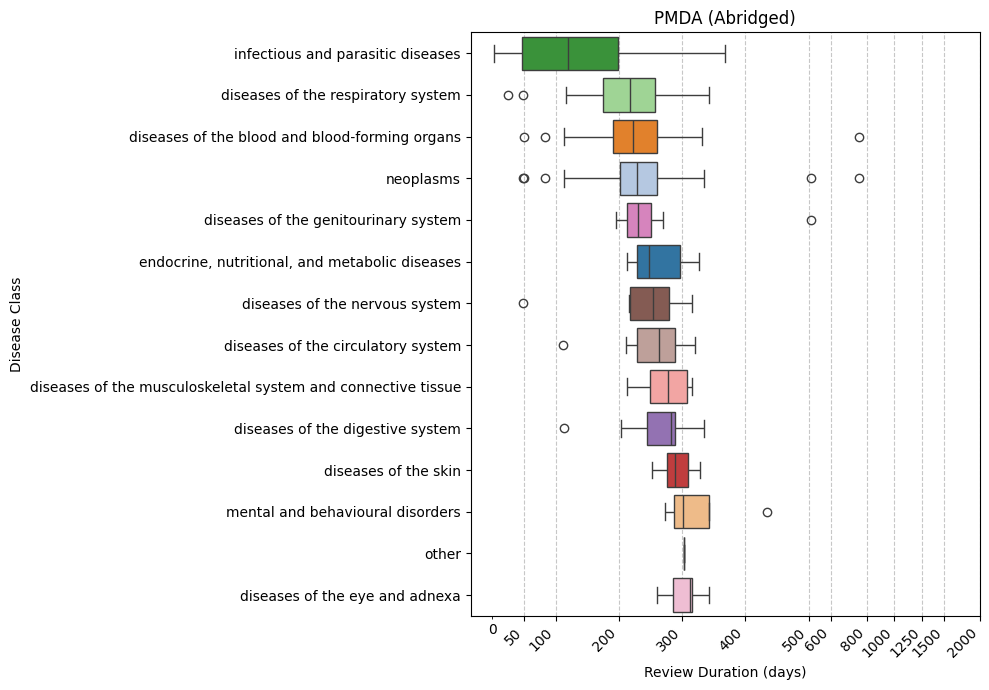

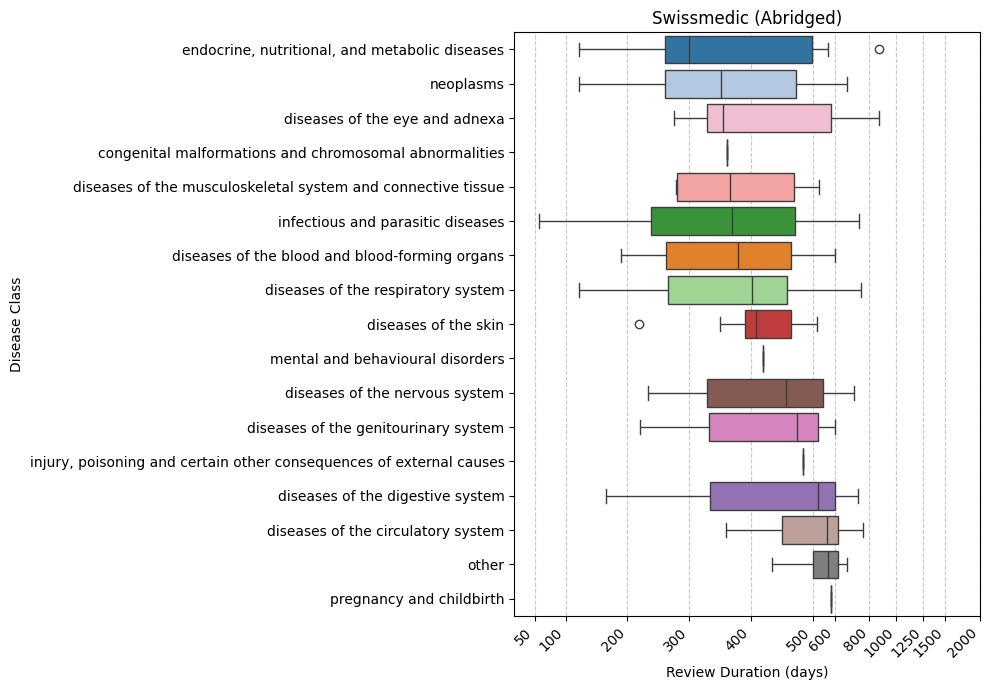

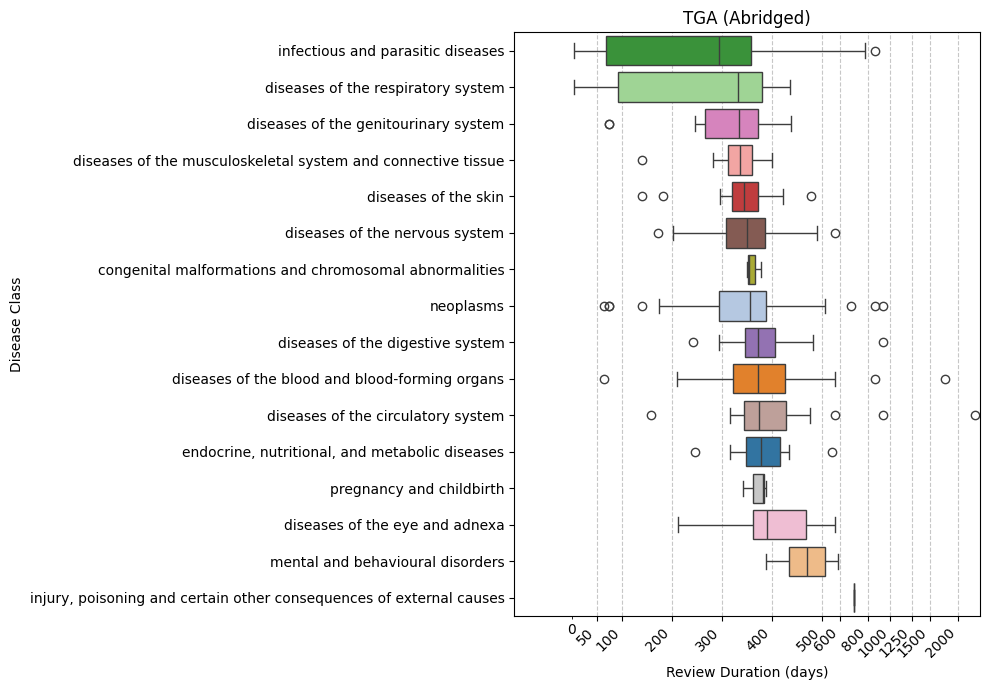

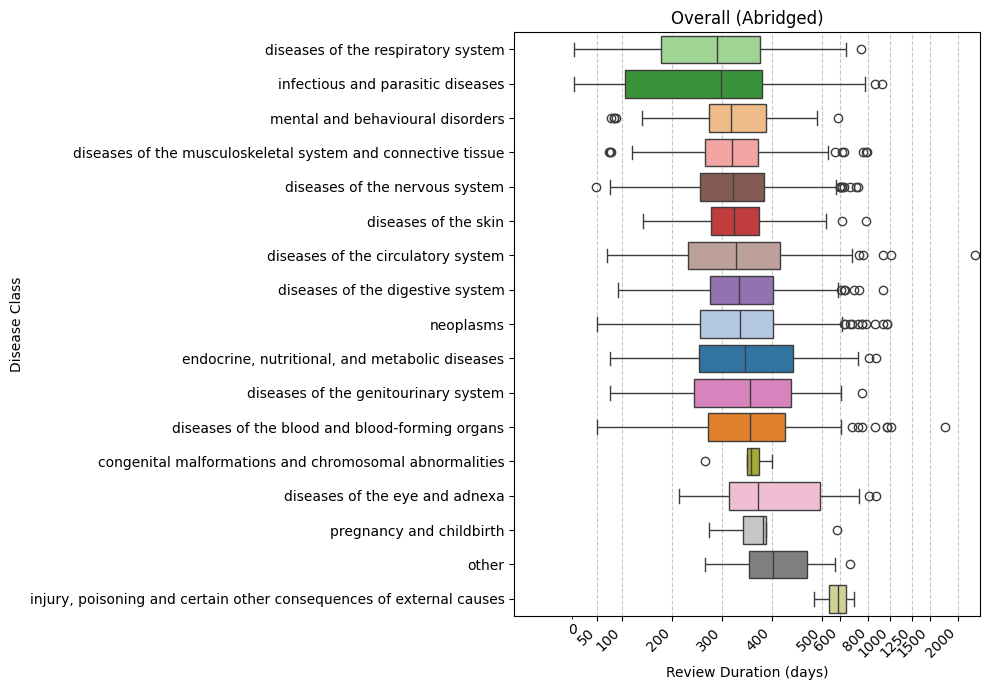

In [73]:
for k,v in DATASETS.items():
    if 'Application_date' in v.columns and 'Decision_date' in v.columns:
        plot_review_duration_by_disease_class(
            v,
            submission_col='Application_date',
            decision_col='Decision_date',
            dataset_name=k,
            disease_class_colormap=disease_class_colormap,
            abridged=True
        )
    else:
        print(f"{k}: 'Application_date' or 'Decision_date' column not found, skipping review duration by agency plot.")

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:677: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days',
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:677: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days',
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:677: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days',
C:\User

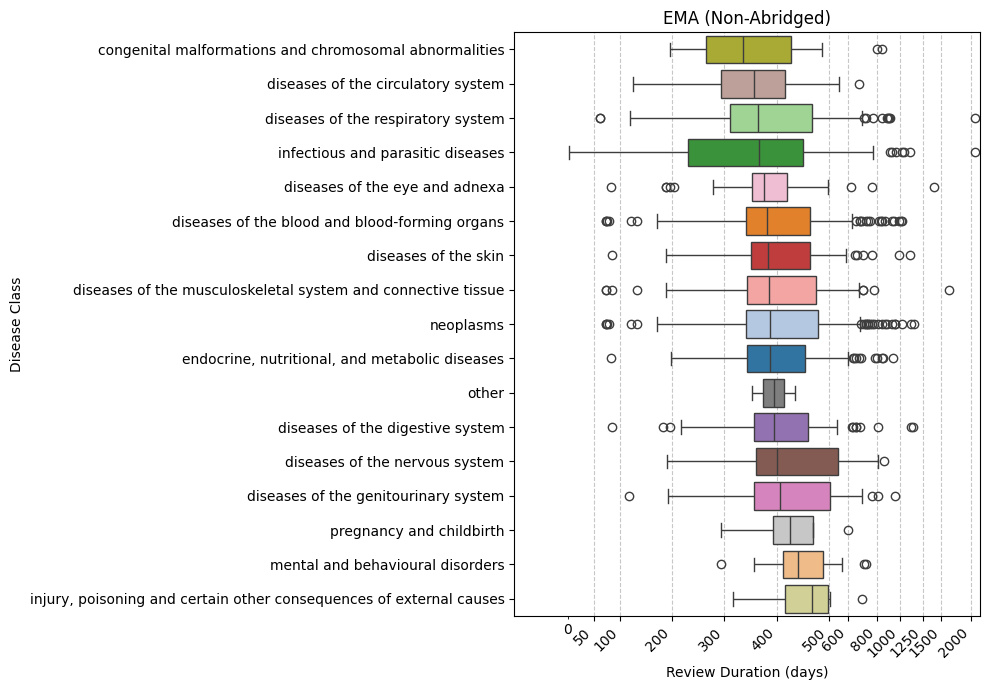

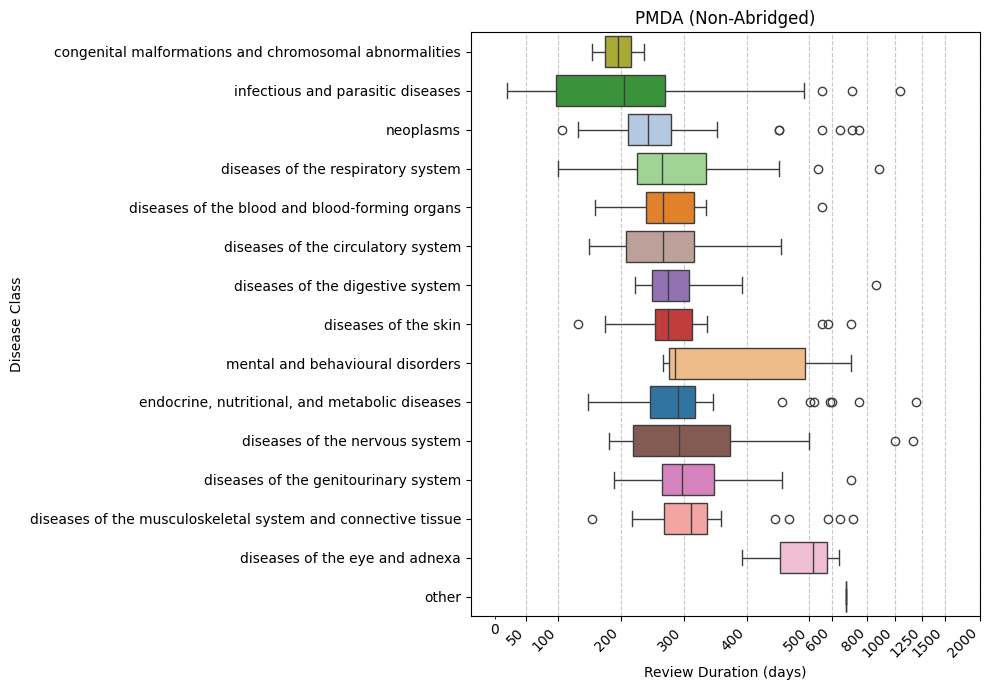

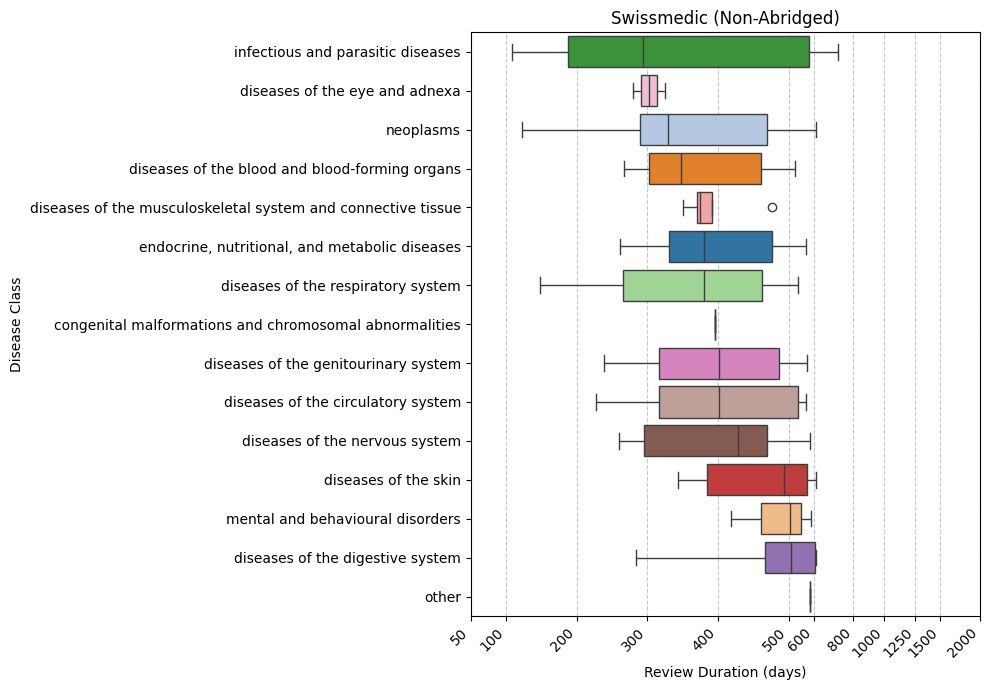

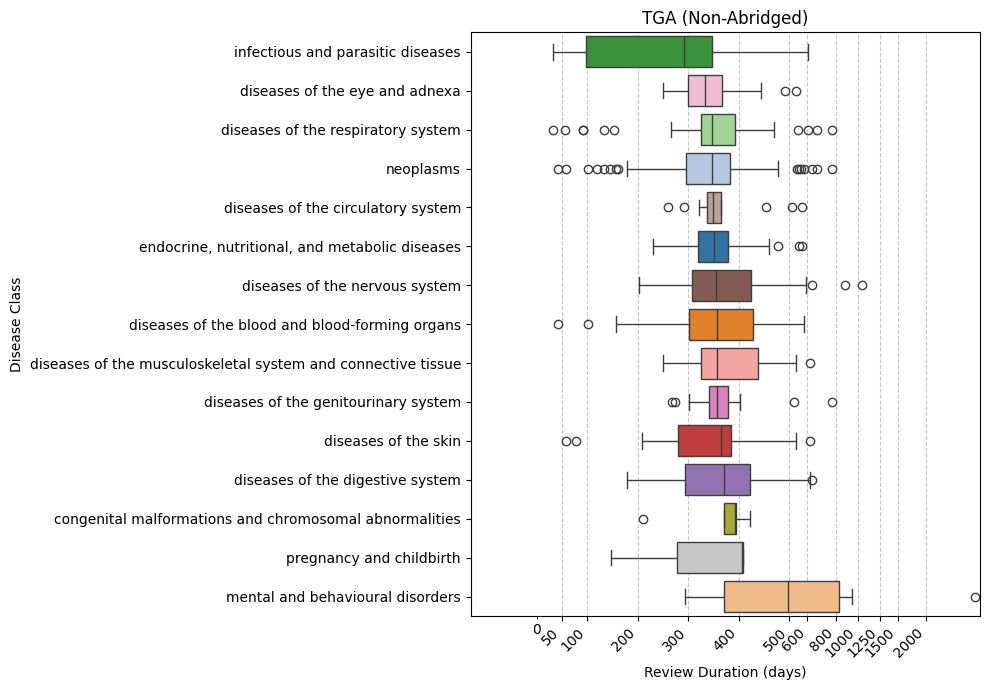

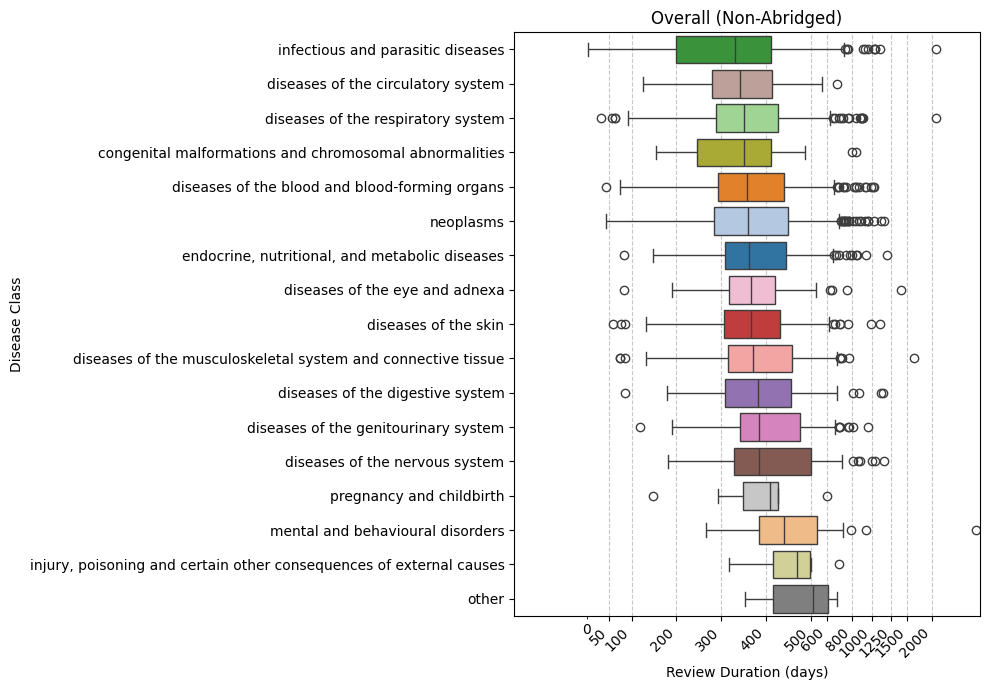

In [74]:
for k,v in DATASETS.items():
    if 'Application_date' in v.columns and 'Decision_date' in v.columns:
        plot_review_duration_by_disease_class(
            v,
            submission_col='Application_date',
            decision_col='Decision_date',
            dataset_name=k,
            disease_class_colormap=disease_class_colormap,
            abridged=False
        )
    else:
        print(f"{k}: 'Application_date' or 'Decision_date' column not found, skipping review duration by agency plot.")

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:677: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days',
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:677: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days',
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:677: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days',
C:\User

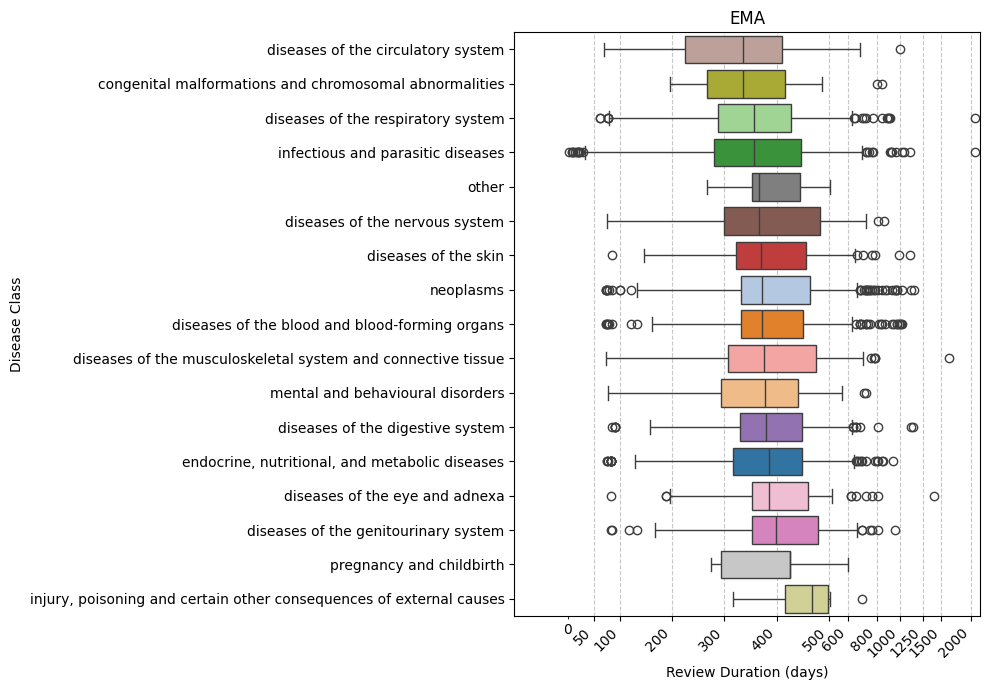

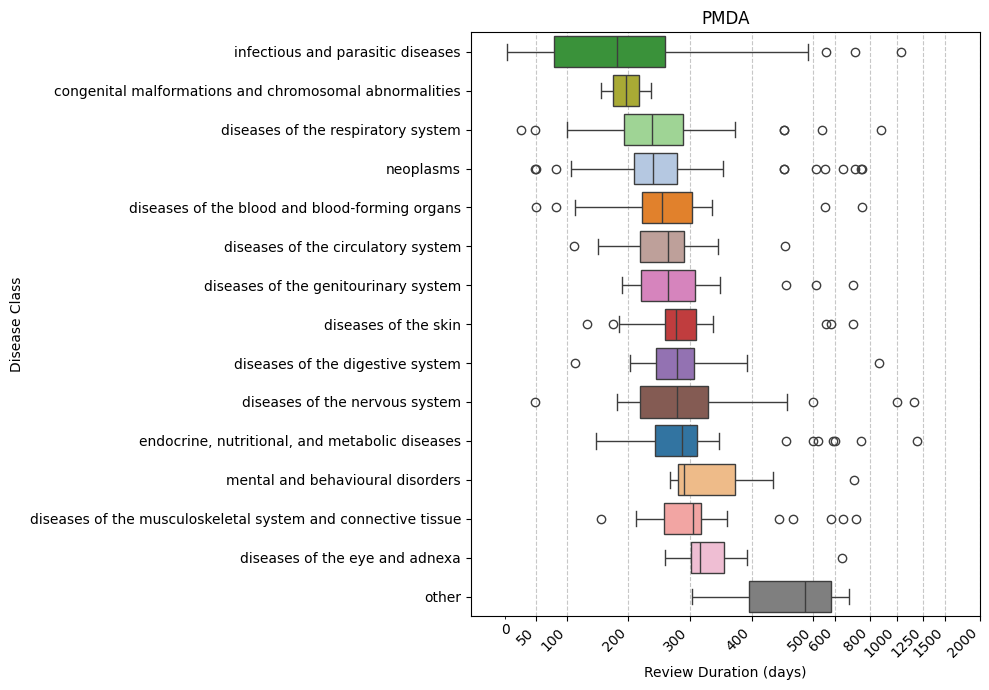

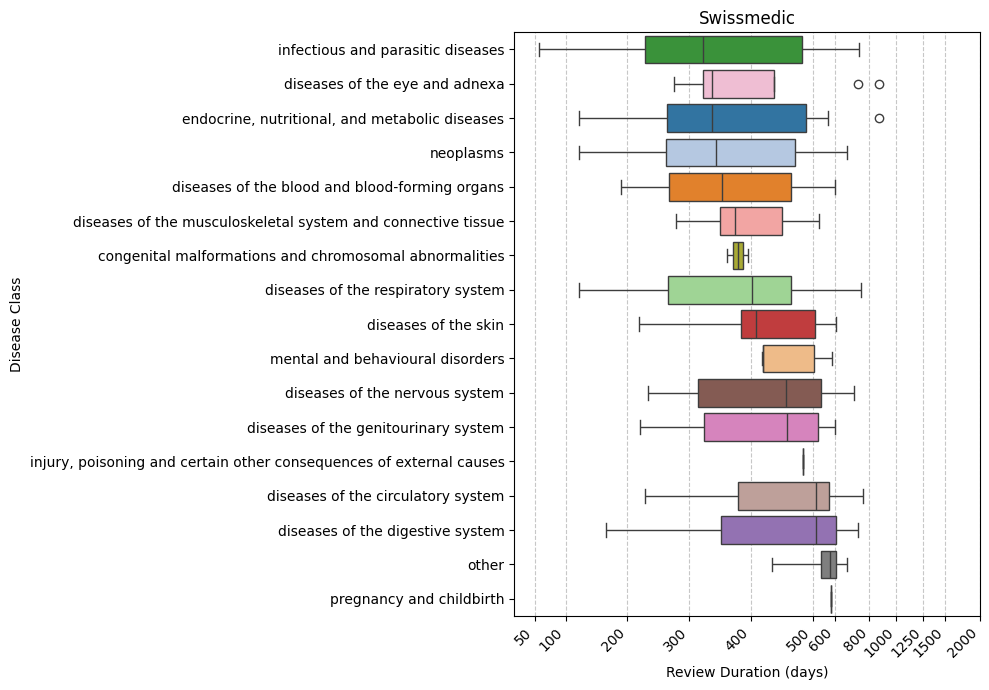

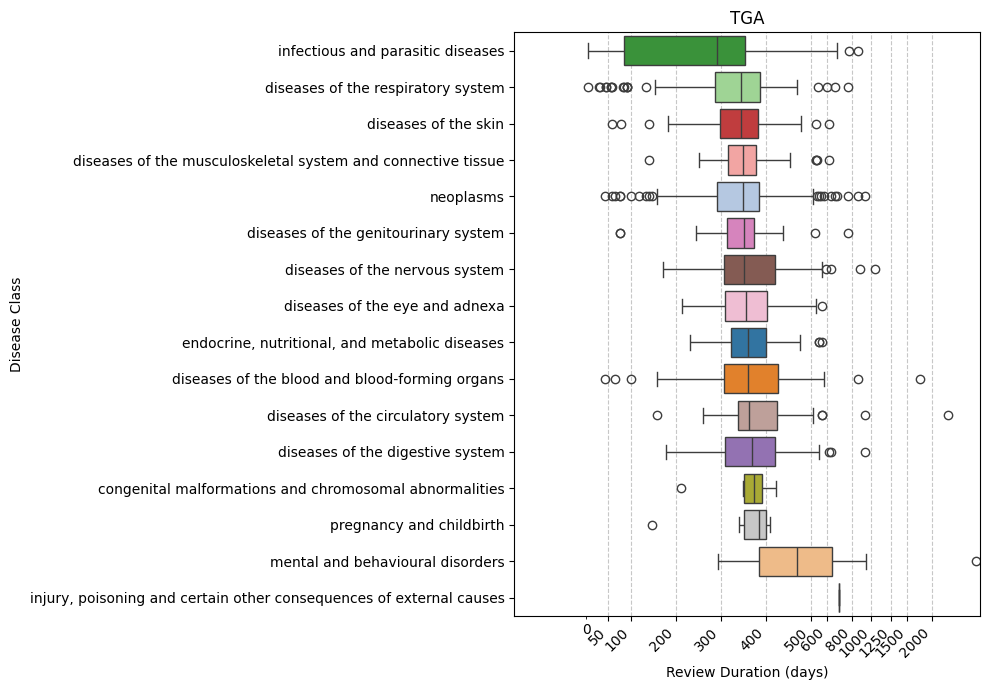

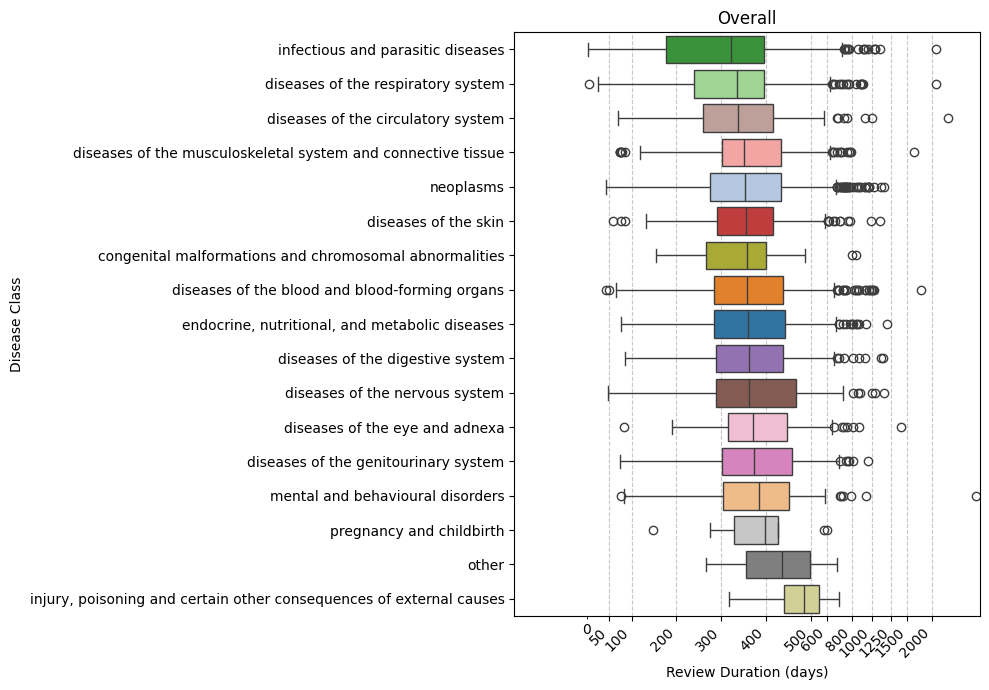

In [75]:
for k,v in DATASETS.items():
    if 'Application_date' in v.columns and 'Decision_date' in v.columns:
        plot_review_duration_by_disease_class(
            v,
            submission_col='Application_date',
            decision_col='Decision_date',
            dataset_name=k,
            disease_class_colormap=disease_class_colormap,
            abridged=None
        )
    else:
        print(f"{k}: 'Application_date' or 'Decision_date' column not found, skipping review duration by agency plot.")

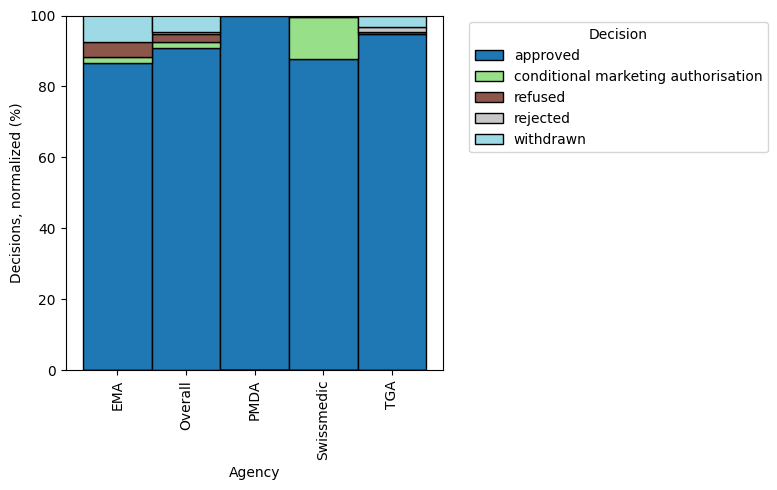

In [76]:
plot_decision_distribution_by_agency(
    agency_dfs=DATASETS,
    dataset_name='combined'
)

In [77]:
print(DATASETS['Overall']['Decision'].value_counts())

Decision
approved                               3060
withdrawn                               157
refused                                  78
conditional marketing authorisation      60
rejected                                 16
Name: count, dtype: int64


In [78]:
for agency, df in DATASETS.items():
    if 'Decision' in df.columns:
        print(f"\n{agency}:")
        print(df['Decision'].unique()[:20])


EMA:
['approved' 'withdrawn' 'refused' 'conditional marketing authorisation']

PMDA:
['approved']

Swissmedic:
['approved' 'conditional marketing authorisation' 'refused']

TGA:
['withdrawn' 'approved' 'rejected' 'refused']

Overall:
['approved' 'withdrawn' 'refused' 'conditional marketing authorisation'
 'rejected']


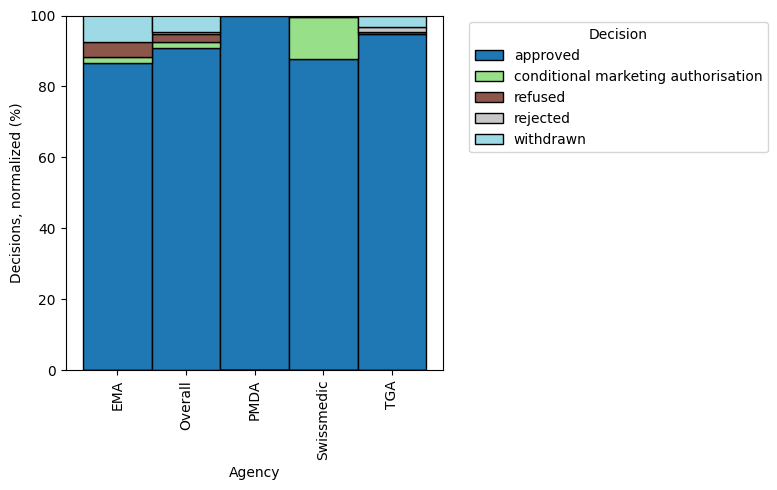

In [79]:
plot_decision_distribution_by_agency(
    DATASETS,
    dataset_name='combined'
)

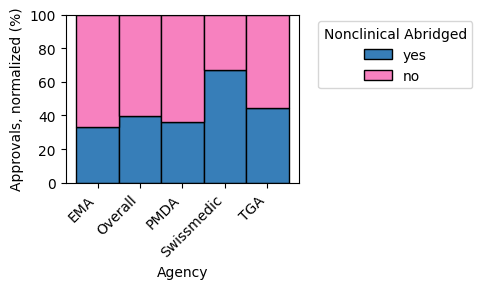

In [80]:
plot_nonclinical_abridged_distribution(
    agency_dfs=DATASETS,
    dataset_name='combined'
)

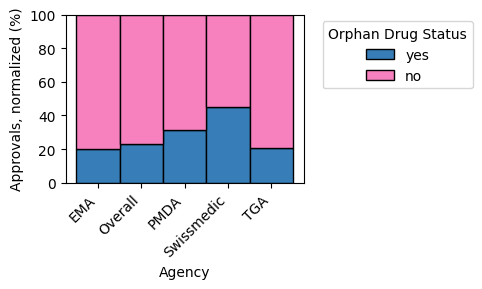

In [81]:
plot_orphan_drug_status_distribution(
    agency_dfs=DATASETS,
    dataset_name='combined'
)

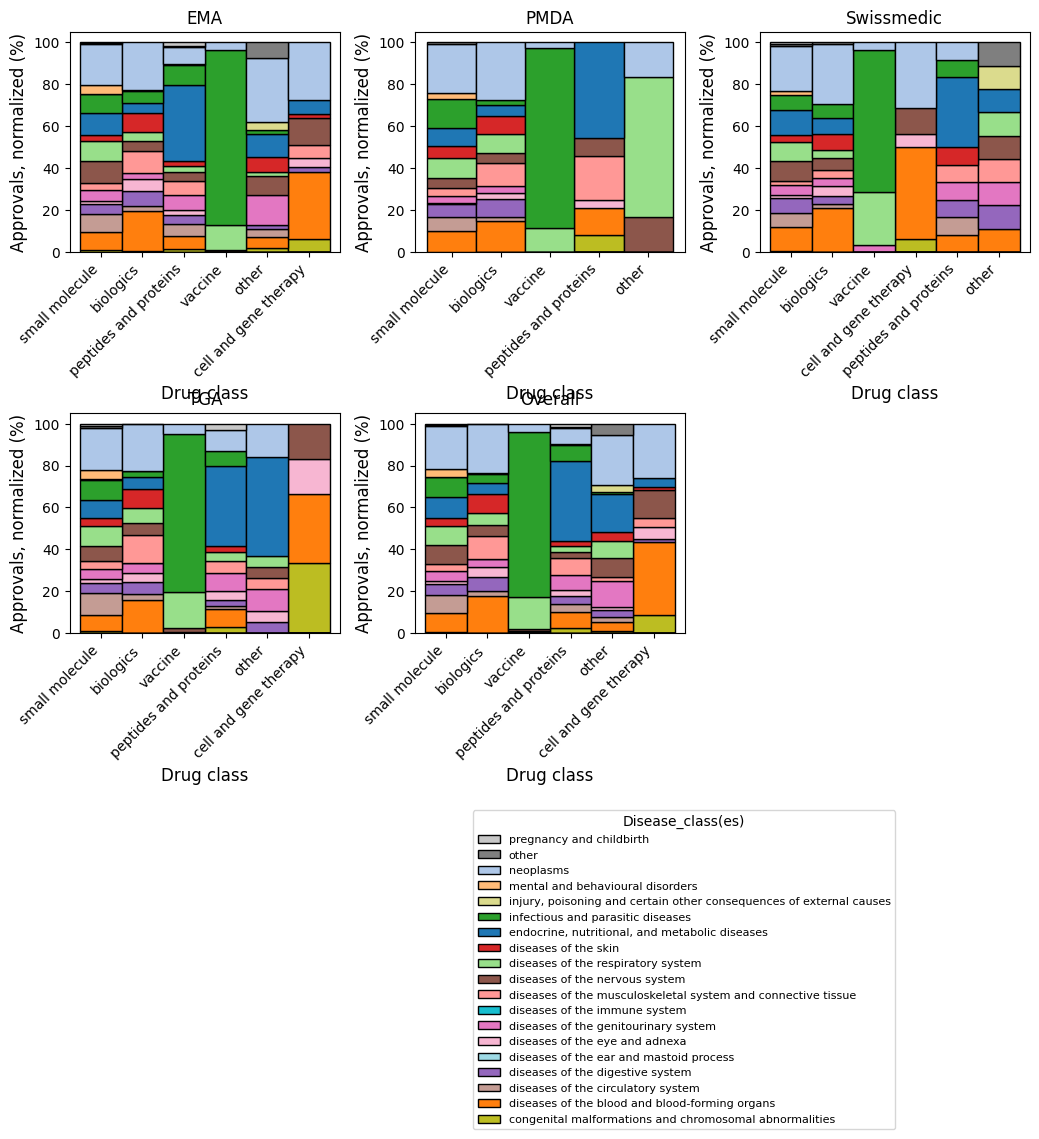

In [82]:
# Panel plot for disease class per drug class
plot_disease_class_per_drug_class_panel(
    DATASETS, 
    xcol='Drug_class',
    ycol="Disease_class(es)",
    disease_class_colormap=disease_class_colormap, 
    nrows=3, 
    ncols=3,
    figsize_per_subplot=(3.5, 4)
)

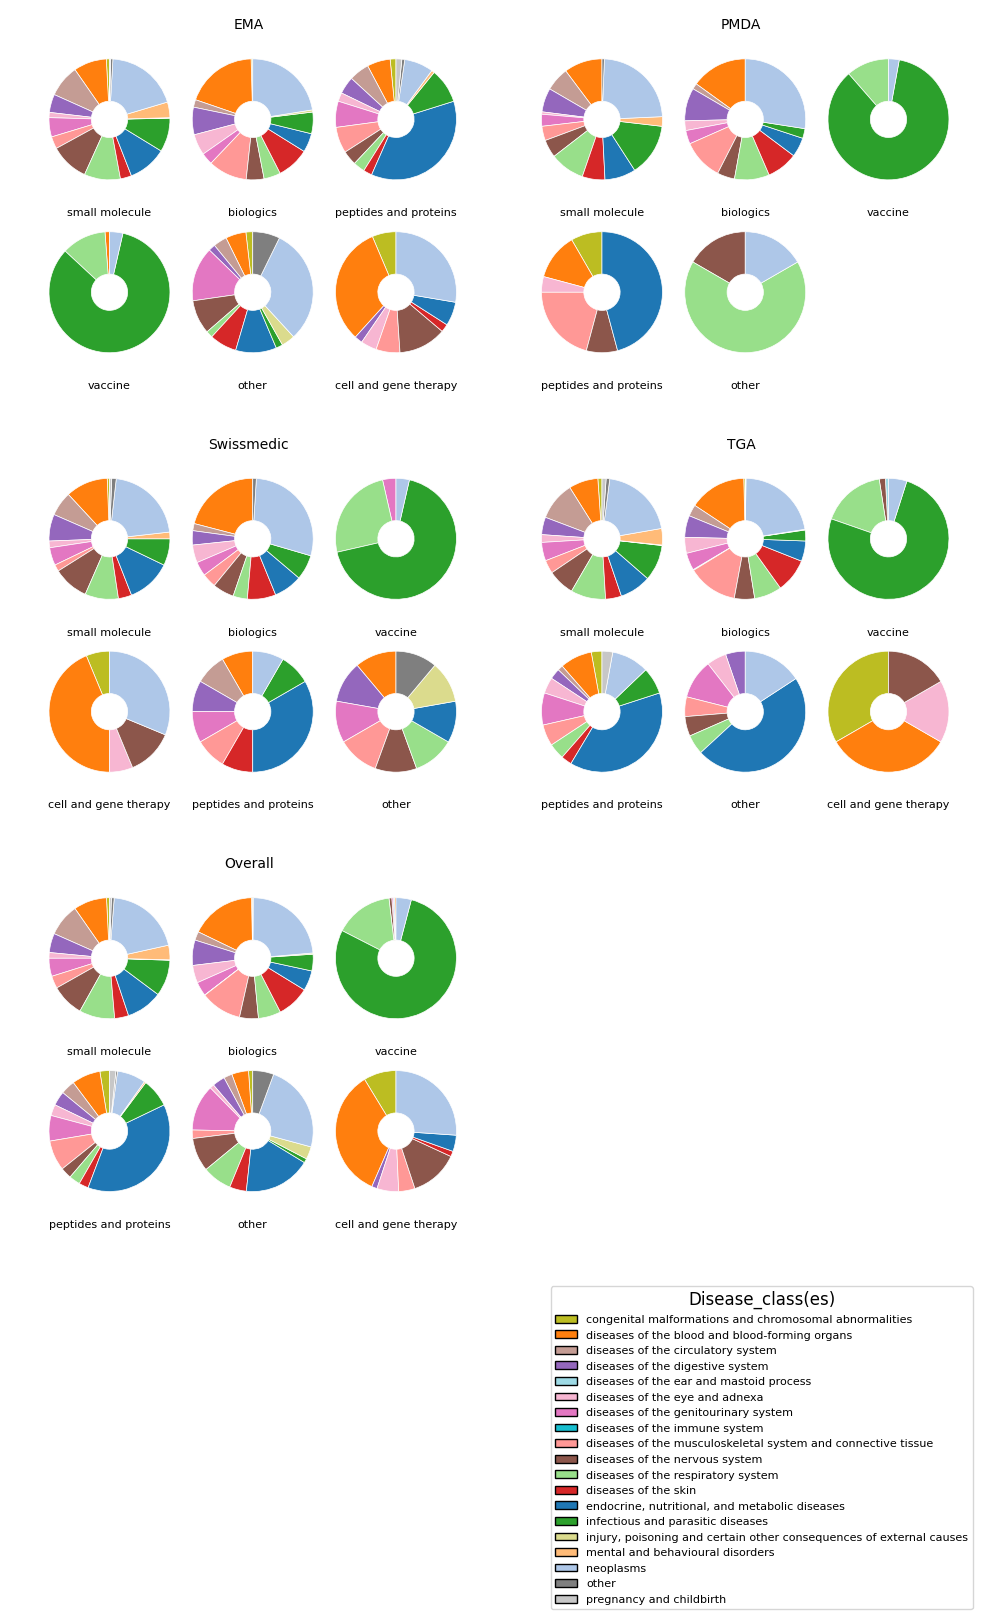

In [83]:
# Panel plot for disease class per drug class
plot_pie_disease_class_per_drug_class_panel(
    DATASETS, 
    xcol='Drug_class',
    ycol="Disease_class(es)",
    disease_class_colormap=disease_class_colormap, 
    nrows=4, 
    ncols=2,
    figsize_per_subplot=(5, 5)
)

# Burden

In [84]:
# Load preprocessed burden data
# Note: Run 'python src/burden_mapping/preprocess_burden_data.py' first if the data doesn't exist
burden_deaths = load_burden_data("Deaths")
burden_prevalence = load_burden_data("Prevalence")
burden_incidence = load_burden_data("Incidence")

Loaded burden data: 435 records, 15 disease classes
  Year range: 1995 - 2023
Loaded burden data: 435 records, 15 disease classes
  Year range: 1995 - 2023
Loaded burden data: 435 records, 15 disease classes
  Year range: 1995 - 2023


Processing datasets...
  - EMA
  - PMDA
  - Swissmedic
  - TGA
  - Overall
Found 15 disease classes
Year range: 1995 - 2025


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:1164: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  approvals_class = approvals_class.set_index("Year").reindex(all_years).fillna(0).reset_index()
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:1164: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  approvals_class = approvals_class.set_index("Year").reindex(all_years).fillna(0).reset_index()
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:1164: FutureWarning: Downcasting object dtype arrays on .fillna, .ff


Saved: ./../analysis/1995_pars/all_decisions/burden/deaths_vs_approvals_Decision_year.png


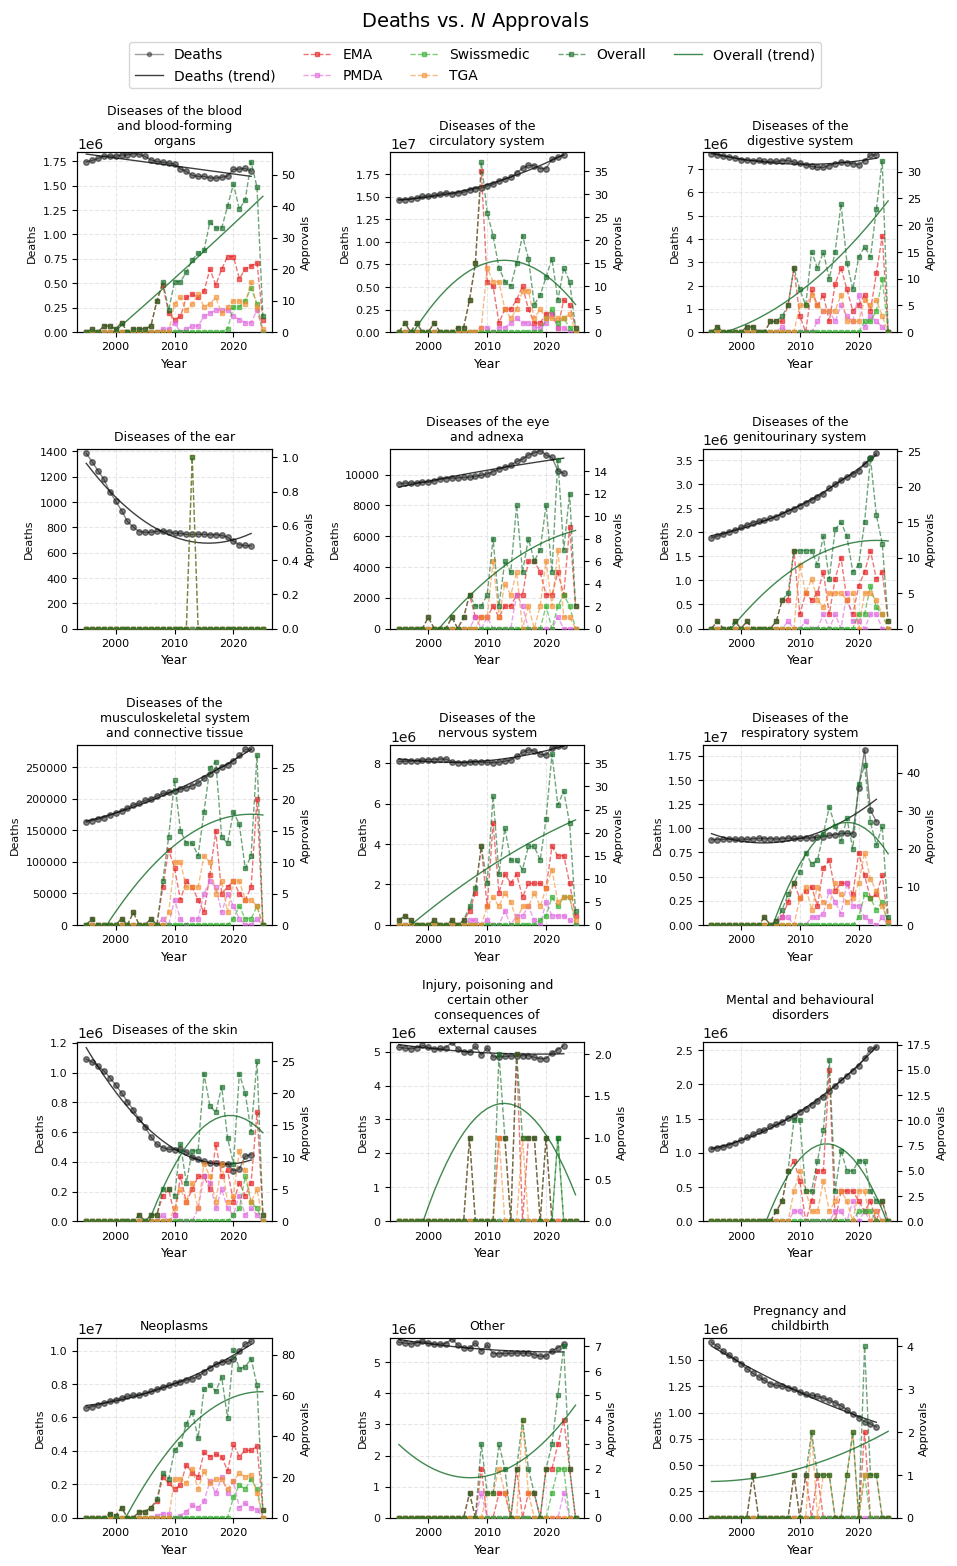

In [85]:
# Plot Deaths vs Drug Approvals for ALL datasets combined (1995+)
plot_burden_vs_approvals_combined(
    datasets_dict=DATASETS,
    burden_data=burden_deaths,
    date_col="Decision_year",
    disease_col="Disease_class(es)",
    measure="Deaths",
    ncols=3,
    figsize=(10, 16)
)

Processing datasets...
  - EMA
  - PMDA
  - Swissmedic
  - TGA
  - Overall
Found 15 disease classes
Year range: 1995 - 2025


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:1164: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  approvals_class = approvals_class.set_index("Year").reindex(all_years).fillna(0).reset_index()
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:1164: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  approvals_class = approvals_class.set_index("Year").reindex(all_years).fillna(0).reset_index()
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:1164: FutureWarning: Downcasting object dtype arrays on .fillna, .ff


Saved: ./../analysis/1995_pars/all_decisions/burden/incidence_vs_approvals_Decision_year.png


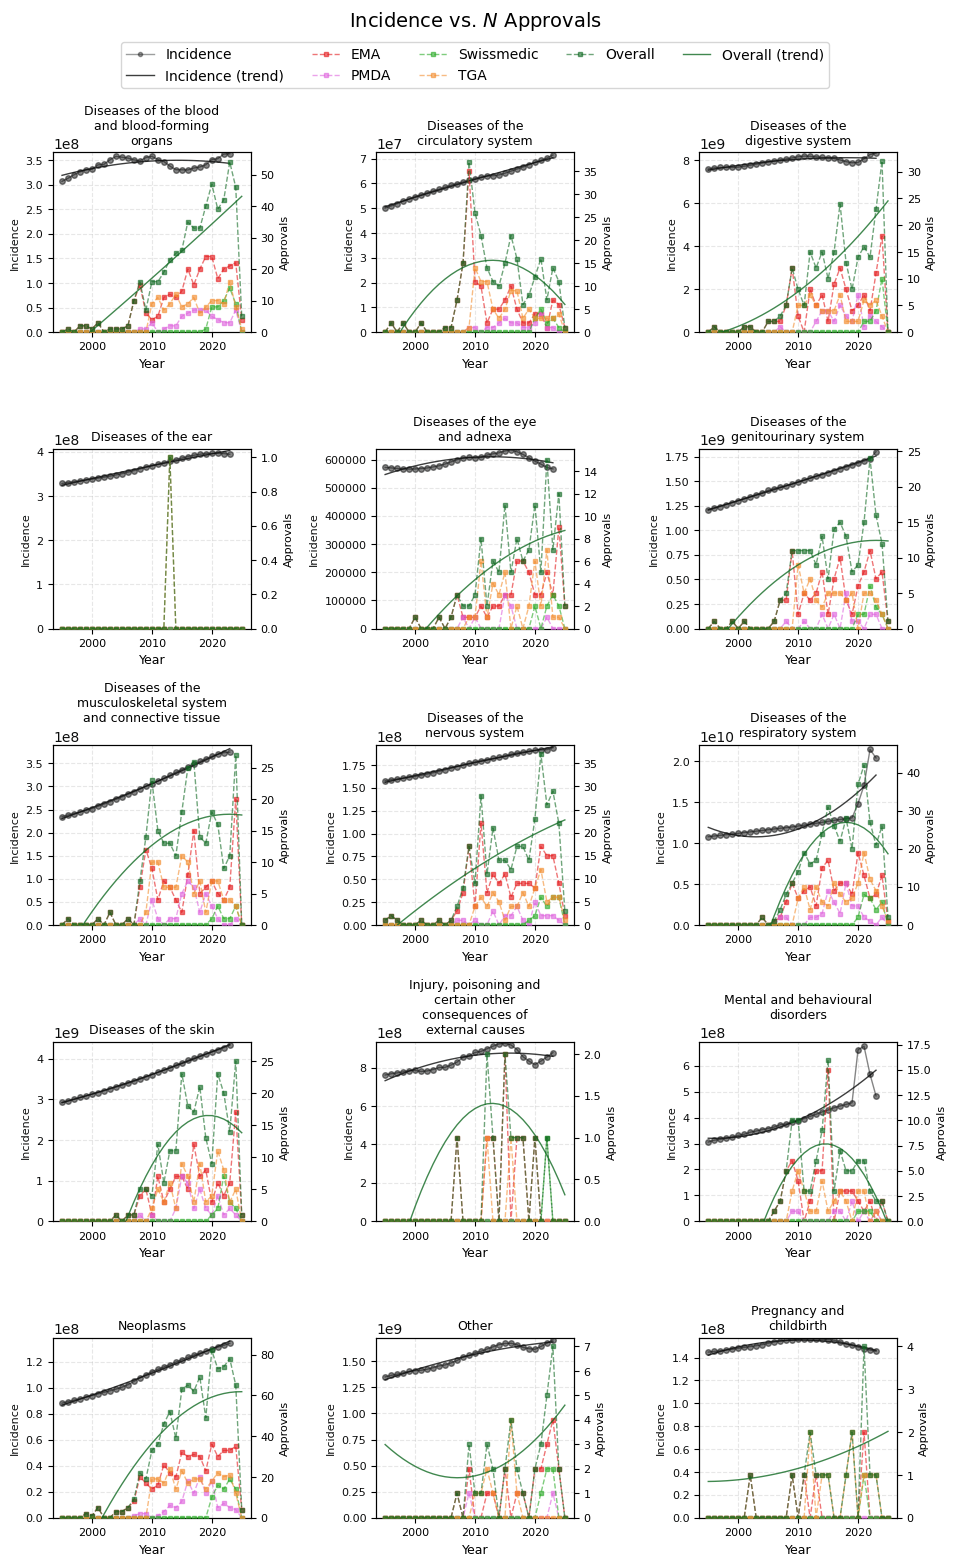

In [86]:
# Plot Prevalence vs Drug Approvals for ALL datasets combined (1995+)
plot_burden_vs_approvals_combined(
    datasets_dict=DATASETS,
    burden_data=burden_incidence,
    date_col="Decision_year",
    disease_col="Disease_class(es)",
    measure="Incidence",
    ncols=3,
    figsize=(10, 16)
)

Processing datasets...
  - EMA
  - PMDA
  - Swissmedic
  - TGA
  - Overall
Found 15 disease classes
Year range: 1995 - 2025


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:1164: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  approvals_class = approvals_class.set_index("Year").reindex(all_years).fillna(0).reset_index()
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:1164: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  approvals_class = approvals_class.set_index("Year").reindex(all_years).fillna(0).reset_index()
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_5936\2682256468.py:1164: FutureWarning: Downcasting object dtype arrays on .fillna, .ff


Saved: ./../analysis/1995_pars/all_decisions/burden/prevalence_vs_approvals_Decision_year.png


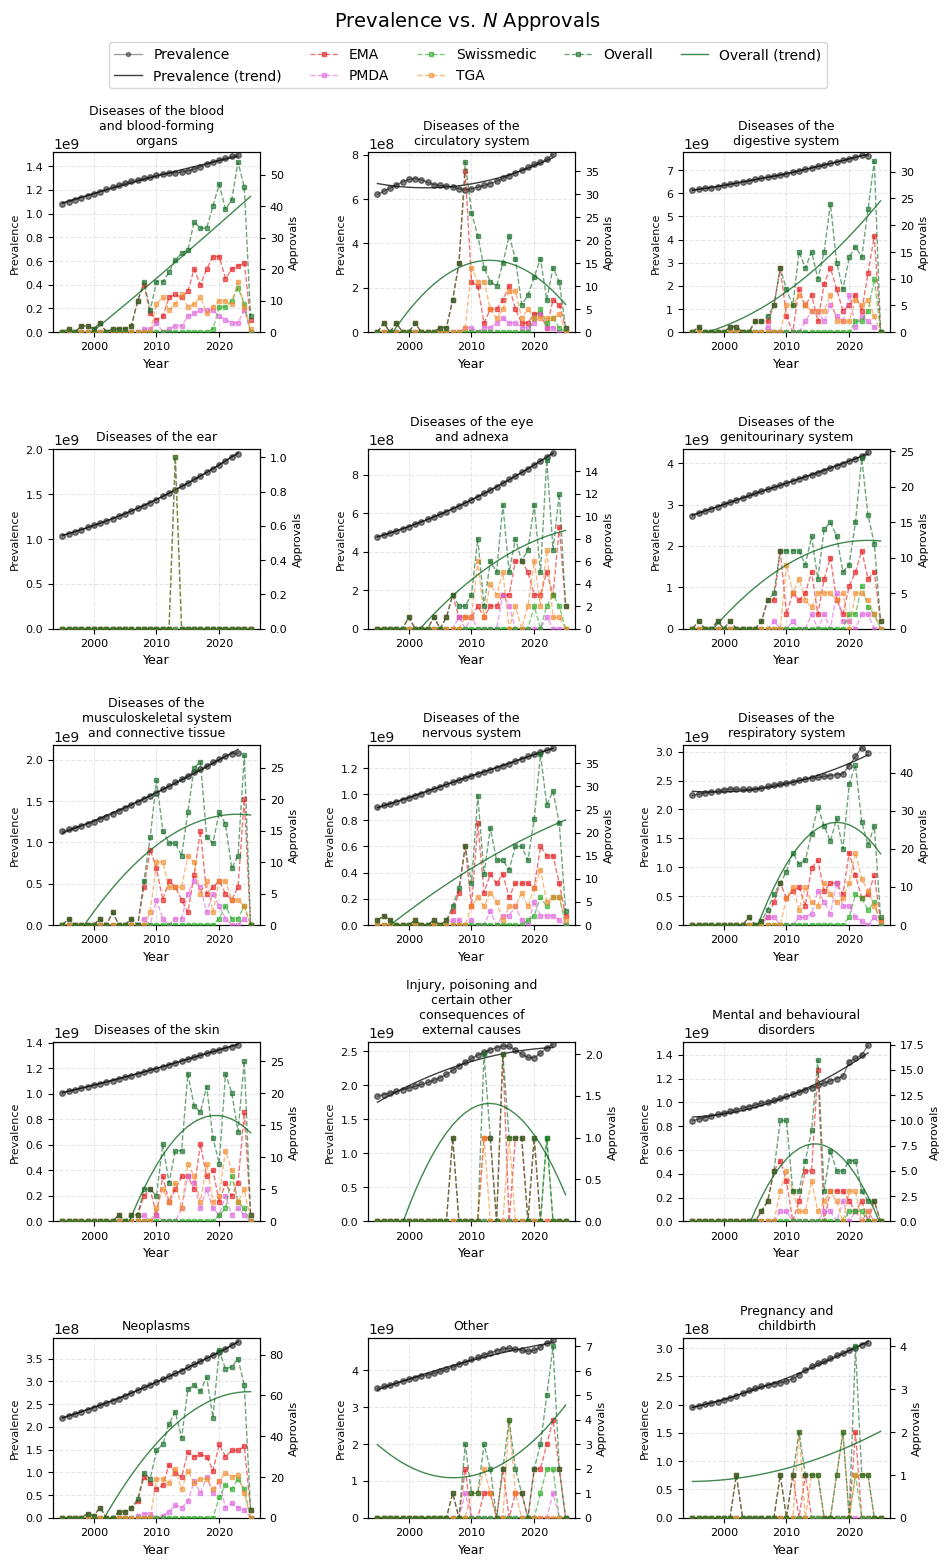

In [87]:
# Plot Prevalence vs Drug Approvals for ALL datasets combined (1995+)
plot_burden_vs_approvals_combined(
    datasets_dict=DATASETS,
    burden_data=burden_prevalence,
    date_col="Decision_year",
    disease_col="Disease_class(es)",
    measure="Prevalence",
    ncols=3,
    figsize=(10, 16)
)

In [88]:
# Investigate suspiciously short review durations
output_lines = []

for agency, df in DATASETS.items():
    if 'Application_date' in df.columns and 'Decision_date' in df.columns:
        df_check = df.copy()
        df_check['Application_date'] = pd.to_datetime(df_check['Application_date'], errors='coerce', dayfirst=True)
        df_check['Decision_date'] = pd.to_datetime(df_check['Decision_date'], errors='coerce', dayfirst=True)
        df_check['Review_duration_days'] = (df_check['Decision_date'] - df_check['Application_date']).dt.days
        
        # Filter for valid durations
        valid = df_check[df_check['Review_duration_days'].notna()]
        
        if len(valid) > 0:
            # Check for very short durations (< 30 days)
            very_short = valid[valid['Review_duration_days'] < 30]
            # Check for negative durations (decision before application!)
            negative = valid[valid['Review_duration_days'] < 0]
            
            output = f"\n{agency}:\n"
            output += f"  Total with both dates: {len(valid)}\n"
            output += f"  Review < 30 days: {len(very_short)} ({len(very_short)/len(valid)*100:.1f}%)\n"
            output += f"  Negative duration: {len(negative)} ({len(negative)/len(valid)*100:.1f}%)\n"
            
            if len(very_short) > 0:
                output += f"  Min duration: {valid['Review_duration_days'].min()} days\n"
                if len(very_short) <= 5:
                    output += f"  All cases < 30 days:\n"
                    output += very_short[['Drug_name', 'Application_date', 'Decision_date', 'Review_duration_days']].to_string() + "\n"
                else:
                    output += f"  First 3 examples of < 30 days:\n"
                    output += very_short[['Drug_name', 'Application_date', 'Decision_date', 'Review_duration_days']].head(3).to_string() + "\n"
            
            print(output)
            output_lines.append(output)

# Save to text file
output_file = f'{SAVE_DIR}/short_review_durations_analysis.txt'
with open(output_file, 'w', encoding='utf-8') as f:
    f.write("Analysis of Suspiciously Short Review Durations\n")
    f.write("=" * 60 + "\n")
    f.writelines(output_lines)

print(f"\nAnalysis saved to: {output_file}")


EMA:
  Total with both dates: 1479
  Review < 30 days: 11 (0.7%)
  Negative duration: 0 (0.0%)
  Min duration: 2.0 days
  First 3 examples of < 30 days:
     Drug_name Application_date Decision_date  Review_duration_days
80   arepanrix       2010-01-18    2010-01-20                   2.0
145   bimervax       2023-03-21    2023-03-30                   9.0
253  comirnaty       2020-11-30    2020-12-21                  21.0


PMDA:
  Total with both dates: 404
  Review < 30 days: 10 (2.5%)
  Negative duration: 1 (0.2%)
  Min duration: -13.0 days
  First 3 examples of < 30 days:
     Drug_name Application_date Decision_date  Review_duration_days
165    zyprexa       2017-06-22    2017-06-09                 -13.0
295    veklury       2020-05-04    2020-05-07                   3.0
306  ronapreve       2021-10-11    2021-11-04                  24.0


Swissmedic:
  Total with both dates: 234
  Review < 30 days: 0 (0.0%)
  Negative duration: 0 (0.0%)


TGA:
  Total with both dates: 521
  Revie